In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from qiskit import QuantumCircuit, transpile
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
from qiskit.synthesis import LieTrotter
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import os
import pandas as pd

from src.qwalk_dictionary import getOpsCirc
from src.graphs import StaticGraph, expm_quantum
from src.misc import graph_matchings_with_relabeling, graph_matchings_no_relabeling, graph_matchings_with_relabeling_keep_labels
from src.graph_simplifier import build_matching_circuit_iteratively, compress_edges_iteratively

import importlib # for reloading functions. can rid of later.
import src.graph_simplifier
import src.qwalk_dictionary
import src.misc
importlib.reload(src.graph_simplifier)
importlib.reload(src.qwalk_dictionary)
importlib.reload(src.misc)
from src.graph_simplifier import build_matching_circuit_iteratively, compress_edges_iteratively
from src.qwalk_dictionary import getOpsCirc
from src.misc import graph_matchings_with_relabeling_keep_labels

# Using eigendecomposition-based expm for guaranteed unitarity and maximum accuracy
# Pauli circuits use Lie-Trotter synthesis to avoid scipy sparse matrix warnings

In [2]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [3]:

# Global storage for gate count data
gate_count_data = []


def _get_target_qubit(z1, z2):
    """Helper function to get target qubit from reduced edge (same as in graph_simplifier)"""
    from src.qwalk_dictionary import getHammingWt
    z1=z1[::-1]
    z2=z2[::-1]
    if (
            getHammingWt(z2) == 0
            or getHammingWt(z1) == len(z1)
            or getHammingWt(z1) > getHammingWt(z2)
        ):
            temp = z1
            z1 = z2
            z2 = temp
    zeros1 = [idx for idx, elem in enumerate(z1) if elem == "0"]
    zeros2 = [idx for idx, elem in enumerate(z2) if elem == "0"]

    ctrlBit2 = list(set(zeros1) - set(zeros2))[0]
    return ctrlBit2


def build_matching_circuit_with_reduction(n_qubits, n_steps, delta_t, matchings):
    """
    Build quantum circuit using matching-based decomposition with space reduction
    using compress_edges_iteratively from src.graph_simplifier.

    Builds one Trotter step circuit, then repeats it n_steps times.

    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        matchings: List of matchings, where each matching is a list of edges

    Returns:
        QuantumCircuit: Complete matching-based circuit with space reduction
    """
    return build_matching_circuit_iteratively(n_qubits, n_steps, delta_t, matchings)


def build_pauli_circuit(n_qubits, n_steps, delta_t, hamiltonian):
    """
    Build quantum circuit using Pauli decomposition with TRUE Trotter approximation.

    This creates a proper n_steps Trotter approximation by:  
    1. Decomposing H into Pauli terms: H = sum_i c_i * P_i
    2. Approximating exp(-iHt) ≈ [prod_i exp(-i*c_i*P_i*t/n)]^n
    3. Each Trotter step evolves individual Pauli terms

    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        hamiltonian: Hamiltonian matrix

    Returns:
        QuantumCircuit: Complete Pauli-based circuit with TRUE Trotter approximation
    """
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []

    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n_qubits)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ hamiltonian) / (2**n_qubits)

        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)

    if not coeffs:
        return QuantumCircuit(n_qubits)

    # Build circuit with TRUE Trotter approximation
    # Each Trotter step: evolve each Pauli term separately
    qc = QuantumCircuit(n_qubits)
    
    for step in range(n_steps):
        # Evolve each Pauli term for time delta_t/n_steps
        for pauli_str, coeff in zip(pauli_strings, coeffs):
            # Create single-term Hamiltonian
            single_term = SparsePauliOp([pauli_str], [coeff])
            
            # Evolve this term
            evo_gate = PauliEvolutionGate(
                single_term,
                time=delta_t / n_steps
            )
            qc.append(evo_gate, range(n_qubits))

    return qc
def build_exact_circuit(n_qubits, delta_t, hamiltonian):
    """
    Build exact quantum circuit using matrix exponential.

    Args:
        n_qubits: Number of qubits
        delta_t: Total time
        hamiltonian: Hamiltonian matrix

    Returns:
        QuantumCircuit: Exact evolution circuit
    """
    qc = QuantumCircuit(n_qubits)

    # Compute exact evolution operator
    exact_op = expm_quantum(hamiltonian, delta_t)
    exact_operator = Operator(exact_op)

    # Add as unitary gate
    qc.unitary(exact_operator, range(n_qubits), label='exact_evolution')

    return qc


def analyze_and_plot(edges, title, output_dir="trotterization_plots", delta_t=0.1):
    """
    Analyze quantum time evolution errors and plot results.
    Compares matching with relabeling, matching without relabeling, and Pauli decomposition.
    
    NOW USING graph_matchings_with_relabeling_keep_labels() to properly use relabeled vertices!
    
    Args:
        edges: Original graph edges (set of tuples of binary strings)
               Example: {('00','01'), ('00','10'), ('00','11')}
        title: Plot title
        output_dir: Directory to save plots (default: "trotterization_plots")
        delta_t: Time step size (default: 0.1)
        
    Example:
        edges = {('00','01'), ('00','10'), ('00','11')}
        analyze_and_plot(edges, "Tree Graph T4")
    """
    global gate_count_data
    
    # Create output directory if it doesn't exist
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    n_steps_list = [1, 2, 5, 10, 20, 50, 100]
    
    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")
    
    # Create graph
    G = StaticGraph(edges)
    print(f"Number of qubits: {G.n_qubits}")
    
    # Display original graph
    print("\nOriginal Graph:")
    try:
        display(G.draw())
    except:
        print("(Graph display not available)")
    
    # Get matchings WITH relabeling - USING NEW FUNCTION THAT KEEPS RELABELED VERTICES
    matchings_with_relabel, vertex_mapping = graph_matchings_with_relabeling_keep_labels(edges)
    relabeled_edges = set()
    for m in matchings_with_relabel:
        relabeled_edges = relabeled_edges.union(m)
    
    print(f"\nMatchings WITH relabeling: {len(matchings_with_relabel)}")
    print(f"Vertex mapping (original -> relabeled): {vertex_mapping}")
    print(f"Matchings: {matchings_with_relabel}")
    print(f"Relabeled edges: {relabeled_edges}")
    
    # Get matchings WITHOUT relabeling
    matchings_no_relabel = graph_matchings_no_relabeling(edges)
    
    print(f"\nMatchings WITHOUT relabeling: {len(matchings_no_relabel)}")
    print(f"Matchings: {matchings_no_relabel}")

    # Infer number of qubits
    if relabeled_edges:
        first_edge = next(iter(relabeled_edges))
        n_qubits = len(first_edge[0])
    else:
        raise ValueError("No edges provided")
    
    print(f"Number of qubits: {n_qubits}")
    
    # Calculate total Hamming costs
    def calculate_total_hamming_cost(edge_set):
        """Calculate total Hamming distance for all edges in the set"""
        total_cost = 0
        for edge in edge_set:
            v1, v2 = edge
            hamming_dist = sum(c1 != c2 for c1, c2 in zip(v1, v2))
            total_cost += hamming_dist
        return total_cost
    
    hamming_cost_relabel = calculate_total_hamming_cost(relabeled_edges)
    hamming_cost_no_relabel = calculate_total_hamming_cost(edges)
    
    # Calculate per-edge costs
    num_edges_relabel = len(relabeled_edges)
    num_edges_no_relabel = len(edges)
    
    hamming_per_edge_relabel = hamming_cost_relabel / num_edges_relabel if num_edges_relabel > 0 else 0
    hamming_per_edge_no_relabel = hamming_cost_no_relabel / num_edges_no_relabel if num_edges_no_relabel > 0 else 0
    
    print(f"\nHamming Cost Analysis:")
    print(f"With Relabeling: Total = {hamming_cost_relabel}, Edges = {num_edges_relabel}, Per Edge = {hamming_per_edge_relabel:.3f}")
    print(f"No Relabeling: Total = {hamming_cost_no_relabel}, Edges = {num_edges_no_relabel}, Per Edge = {hamming_per_edge_no_relabel:.3f}")
    
    # Display relabeled graph
    G_relabeled = StaticGraph(relabeled_edges)
    print("\nRelabeled Graph:")
    try:
        display(G_relabeled.draw())
    except:
        print("(Graph display not available)")
    
    # Get Hamiltonian from ORIGINAL graph (for no relabeling)
    H_original = G.get_adj_mat()
    # Get Hamiltonian from RELABELED graph (for with relabeling)
    H_relabeled = G_relabeled.get_adj_mat()
    
    # Display sample circuits (with n_steps=1)
    sample_qc_relabel = build_matching_circuit_with_reduction(n_qubits, 1, delta_t, matchings_with_relabel)
    print("\nSample Circuit - Matching WITH Relabeling (n_steps=1):")
    try:
        display(sample_qc_relabel.draw('mpl'))
    except:
        print(sample_qc_relabel.draw('text'))
    
    sample_qc_no_relabel = build_matching_circuit_iteratively(n_qubits, 1, delta_t, matchings_no_relabel)
    print("\nSample Circuit - Matching WITHOUT Relabeling (n_steps=1):")
    try:
        display(sample_qc_no_relabel.draw('mpl'))
    except:
        print(sample_qc_no_relabel.draw('text'))
    
    # Build exact circuits
    exact_qc_relabeled = build_exact_circuit(n_qubits, delta_t, H_relabeled)
    exact_operator_relabeled = Operator(expm_quantum(H_relabeled, delta_t))
    
    exact_qc_original = build_exact_circuit(n_qubits, delta_t, H_original)
    exact_operator_original = Operator(expm_quantum(H_original, delta_t))
    
    # Storage for results
    matching_relabel_vs_exact_errors = []
    matching_no_relabel_vs_exact_errors = []
    pauli_relabel_vs_exact_errors = []
    pauli_no_relabel_vs_exact_errors = []
    
    matching_relabel_gates_no_opt = []
    matching_relabel_gates_opt = []
    matching_no_relabel_gates_no_opt = []
    matching_no_relabel_gates_opt = []
    pauli_relabel_gates_no_opt = []
    pauli_relabel_gates_opt = []
    pauli_no_relabel_gates_no_opt = []
    pauli_no_relabel_gates_opt = []
    
    # Analyze each n_steps
    for n_steps in n_steps_list:        
        # Build matching circuit WITH relabeling - uses relabeled edges!
        matching_qc_relabel = build_matching_circuit_with_reduction(n_qubits, n_steps, delta_t, matchings_with_relabel)
        transpiled_relabel_no_opt = transpile(matching_qc_relabel, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_relabel_opt = transpile(matching_qc_relabel, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_relabel_operator = Operator(transpiled_relabel_opt)
        
        relabel_counts_no_opt = transpiled_relabel_no_opt.count_ops()
        relabel_counts_opt = transpiled_relabel_opt.count_ops()
        
        matching_relabel_gates_no_opt.append(relabel_counts_no_opt.get('cx', 0))
        matching_relabel_gates_opt.append(relabel_counts_opt.get('cx', 0))
        
        # Build matching circuit WITHOUT relabeling
        matching_qc_no_relabel = build_matching_circuit_iteratively(n_qubits, n_steps, delta_t, matchings_no_relabel)
        transpiled_no_relabel_no_opt = transpile(matching_qc_no_relabel, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_no_relabel_opt = transpile(matching_qc_no_relabel, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_no_relabel_operator = Operator(transpiled_no_relabel_opt)
        
        no_relabel_counts_no_opt = transpiled_no_relabel_no_opt.count_ops()
        no_relabel_counts_opt = transpiled_no_relabel_opt.count_ops()
        
        matching_no_relabel_gates_no_opt.append(no_relabel_counts_no_opt.get('cx', 0))
        matching_no_relabel_gates_opt.append(no_relabel_counts_opt.get('cx', 0))
        
        # Build Pauli circuit for RELABELED Hamiltonian
        pauli_qc_relabel = build_pauli_circuit(n_qubits, n_steps, delta_t, H_relabeled)
        transpiled_pauli_relabel_no_opt = transpile(pauli_qc_relabel, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_pauli_relabel_opt = transpile(pauli_qc_relabel, basis_gates=['u3', 'cx'], optimization_level=3)
        # Extract operator BEFORE transpilation to show proper Trotter convergence
        pauli_relabel_operator = Operator(pauli_qc_relabel)

        pauli_relabel_counts_no_opt = transpiled_pauli_relabel_no_opt.count_ops()
        pauli_relabel_counts_opt = transpiled_pauli_relabel_opt.count_ops()

        pauli_relabel_gates_no_opt.append(pauli_relabel_counts_no_opt.get('cx', 0))
        pauli_relabel_gates_opt.append(pauli_relabel_counts_opt.get('cx', 0))

        # Build Pauli circuit for ORIGINAL Hamiltonian
        pauli_qc_no_relabel = build_pauli_circuit(n_qubits, n_steps, delta_t, H_original)
        transpiled_pauli_no_relabel_no_opt = transpile(pauli_qc_no_relabel, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_pauli_no_relabel_opt = transpile(pauli_qc_no_relabel, basis_gates=['u3', 'cx'], optimization_level=3)
        # Extract operator BEFORE transpilation to show proper Trotter convergence
        pauli_no_relabel_operator = Operator(pauli_qc_no_relabel)

        pauli_no_relabel_counts_no_opt = transpiled_pauli_no_relabel_no_opt.count_ops()
        pauli_no_relabel_counts_opt = transpiled_pauli_no_relabel_opt.count_ops()

        pauli_no_relabel_gates_no_opt.append(pauli_no_relabel_counts_no_opt.get('cx', 0))
        pauli_no_relabel_gates_opt.append(pauli_no_relabel_counts_opt.get('cx', 0))
        # Store gate count data
        gate_count_data.extend([
            {
                'Case': title,
                'Method': 'Matching (with relabeling)',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': matching_relabel_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (with relabeling)',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': matching_relabel_gates_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (no relabeling)',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': matching_no_relabel_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching (no relabeling)',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': matching_no_relabel_gates_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli (with relabeling)',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': pauli_relabel_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli (with relabeling)',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': pauli_relabel_gates_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli (no relabeling)',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': pauli_no_relabel_gates_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli (no relabeling)',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': pauli_no_relabel_gates_opt[-1]
            }
        ])
        
        # Calculate errors (compare to appropriate exact operator)
        matching_relabel_vs_exact = np.linalg.norm(matching_relabel_operator - exact_operator_relabeled, ord=2)
        matching_no_relabel_vs_exact = np.linalg.norm(matching_no_relabel_operator - exact_operator_original, ord=2)
        pauli_relabel_vs_exact = np.linalg.norm(pauli_relabel_operator - exact_operator_relabeled, ord=2)
        pauli_no_relabel_vs_exact = np.linalg.norm(pauli_no_relabel_operator - exact_operator_original, ord=2)

        matching_relabel_vs_exact_errors.append(matching_relabel_vs_exact)
        matching_no_relabel_vs_exact_errors.append(matching_no_relabel_vs_exact)
        pauli_relabel_vs_exact_errors.append(pauli_relabel_vs_exact)
        pauli_no_relabel_vs_exact_errors.append(pauli_no_relabel_vs_exact)
    
    # Print CX gate count summary with Hamming cost per edge
    print(f"\nCX Gate Count Summary for {title}:")
    print("="*100)
    print(f"{'n_steps':<8} | {'Matching w/ Relabel (No Opt/Opt)':^37} | {'Matching No Relabel (No Opt/Opt)':^37} | {'Pauli w/ Relabel (No Opt/Opt)':^37} | {'Pauli No Relabel (No Opt/Opt)':^37}")
    print("-"*160)
    
    for i, n_steps in enumerate(n_steps_list):
        print(f"{n_steps:<8} | "
              f"{matching_relabel_gates_no_opt[i]:>4}/{matching_relabel_gates_opt[i]:<4}"
              f"{'':<29} | "
              f"{matching_no_relabel_gates_no_opt[i]:>4}/{matching_no_relabel_gates_opt[i]:<4}"
              f"{'':<29} | "
              f"{pauli_relabel_gates_no_opt[i]:>4}/{pauli_relabel_gates_opt[i]:<4}"
              f"{'':<29} | "
              f"{pauli_no_relabel_gates_no_opt[i]:>4}/{pauli_no_relabel_gates_opt[i]:<4}")
    
    print("-"*160)
    print(f"{'Ham cost / edge:':<8} | "
          f"{hamming_per_edge_relabel:^37.3f} | "
          f"{hamming_per_edge_no_relabel:^37.3f} | "
          f"{'-':^37} | "
          f"{'-':^37}")
    print("="*160)
    
    # Create error plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.loglog(n_steps_list, matching_relabel_vs_exact_errors, 'o-', 
              label='Matching (with relabeling)', linewidth=2.5, markersize=8, 
              color='#1f77b4', markerfacecolor='white', 
              markeredgewidth=2, markeredgecolor='#1f77b4')
    ax.loglog(n_steps_list, matching_no_relabel_vs_exact_errors, '^-', 
              label='Matching (no relabeling)', linewidth=2.5, markersize=8, 
              color='#2ca02c', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#2ca02c')
    ax.loglog(n_steps_list, pauli_relabel_vs_exact_errors, 's-', 
              label='Pauli (with relabeling)', linewidth=2.5, markersize=8, 
              color='#d62728', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#d62728')
    ax.loglog(n_steps_list, pauli_no_relabel_vs_exact_errors, 'd-', 
              label='Pauli (no relabeling)', linewidth=2.5, markersize=8, 
              color='#ff7f0e', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#ff7f0e')
    
    ax.set_xlabel('Number of Trotter steps', fontsize=14)
    ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)
    
    plot_title = title.split(":")[1].strip() if ":" in title else title
    ax.set_title(plot_title, fontsize=16, pad=20)
    
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Move legend outside the plot (below)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=True, 
              fancybox=True, shadow=True, ncol=2)
    
    plt.tight_layout()
    
    # Save plot
    filename_base = title.lower().replace(" ", "_").replace(":", "").replace(
        "(", "").replace(")", "").replace("-", "_")
    filename_base = "_".join([part for part in filename_base.split("_") if part])
    filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Error plot saved as: {filename}")
    
    plt.show()
    
def create_gate_count_summary_table():
    """Create comprehensive summary table of all gate counts."""
    global gate_count_data
    
    if not gate_count_data:
        print("No gate count data available.")
        return
    
    df = pd.DataFrame(gate_count_data)
    
    print("\n" + "="*100)
    print("COMPREHENSIVE GATE COUNT SUMMARY")
    print("="*100)
    
    for case in df['Case'].unique():
        print(f"\nCase: {case}")
        print("-" * 80)
        case_data = df[df['Case'] == case]
        
        for method in ['Exact', 'Matching', 'Pauli']:
            method_data = case_data[case_data['Method'] == method]
            if not method_data.empty:
                print(f"\n{method} Method:")
                print("n_steps | No Opt (U3/CX/Total) | Optimized (U3/CX/Total) | "
                      "Reduction (%)")
                print("-" * 75)
                
                for n_steps in sorted(method_data['n_steps'].unique()):
                    no_opt = method_data[(method_data['n_steps'] == n_steps) & 
                                       (method_data['Optimization'] == 'No')]
                    opt = method_data[(method_data['n_steps'] == n_steps) & 
                                    (method_data['Optimization'] == 'Yes')]
                    
                    if not no_opt.empty and not opt.empty:
                        no_opt_row = no_opt.iloc[0]
                        opt_row = opt.iloc[0]
                        
                        reduction = (100 * (1 - opt_row['Total_gates'] / 
                                           no_opt_row['Total_gates']) 
                                    if no_opt_row['Total_gates'] > 0 else 0)
                        
                        print(f"{n_steps:7d} | "
                              f"{no_opt_row['U3_gates']:3d}/"
                              f"{no_opt_row['CX_gates']:3d}/"
                              f"{no_opt_row['Total_gates']:6d}      | "
                              f"{opt_row['U3_gates']:3d}/"
                              f"{opt_row['CX_gates']:3d}/"
                              f"{opt_row['Total_gates']:6d}        | "
                              f"{reduction:8.1f}")
        
        print("-" * 80)



Cycle Graph C4
Original edges: {('00', '10'), ('01', '11'), ('00', '01'), ('10', '11')}
Number of qubits: 2

Original Graph:


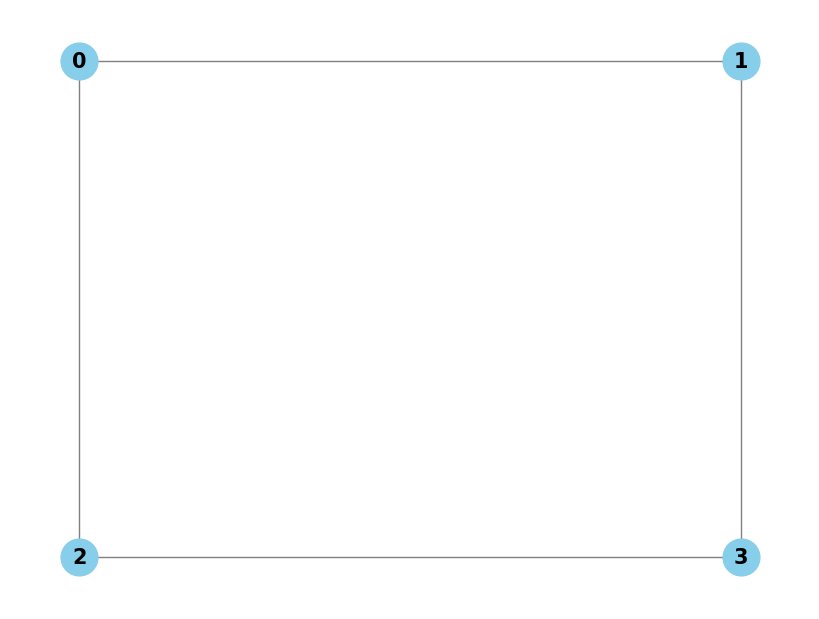

None


Matchings WITH relabeling: 2
Vertex mapping (original -> relabeled): {'11': '00', '01': '01', '10': '10', '00': '11'}
Matchings: [{('01', '00'), ('11', '10')}, {('11', '01'), ('10', '00')}]
Relabeled edges: {('01', '00'), ('11', '01'), ('10', '00'), ('11', '10')}

Matchings WITHOUT relabeling: 2
Matchings: [{('00', '10'), ('01', '11')}, {('00', '01'), ('10', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
With Relabeling: Total = 4, Edges = 4, Per Edge = 1.000
No Relabeling: Total = 4, Edges = 4, Per Edge = 1.000

Relabeled Graph:


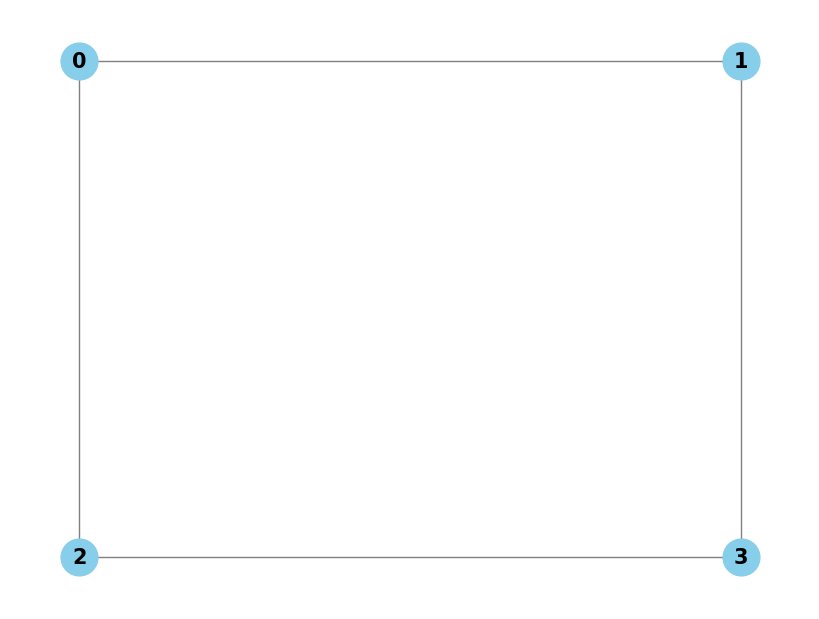

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


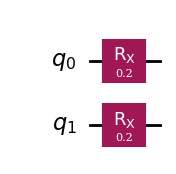


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


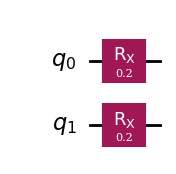

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Cycle Graph C4:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
2        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
5        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
10       |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
20       |    0/0                                 |

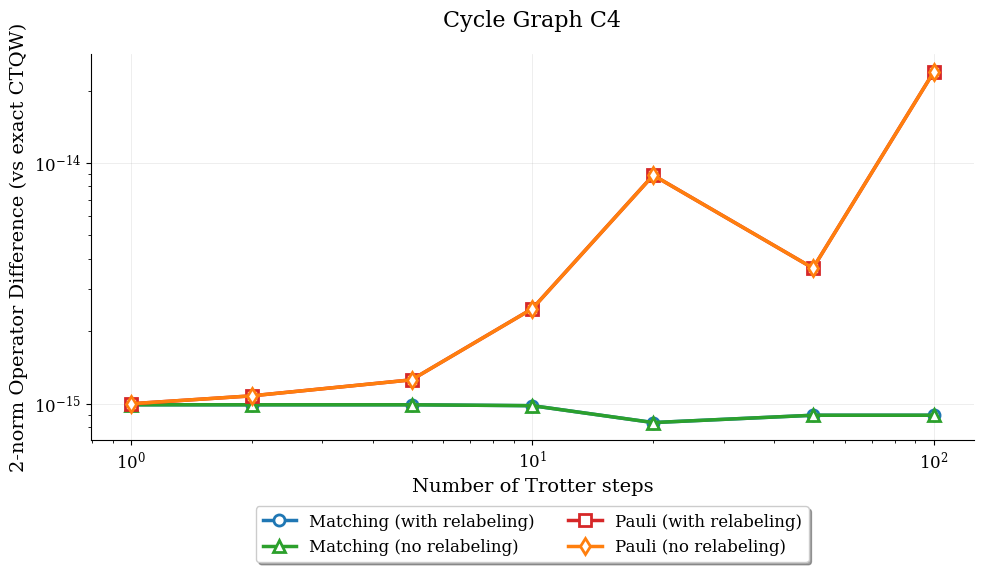

In [4]:
edges = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
analyze_and_plot(edges, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('01', '10'), ('00', '11'), ('00', '01'), ('00', '10'), ('01', '11')}
Number of qubits: 2

Original Graph:


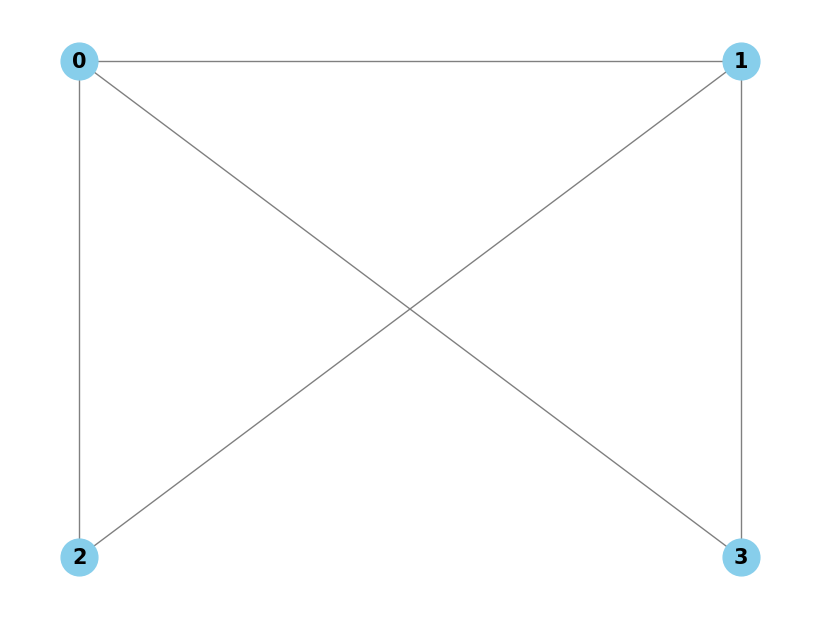

None


Matchings WITH relabeling: 3
Vertex mapping (original -> relabeled): {'11': '01', '00': '00', '10': '10', '01': '11'}
Matchings: [{('00', '01'), ('11', '10')}, {('00', '11')}, {('00', '10'), ('11', '01')}]
Relabeled edges: {('11', '10'), ('11', '01'), ('00', '11'), ('00', '01'), ('00', '10')}

Matchings WITHOUT relabeling: 3
Matchings: [{('01', '10'), ('00', '11')}, {('00', '01')}, {('00', '10'), ('01', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
With Relabeling: Total = 6, Edges = 5, Per Edge = 1.200
No Relabeling: Total = 7, Edges = 5, Per Edge = 1.400

Relabeled Graph:


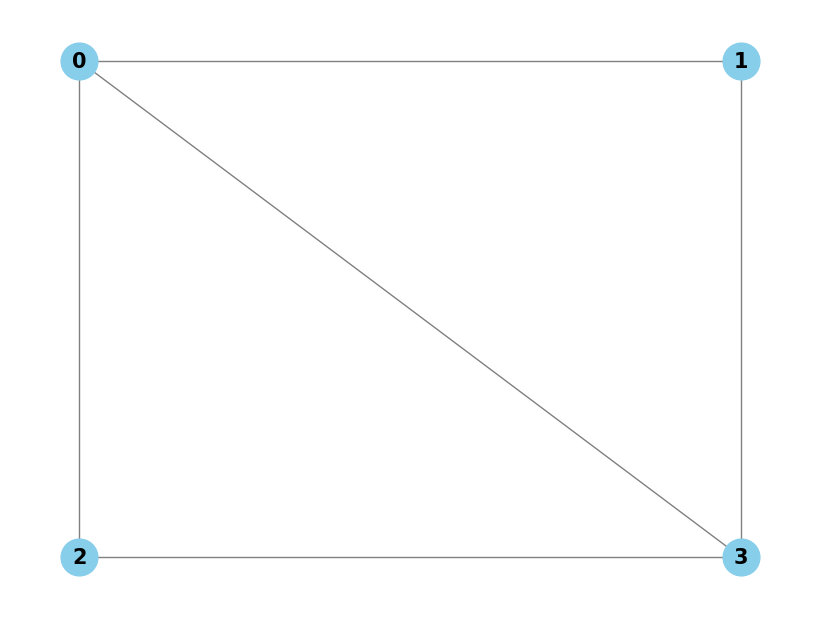

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


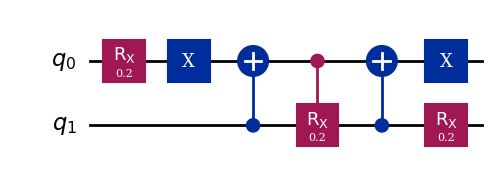


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


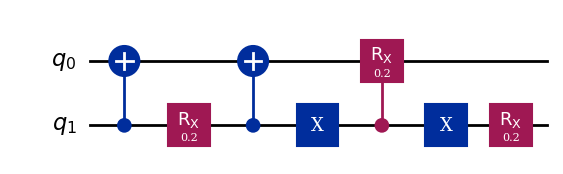

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Complete Graph K4 - C2:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |    4/2                                 |    4/2                                 |    4/2                                 |    4/2   
2        |    8/3                                 |    8/2                                 |    8/3                                 |    8/2   
5        |   20/3                                 |   20/2                                 |   20/3                                 |   20/2   
10       |   40/3                                 |   40/2                                 |   40/3                                 |   40/2   
20       |   80/3                          

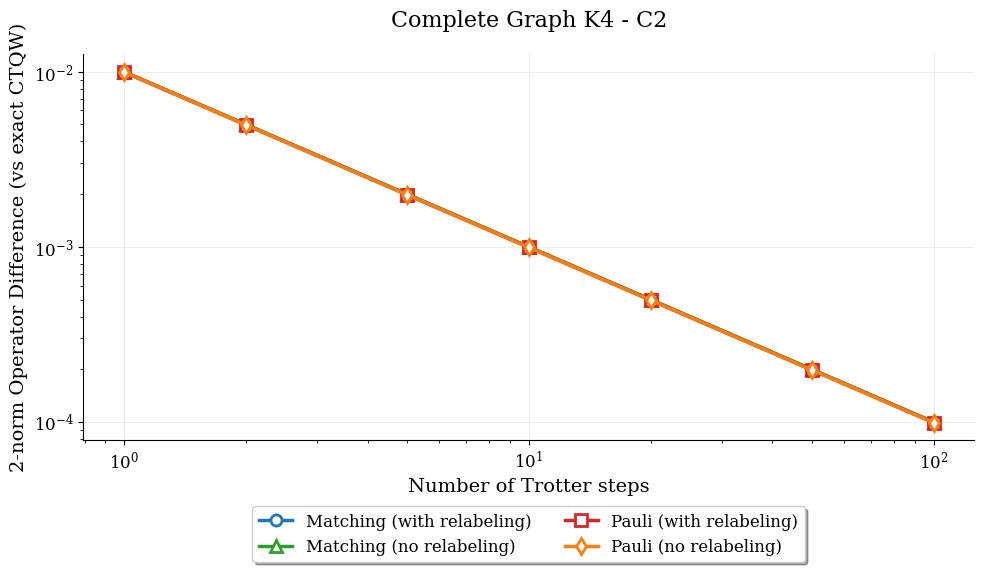

In [5]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
analyze_and_plot(edges, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('01', '10'), ('00', '01'), ('10', '11')}
Number of qubits: 2

Original Graph:


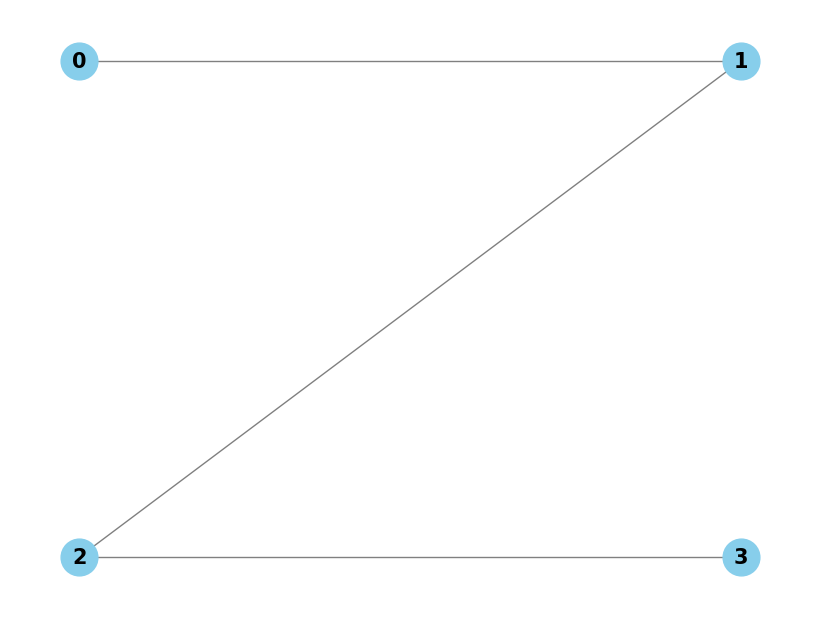

None


Matchings WITH relabeling: 2
Vertex mapping (original -> relabeled): {'00': '00', '01': '01', '11': '10', '10': '11'}
Matchings: [{('01', '11')}, {('00', '01'), ('11', '10')}]
Relabeled edges: {('11', '10'), ('00', '01'), ('01', '11')}

Matchings WITHOUT relabeling: 2
Matchings: [{('01', '10')}, {('00', '01'), ('10', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
With Relabeling: Total = 3, Edges = 3, Per Edge = 1.000
No Relabeling: Total = 4, Edges = 3, Per Edge = 1.333

Relabeled Graph:


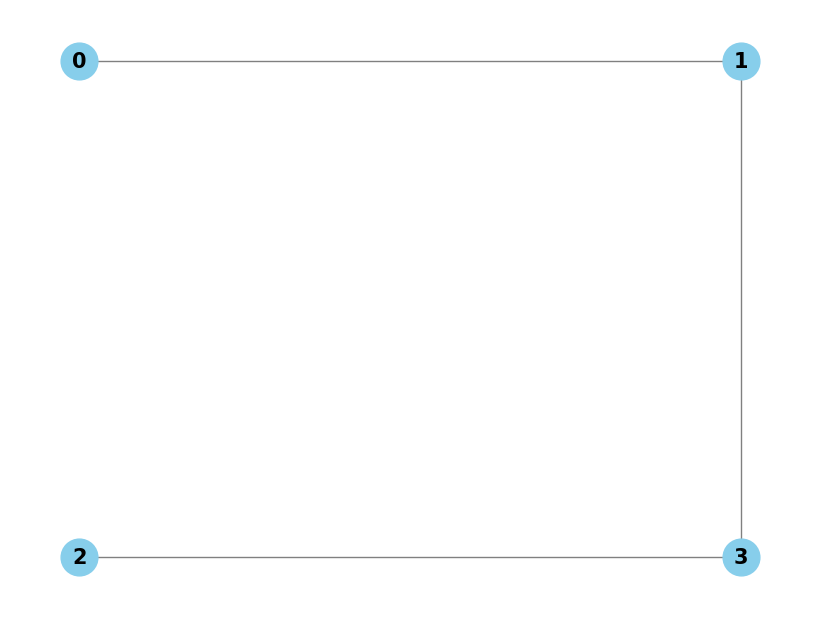

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


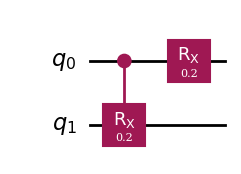


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


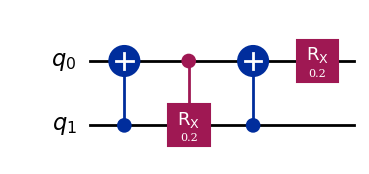

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Path Graph P3:
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |    2/2                                 |    4/2                                 |    2/2                                 |    4/2   
2        |    4/2                                 |    8/2                                 |    4/2                                 |    8/2   
5        |   10/2                                 |   20/2                                 |   10/2                                 |   20/2   
10       |   20/2                                 |   40/2                                 |   20/2                                 |   40/2   
20       |   40/2                                 | 

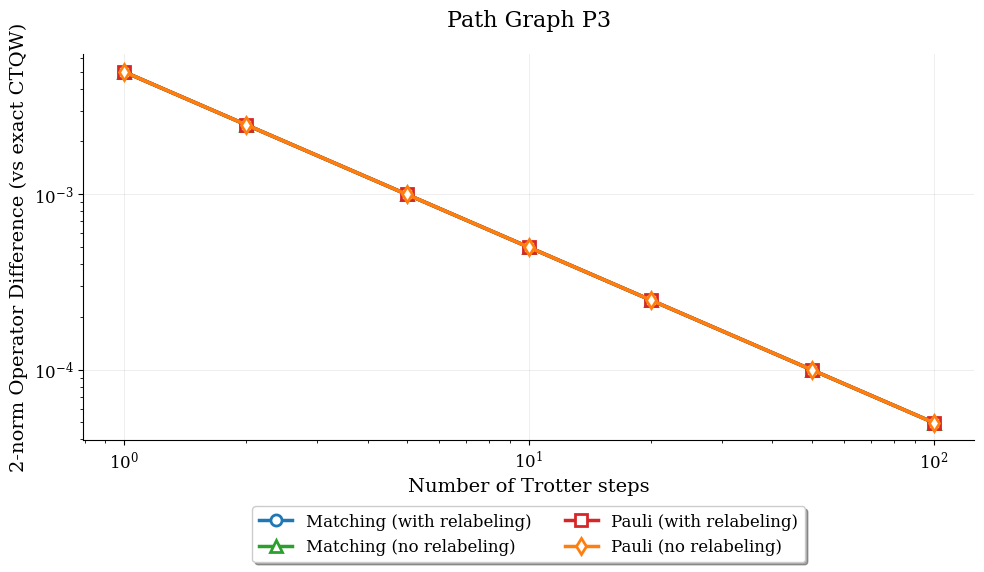

In [6]:
edges = {('00', '01'), ('01', '10'), ('10', '11')}
analyze_and_plot(edges, "Path Graph P3")


Tree Graph (2 qubits)
Original edges: {('00', '10'), ('00', '01'), ('00', '11')}
Number of qubits: 2

Original Graph:


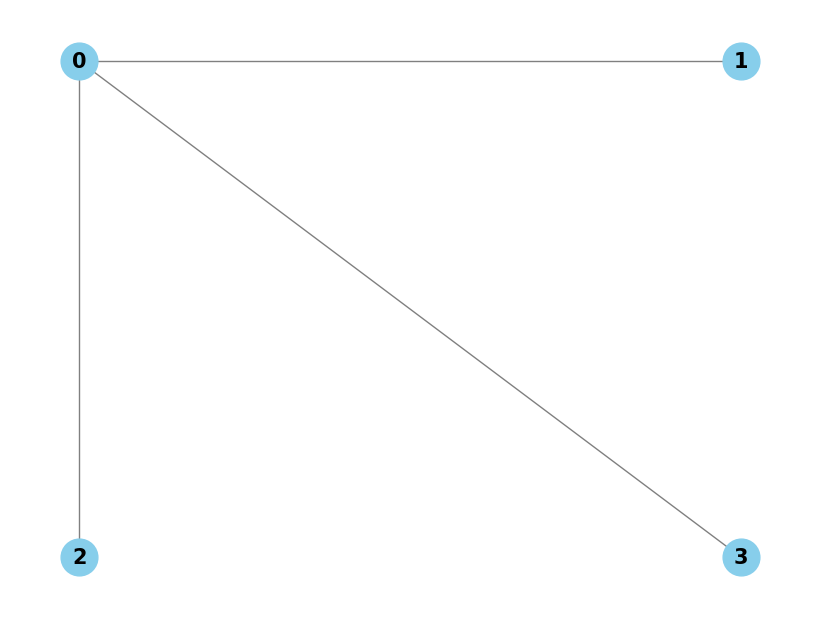

None


Matchings WITH relabeling: 3
Vertex mapping (original -> relabeled): {'11': '00', '00': '01', '10': '10', '01': '11'}
Matchings: [{('01', '10')}, {('01', '11')}, {('01', '00')}]
Relabeled edges: {('01', '10'), ('01', '00'), ('01', '11')}

Matchings WITHOUT relabeling: 3
Matchings: [{('00', '10')}, {('00', '01')}, {('00', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
With Relabeling: Total = 4, Edges = 3, Per Edge = 1.333
No Relabeling: Total = 4, Edges = 3, Per Edge = 1.333

Relabeled Graph:


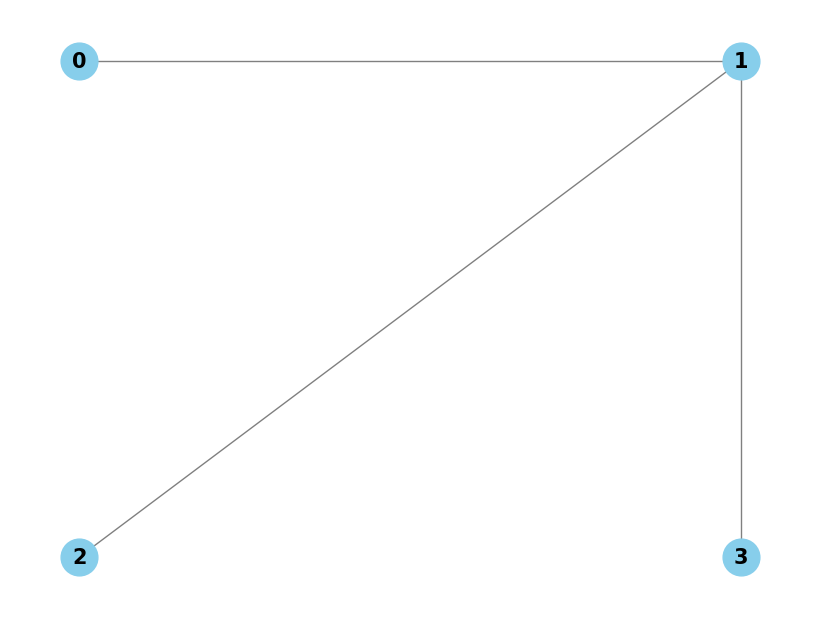

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


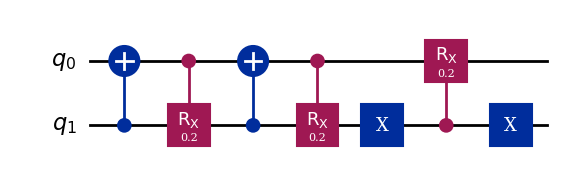


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


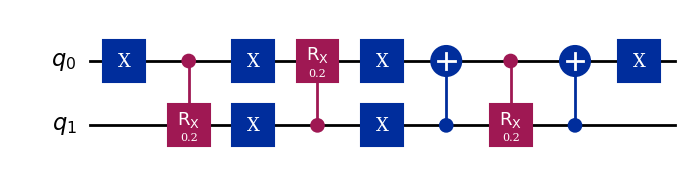

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Tree Graph (2 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |    8/3                                 |    8/3                                 |    8/3                                 |    8/3   
2        |   16/3                                 |   16/3                                 |   16/3                                 |   16/3   
5        |   40/3                                 |   40/3                                 |   40/3                                 |   40/3   
10       |   80/3                                 |   80/3                                 |   80/3                                 |   80/3   
20       |  160/3                           

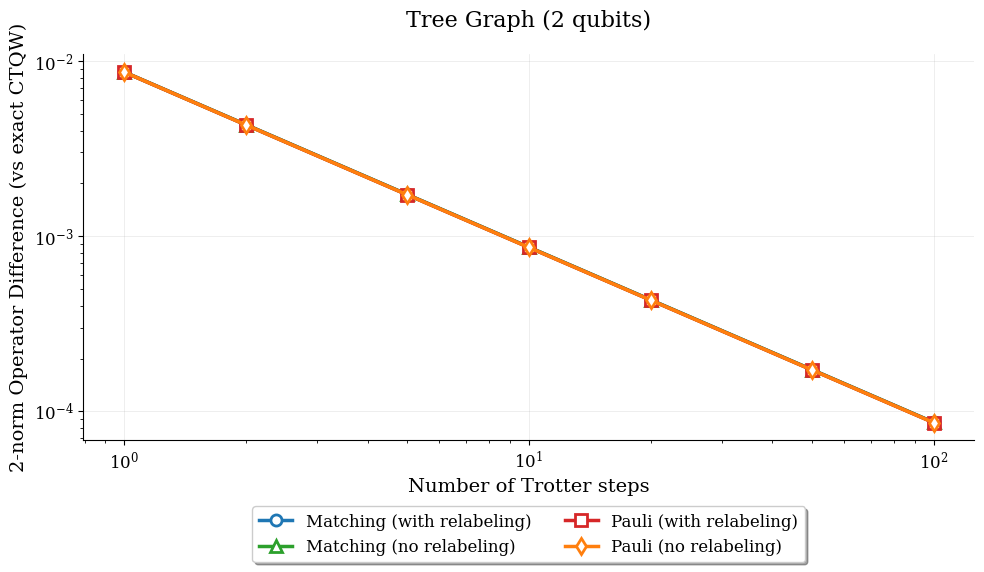

In [7]:
edges = {('00','01'), ('00','10'), ('00','11')}
analyze_and_plot(edges, "Tree Graph (2 qubits)")


Tree Graph (3 qubits)
Original edges: {('000', '111'), ('000', '110'), ('000', '001'), ('000', '100'), ('000', '010'), ('000', '101'), ('000', '011')}
Number of qubits: 3

Original Graph:


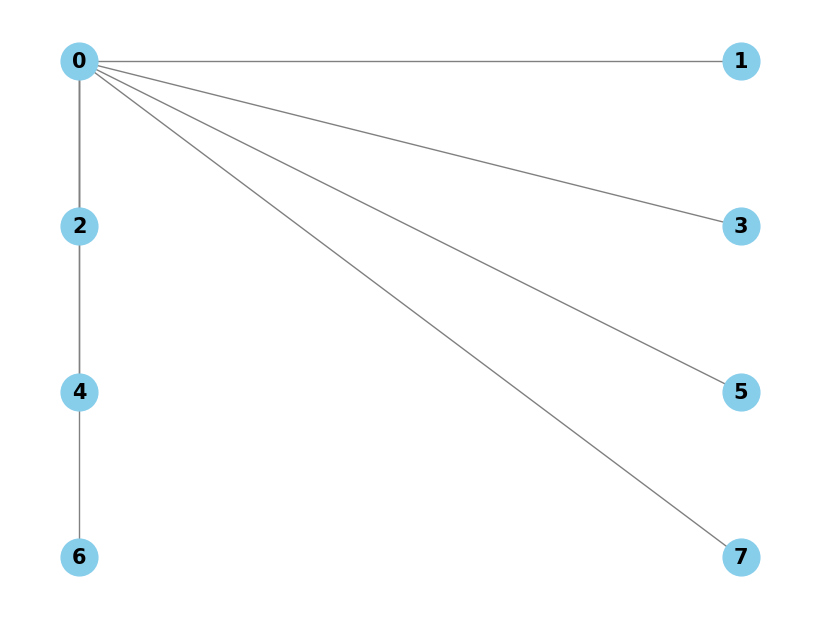

None


Matchings WITH relabeling: 7
Vertex mapping (original -> relabeled): {'011': '000', '000': '001', '111': '010', '101': '011', '001': '100', '110': '101', '100': '110', '010': '111'}
Matchings: [{('001', '010')}, {('001', '100')}, {('001', '110')}, {('001', '111')}, {('001', '101')}, {('001', '011')}, {('001', '000')}]
Relabeled edges: {('001', '011'), ('001', '111'), ('001', '000'), ('001', '110'), ('001', '100'), ('001', '010'), ('001', '101')}

Matchings WITHOUT relabeling: 7
Matchings: [{('000', '111')}, {('000', '110')}, {('000', '101')}, {('000', '011')}, {('000', '001')}, {('000', '100')}, {('000', '010')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 12, Edges = 7, Per Edge = 1.714
No Relabeling: Total = 12, Edges = 7, Per Edge = 1.714

Relabeled Graph:


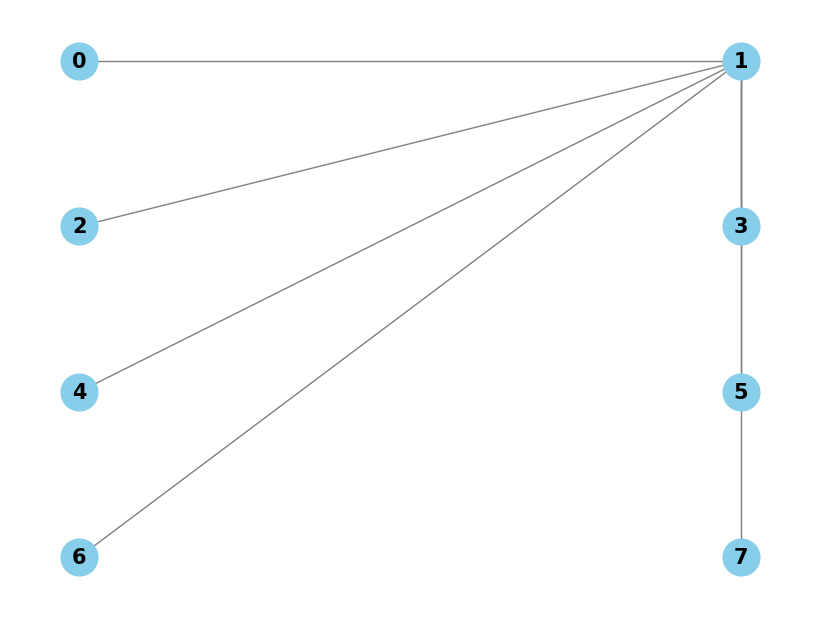

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


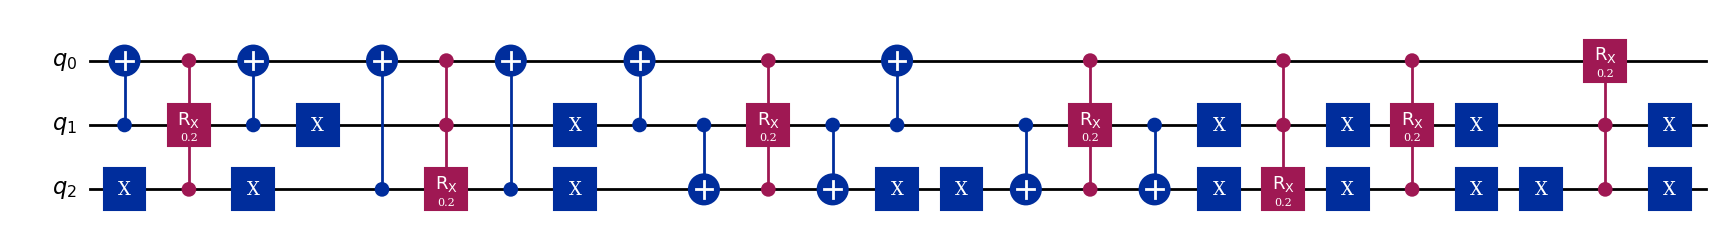


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


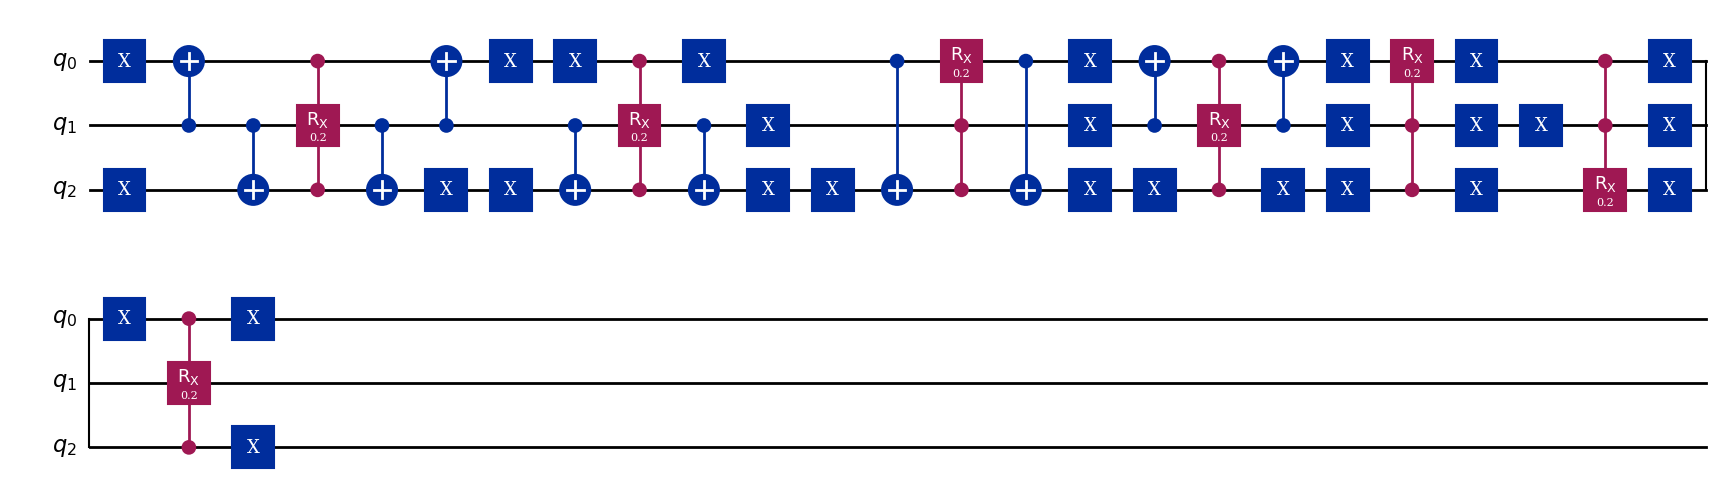

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Tree Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |   66/59                                |   66/60                                |   76/30                                |   76/30  
2        |  132/117                               |  132/119                               |  152/60                                |  152/60  
5        |  330/291                               |  330/296                               |  380/150                               |  380/150 
10       |  660/581                               |  660/591                               |  760/300                               |  760/300 
20       | 1320/1161                        

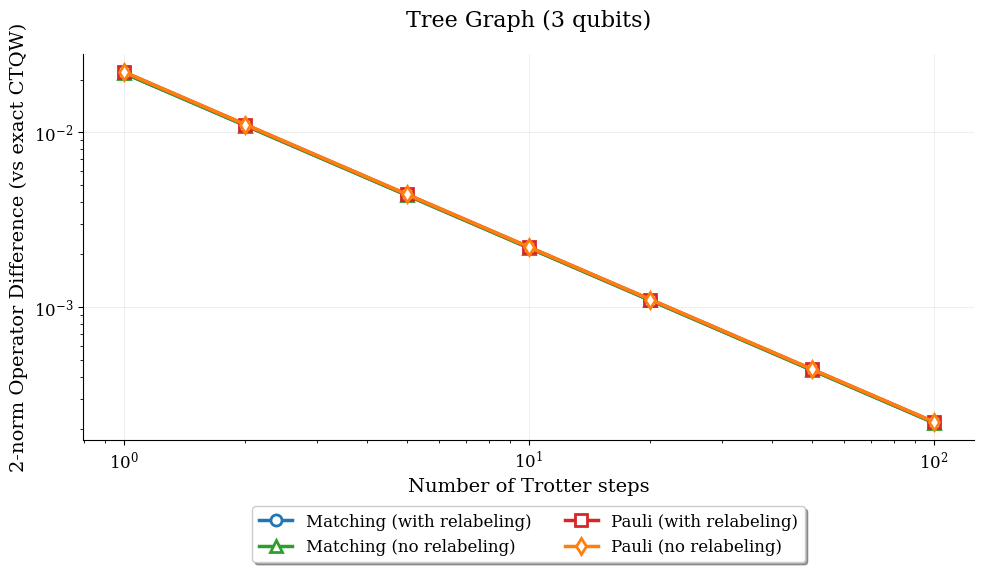

In [8]:
edges = {('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'), ('000','111')}
analyze_and_plot(edges, "Tree Graph (3 qubits)")


Dense Non-Bipartite Graph (3 qubits)
Original edges: {('011', '101'), ('000', '110'), ('000', '100'), ('001', '010'), ('001', '101'), ('011', '111'), ('101', '111'), ('000', '001'), ('101', '110'), ('100', '101'), ('011', '100'), ('001', '011'), ('001', '111'), ('110', '111'), ('000', '010'), ('001', '100'), ('000', '101'), ('010', '111'), ('010', '011'), ('100', '111'), ('100', '110'), ('010', '110'), ('010', '100'), ('000', '011')}
Number of qubits: 3

Original Graph:


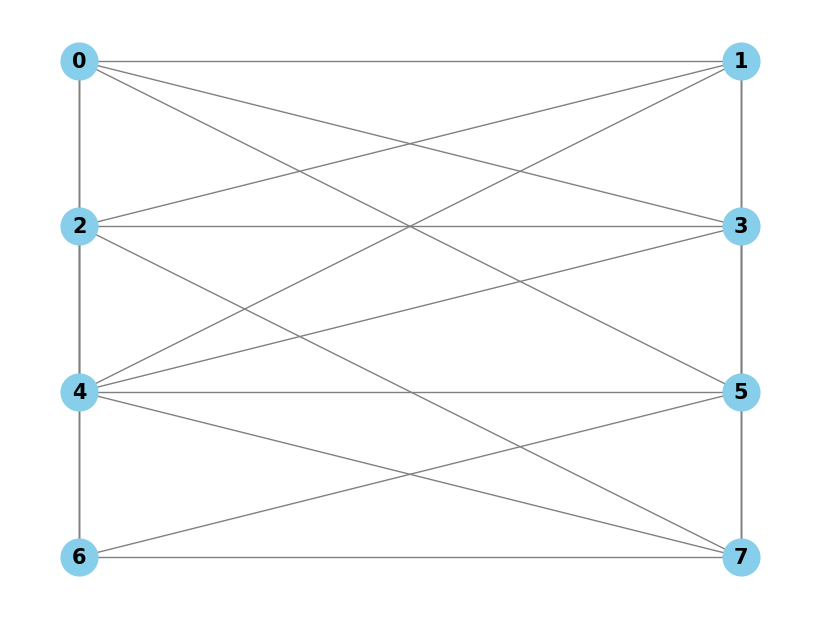

None


Matchings WITH relabeling: 7
Vertex mapping (original -> relabeled): {'111': '111', '101': '101', '001': '001', '011': '011', '110': '110', '000': '000', '100': '100', '010': '010'}
Matchings: [{('001', '010'), ('000', '110'), ('100', '111'), ('011', '101')}, {('011', '100'), ('001', '111'), ('101', '110')}, {('001', '100'), ('000', '101'), ('010', '111')}, {('000', '011'), ('010', '100')}, {('010', '110'), ('001', '101'), ('011', '111'), ('000', '100')}, {('001', '011'), ('000', '010'), ('100', '110'), ('101', '111')}, {('010', '011'), ('000', '001'), ('110', '111'), ('100', '101')}]
Relabeled edges: {('000', '110'), ('011', '101'), ('000', '100'), ('001', '010'), ('001', '101'), ('011', '111'), ('101', '111'), ('000', '001'), ('101', '110'), ('100', '101'), ('011', '100'), ('001', '011'), ('001', '111'), ('110', '111'), ('001', '100'), ('010', '111'), ('000', '101'), ('000', '010'), ('100', '111'), ('010', '011'), ('100', '110'), ('010', '110'), ('010', '100'), ('000', '011')}

Matc

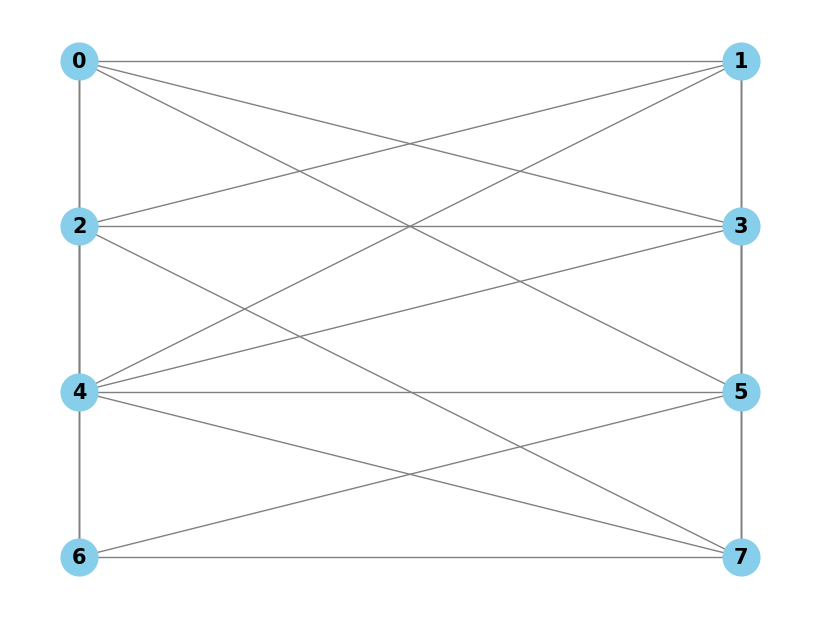

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


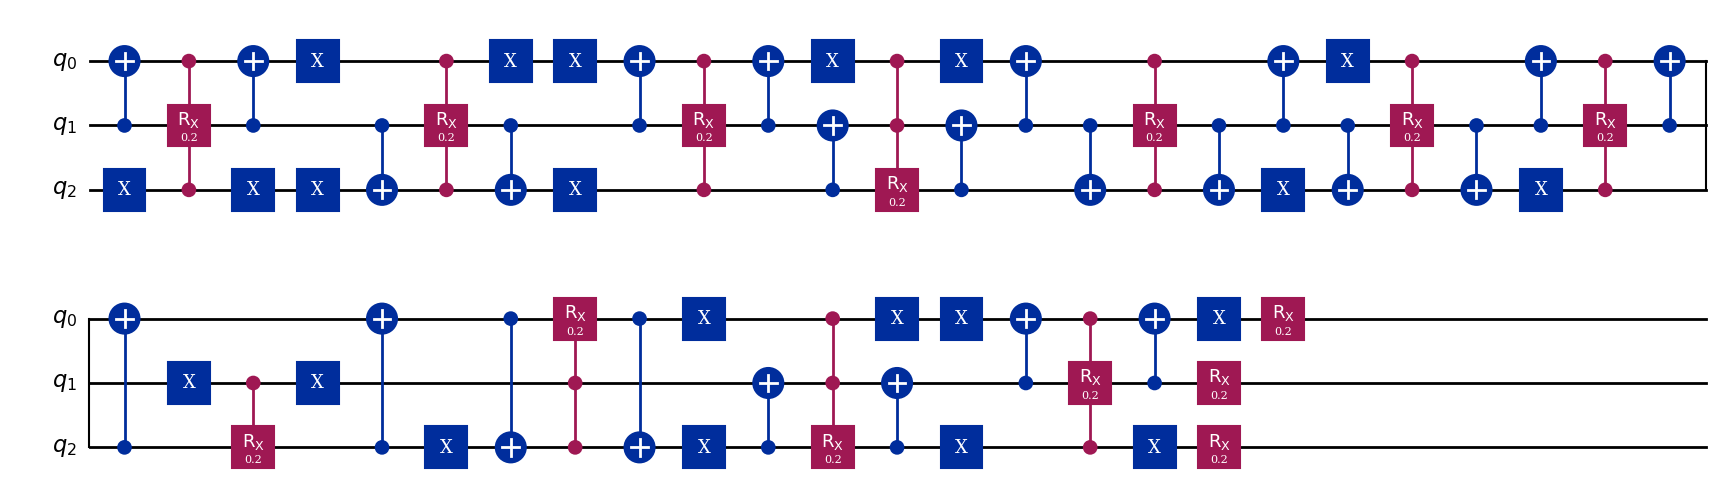


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


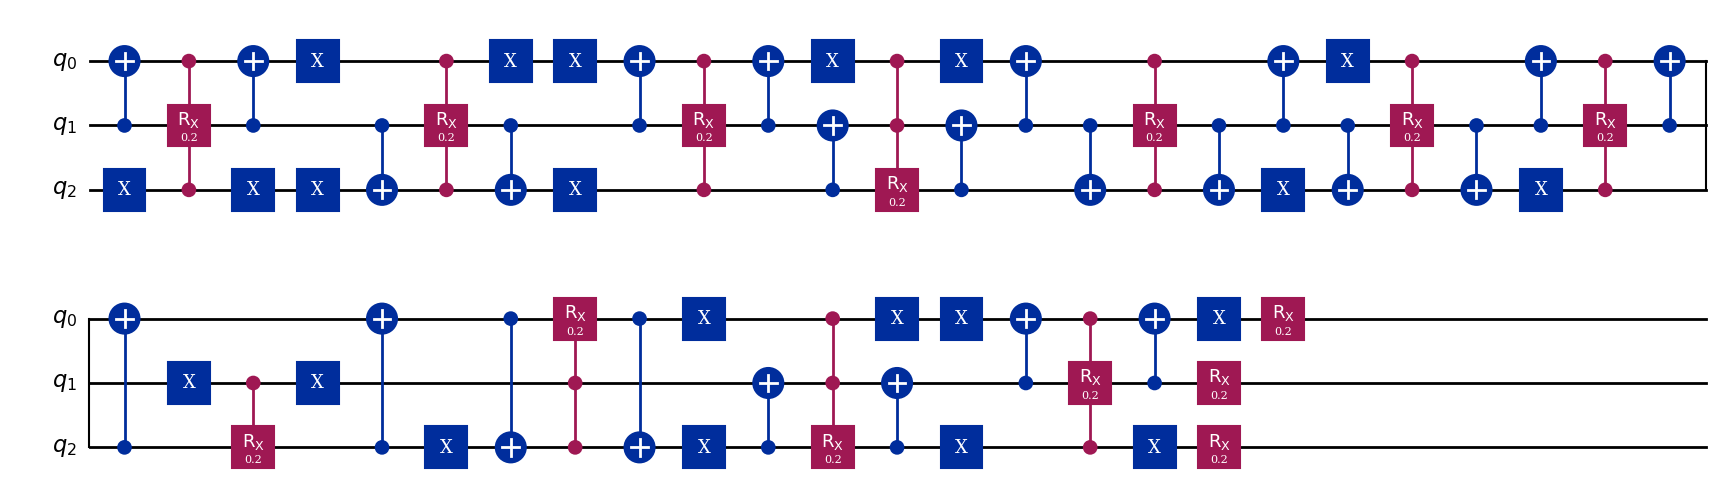

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Dense Non-Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |  106/94                                |  106/94                                |   32/20                                |   32/20  
2        |  212/187                               |  212/187                               |   64/40                                |   64/40  
5        |  530/466                               |  530/466                               |  160/100                               |  160/100 
10       | 1060/931                               | 1060/931                               |  320/200                               |  320/200 
20       | 2120/1861         

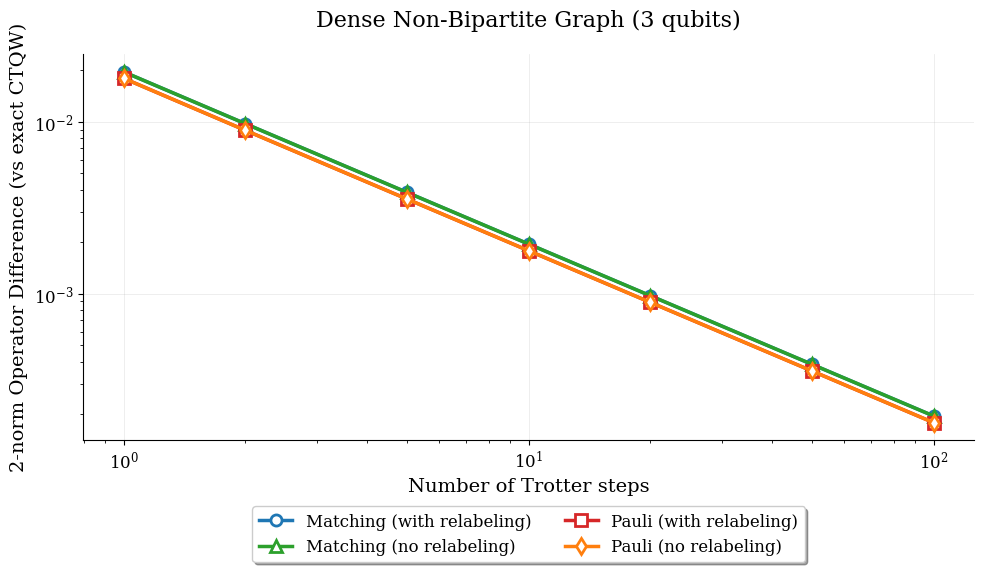

In [9]:
dense_nonbipartite_8 = {
    ('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'),
    ('001','010'), ('001','011'), ('001','100'), ('001','101'), ('001','111'),
    ('010','011'), ('010','100'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','111'),
    ('100','101'), ('100','110'), ('100','111'),
    ('101','110'), ('101','111'),
    ('110','111')
}

analyze_and_plot(dense_nonbipartite_8, "Dense Non-Bipartite Graph (3 qubits)")


Dense Bipartite Graph (3 qubits)
Original edges: {('000', '111'), ('000', '110'), ('000', '100'), ('001', '101'), ('011', '111'), ('011', '110'), ('010', '101'), ('011', '100'), ('001', '111'), ('001', '110'), ('001', '100'), ('010', '111'), ('000', '101'), ('010', '110'), ('010', '100'), ('011', '101')}
Number of qubits: 3

Original Graph:


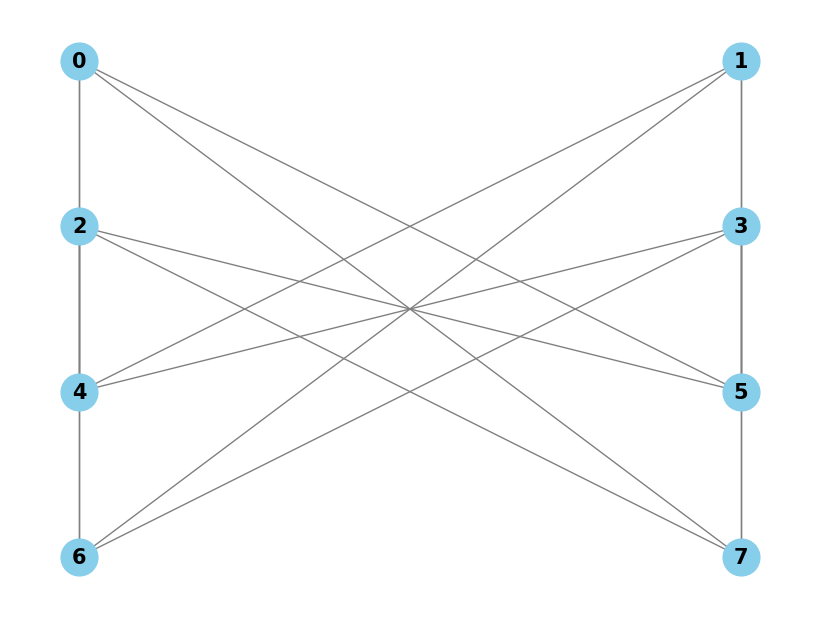

None


Matchings WITH relabeling: 4
Vertex mapping (original -> relabeled): {'111': '111', '101': '101', '001': '001', '011': '011', '110': '110', '000': '000', '100': '100', '010': '010'}
Matchings: [{('110', '010'), ('111', '011'), ('001', '101'), ('000', '100')}, {('100', '001'), ('111', '010'), ('000', '101'), ('110', '011')}, {('101', '011'), ('000', '110'), ('100', '010'), ('111', '001')}, {('000', '111'), ('100', '011'), ('110', '001'), ('101', '010')}]
Relabeled edges: {('100', '001'), ('000', '111'), ('101', '010'), ('110', '011'), ('000', '110'), ('000', '100'), ('110', '010'), ('111', '011'), ('100', '011'), ('000', '101'), ('001', '101'), ('101', '011'), ('111', '010'), ('100', '010'), ('110', '001'), ('111', '001')}

Matchings WITHOUT relabeling: 4
Matchings: [{('110', '010'), ('111', '011'), ('001', '101'), ('000', '100')}, {('100', '001'), ('111', '010'), ('000', '101'), ('110', '011')}, {('101', '011'), ('000', '110'), ('100', '010'), ('111', '001')}, {('000', '111'), ('100',

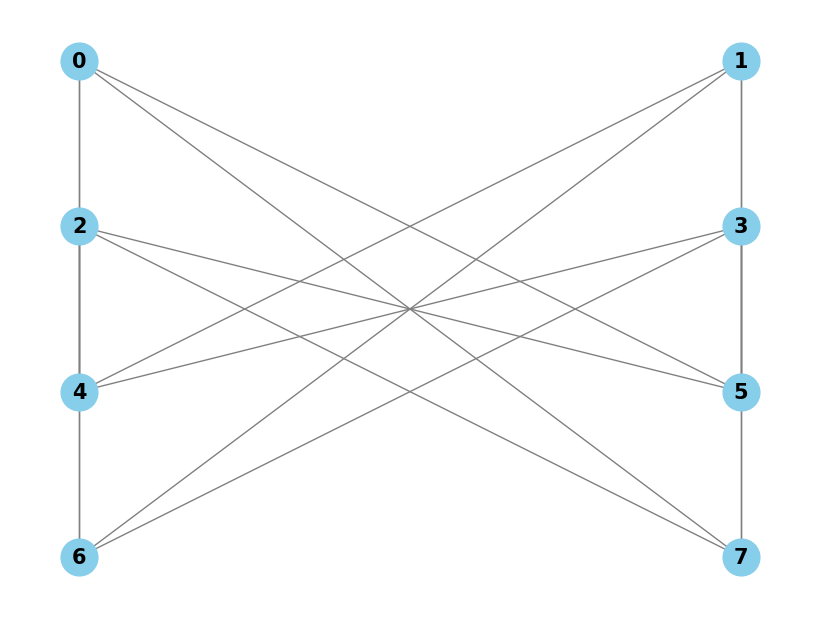

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


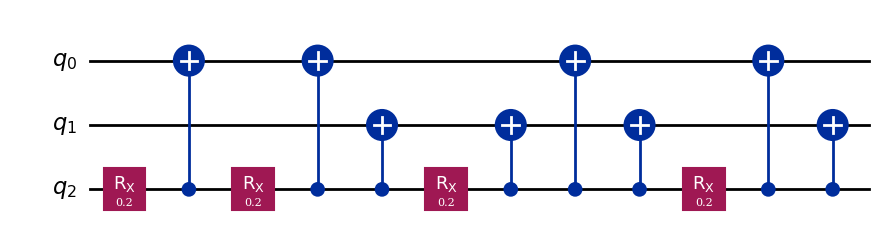


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


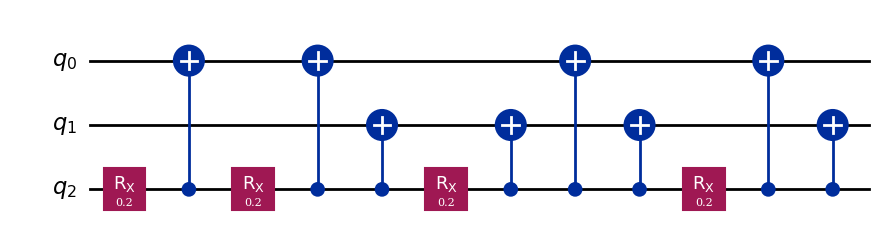

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Dense Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |    8/6                                 |    8/6                                 |    8/6                                 |    8/6   
2        |   16/12                                |   16/12                                |   16/12                                |   16/12  
5        |   40/30                                |   40/30                                |   40/30                                |   40/30  
10       |   80/60                                |   80/60                                |   80/60                                |   80/60  
20       |  160/120              

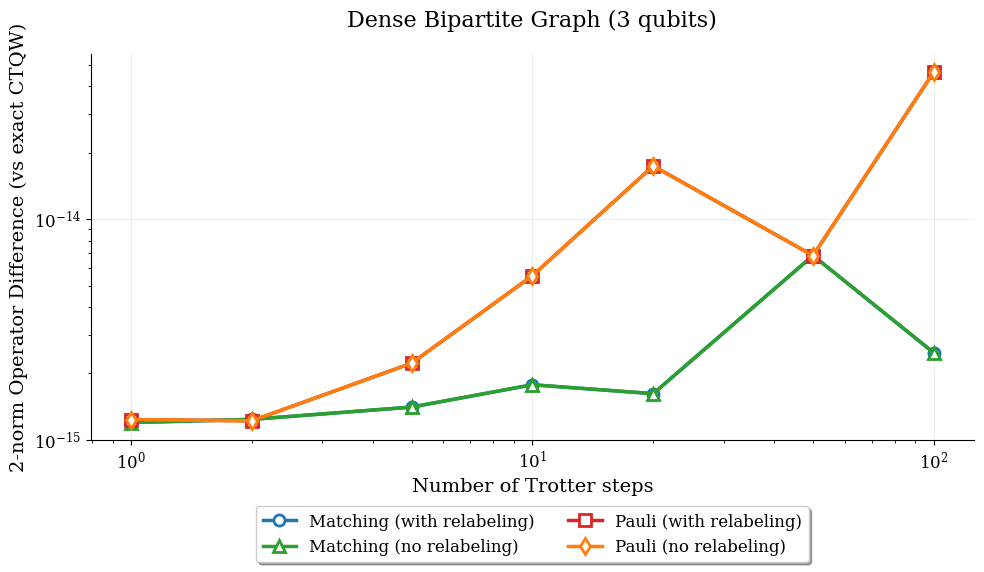

In [10]:
dense_bipartite_8 = {
    ('000','100'), ('000','101'), ('000','110'), ('000','111'),
    ('001','100'), ('001','101'), ('001','110'), ('001','111'),
    ('010','100'), ('010','101'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','110'), ('011','111')  
}
analyze_and_plot(dense_bipartite_8, "Dense Bipartite Graph (3 qubits)")


Sparse Non-Bipartite Graph (3 qubits)
Original edges: {('100', '101'), ('110', '101'), ('000', '001'), ('110', '111'), ('100', '011'), ('010', '011')}
Number of qubits: 3

Original Graph:


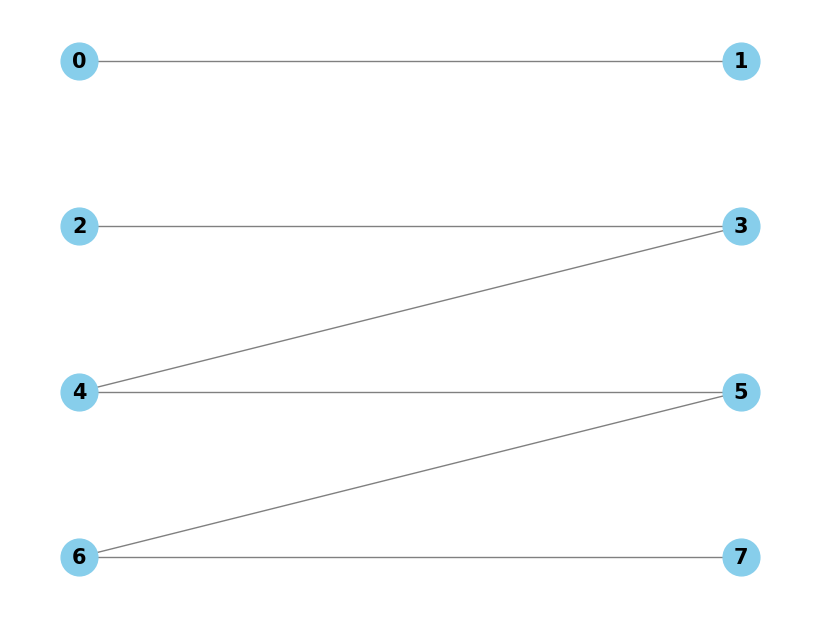

None


Matchings WITH relabeling: 3
Vertex mapping (original -> relabeled): {'111': '000', '110': '001', '101': '010', '100': '011', '001': '100', '000': '101', '010': '110', '011': '111'}
Matchings: [{('101', '100'), ('001', '000'), ('011', '010'), ('110', '111')}, {('001', '010')}, {('011', '111')}]
Relabeled edges: {('001', '000'), ('011', '010'), ('110', '111'), ('101', '100'), ('001', '010'), ('011', '111')}

Matchings WITHOUT relabeling: 2
Matchings: [{('010', '011'), ('000', '001'), ('110', '111'), ('100', '101')}, {('110', '101'), ('100', '011')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 7, Edges = 6, Per Edge = 1.167
No Relabeling: Total = 9, Edges = 6, Per Edge = 1.500

Relabeled Graph:


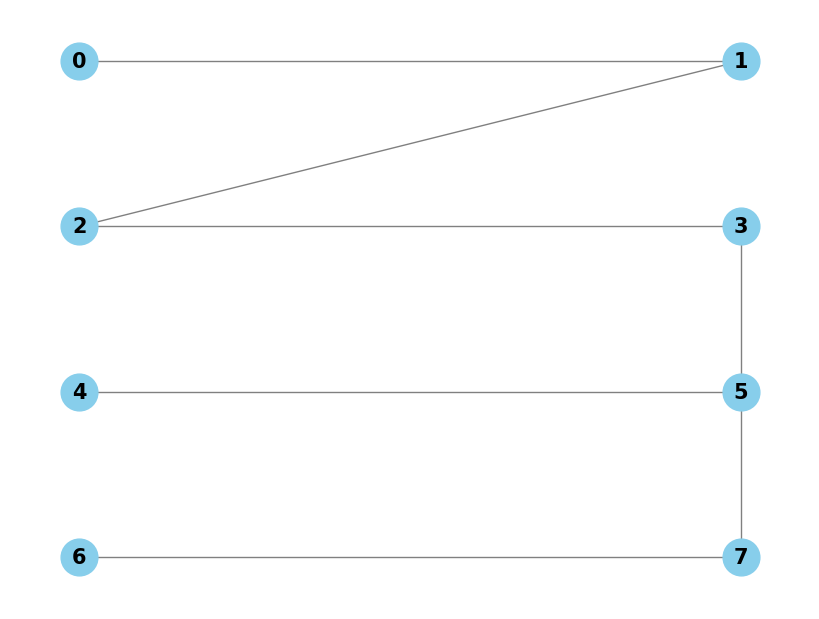

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


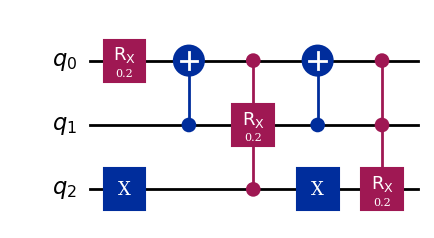


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


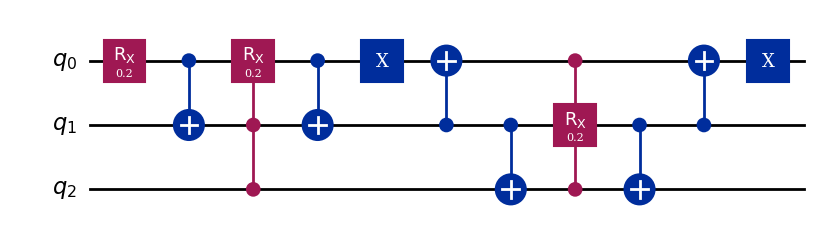

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Sparse Non-Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |   18/17                                |   22/20                                |   20/15                                |   28/23  
2        |   36/34                                |   44/40                                |   40/30                                |   56/46  
5        |   90/85                                |  110/100                               |  100/75                                |  140/115 
10       |  180/170                               |  220/200                               |  200/150                               |  280/230 
20       |  360/340         

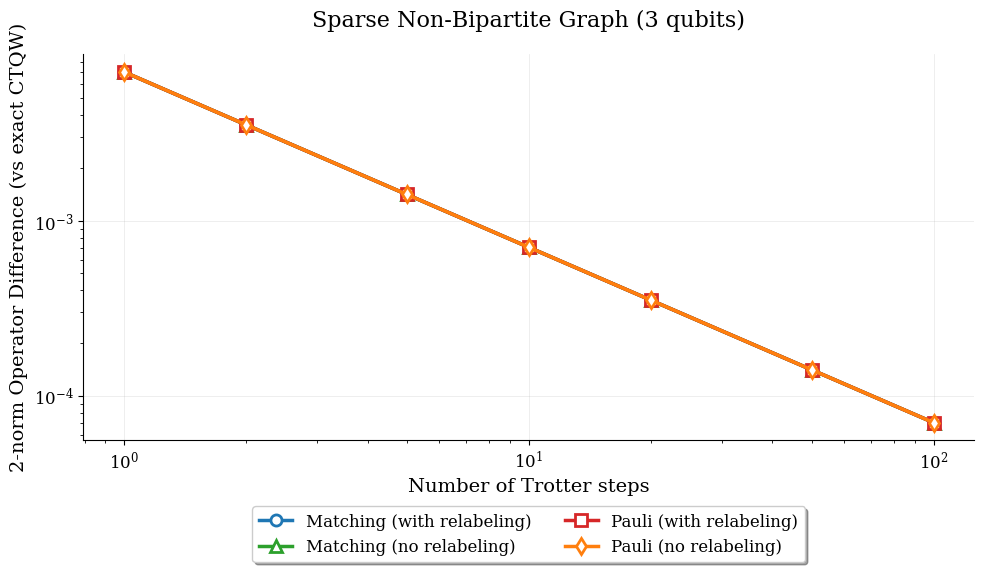

In [11]:
sparse_nonbipartite_8 = {
    ('000','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}
analyze_and_plot(sparse_nonbipartite_8, "Sparse Non-Bipartite Graph (3 qubits)")


Sparse Bipartite Graph (3 qubits)
Original edges: {('100', '101'), ('110', '101'), ('000', '001'), ('110', '111'), ('100', '011'), ('010', '011'), ('010', '001')}
Number of qubits: 3

Original Graph:


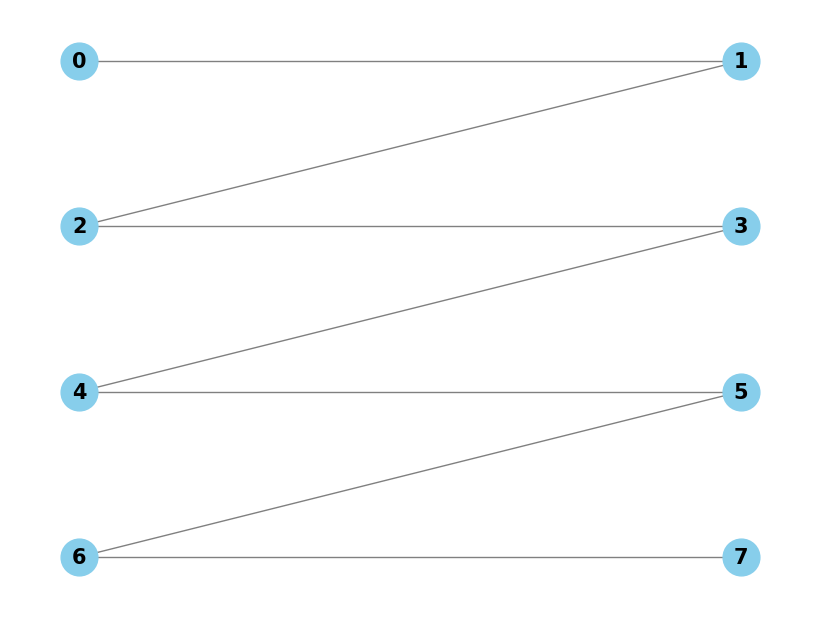

None


Matchings WITH relabeling: 4
Vertex mapping (original -> relabeled): {'111': '000', '110': '001', '101': '010', '100': '011', '001': '100', '000': '101', '010': '110', '011': '111'}
Matchings: [{('101', '100'), ('001', '000'), ('011', '010'), ('110', '111')}, {('001', '010')}, {('011', '111')}, {('110', '100')}]
Relabeled edges: {('001', '000'), ('110', '100'), ('011', '010'), ('110', '111'), ('101', '100'), ('001', '010'), ('011', '111')}

Matchings WITHOUT relabeling: 2
Matchings: [{('010', '011'), ('000', '001'), ('110', '111'), ('100', '101')}, {('110', '101'), ('100', '011'), ('010', '001')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 8, Edges = 7, Per Edge = 1.143
No Relabeling: Total = 11, Edges = 7, Per Edge = 1.571

Relabeled Graph:


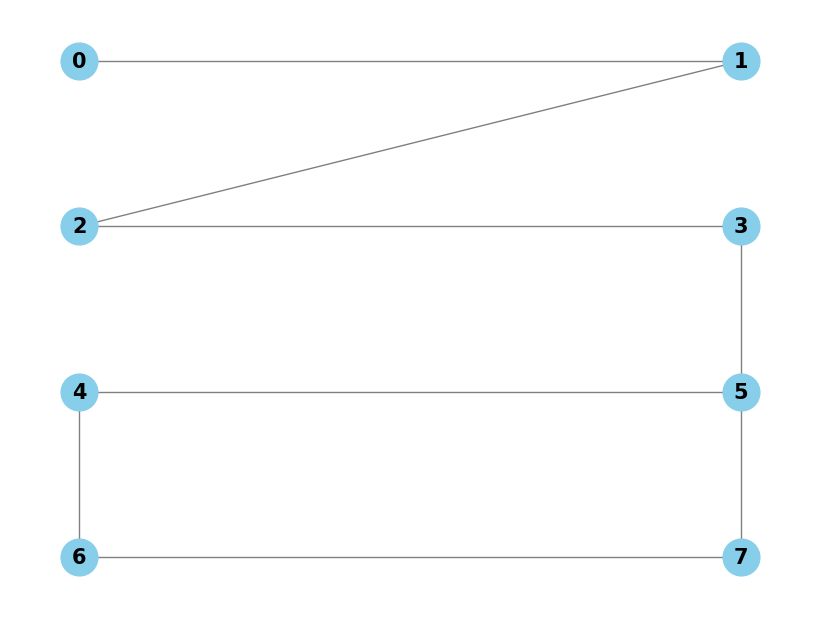

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


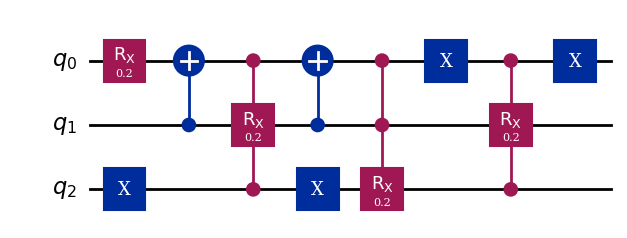


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


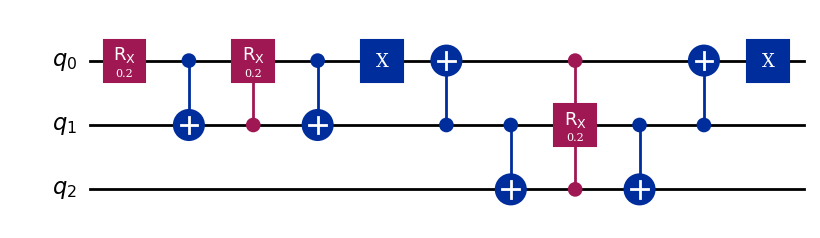

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Sparse Bipartite Graph (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |   26/25                                |   16/12                                |   28/15                                |   20/16  
2        |   52/49                                |   32/23                                |   56/30                                |   40/32  
5        |  130/121                               |   80/56                                |  140/75                                |  100/80  
10       |  260/241                               |  160/111                               |  280/150                               |  200/160 
20       |  520/481             

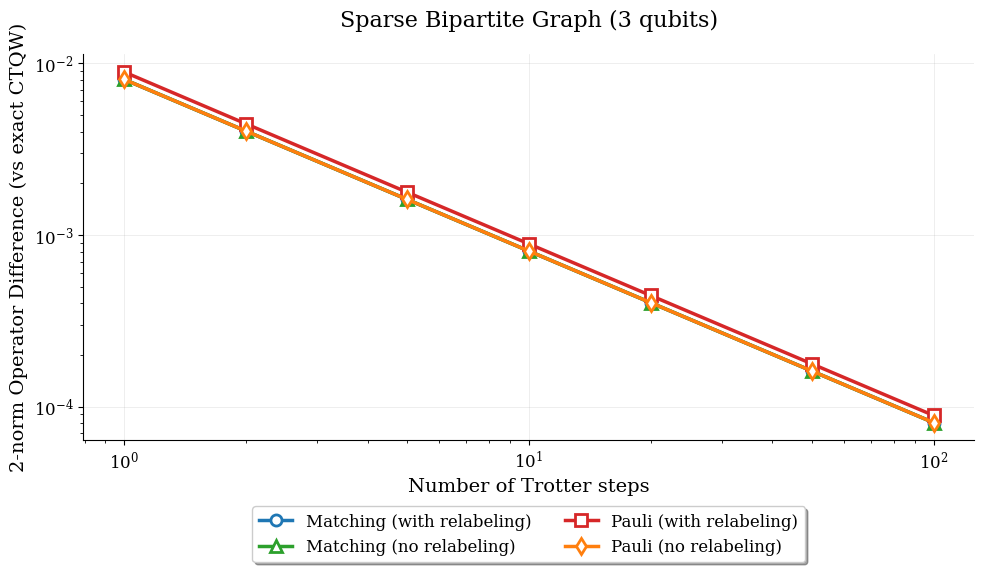

In [12]:
sparse_bipartite_8 = {
    ('000','001'), ('010','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}

analyze_and_plot(sparse_bipartite_8, "Sparse Bipartite Graph (3 qubits)")


Dense Non-Bipartite Graph (4 qubits)
Original edges: {('1010', '1110'), ('1011', '1100'), ('0110', '1100'), ('0010', '0110'), ('0000', '0101'), ('0101', '1001'), ('0111', '1011'), ('1000', '1001'), ('1001', '1110'), ('1110', '1111'), ('1100', '1110'), ('0011', '0111'), ('1000', '1010'), ('1011', '1101'), ('0111', '1101'), ('0010', '1000'), ('1011', '1111'), ('1101', '1110'), ('0111', '1111'), ('0010', '1010'), ('0001', '0100'), ('1000', '1100'), ('0101', '1011'), ('1001', '1010'), ('1000', '1011'), ('1010', '1100'), ('1010', '1011'), ('0101', '1101'), ('0011', '1001'), ('0011', '0101'), ('1001', '1011'), ('0100', '0110'), ('0001', '0011'), ('0000', '0100'), ('0110', '0111'), ('1010', '1111'), ('0000', '0001'), ('0100', '1000'), ('1001', '1101'), ('1100', '1101'), ('0001', '0010'), ('0110', '1110'), ('1100', '1111'), ('0100', '0101'), ('0010', '0100'), ('0001', '1000'), ('0100', '1010'), ('0000', '0111'), ('0011', '1011'), ('0001', '1001'), ('0101', '0111'), ('0000', '0011'), ('0001', 

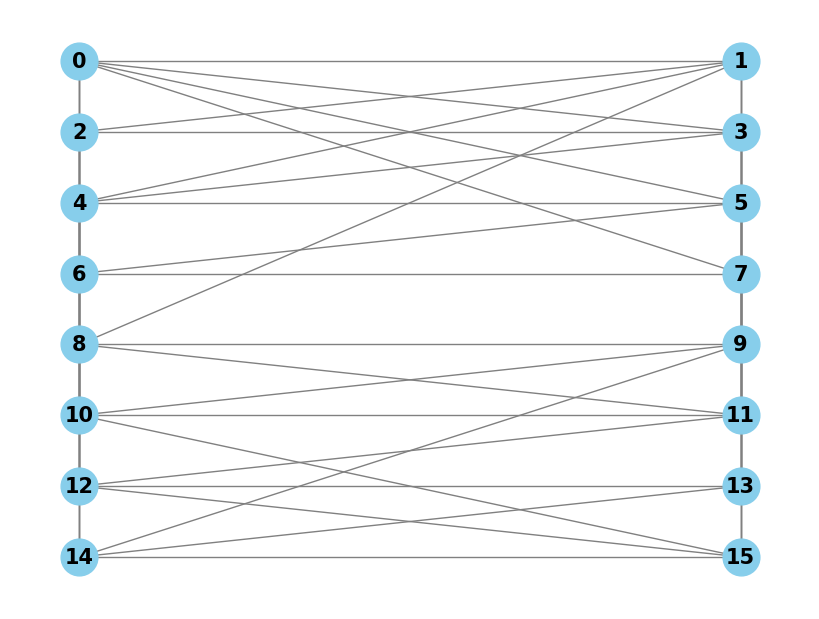

None


Matchings WITH relabeling: 10
Vertex mapping (original -> relabeled): {'0100': '0000', '1100': '1100', '0110': '0110', '0111': '0111', '1111': '1111', '0011': '0011', '0001': '0001', '1010': '1010', '0101': '0101', '0010': '0010', '1001': '1001', '1000': '1000', '1101': '1101', '1110': '1110', '1011': '1011', '0000': '0100'}
Matchings: [{('1010', '1110'), ('0010', '0110'), ('1000', '1100'), ('0001', '0101'), ('1001', '1101'), ('0100', '0000'), ('0011', '0111'), ('1011', '1111')}, {('1011', '1100'), ('0010', '1000'), ('1010', '1111'), ('0101', '1001'), ('0000', '0110'), ('0111', '1101'), ('0100', '0001')}, {('0110', '1100'), ('0111', '1011'), ('0000', '1010'), ('1001', '1110'), ('0001', '0010'), ('0011', '0101')}, {('1001', '1010'), ('0000', '0101'), ('0100', '0111'), ('1011', '1101'), ('1100', '1111'), ('0001', '1000')}, {('0101', '1011'), ('1010', '1100'), ('0100', '0010'), ('0011', '1001'), ('1101', '1110')}, {('0101', '0110'), ('0000', '1100'), ('1000', '1011'), ('0100', '0011')}, 

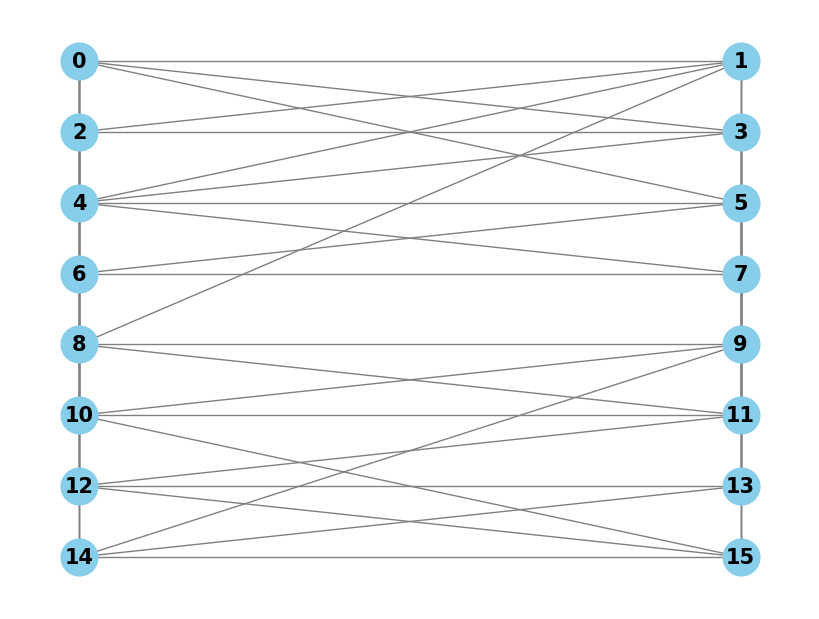

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


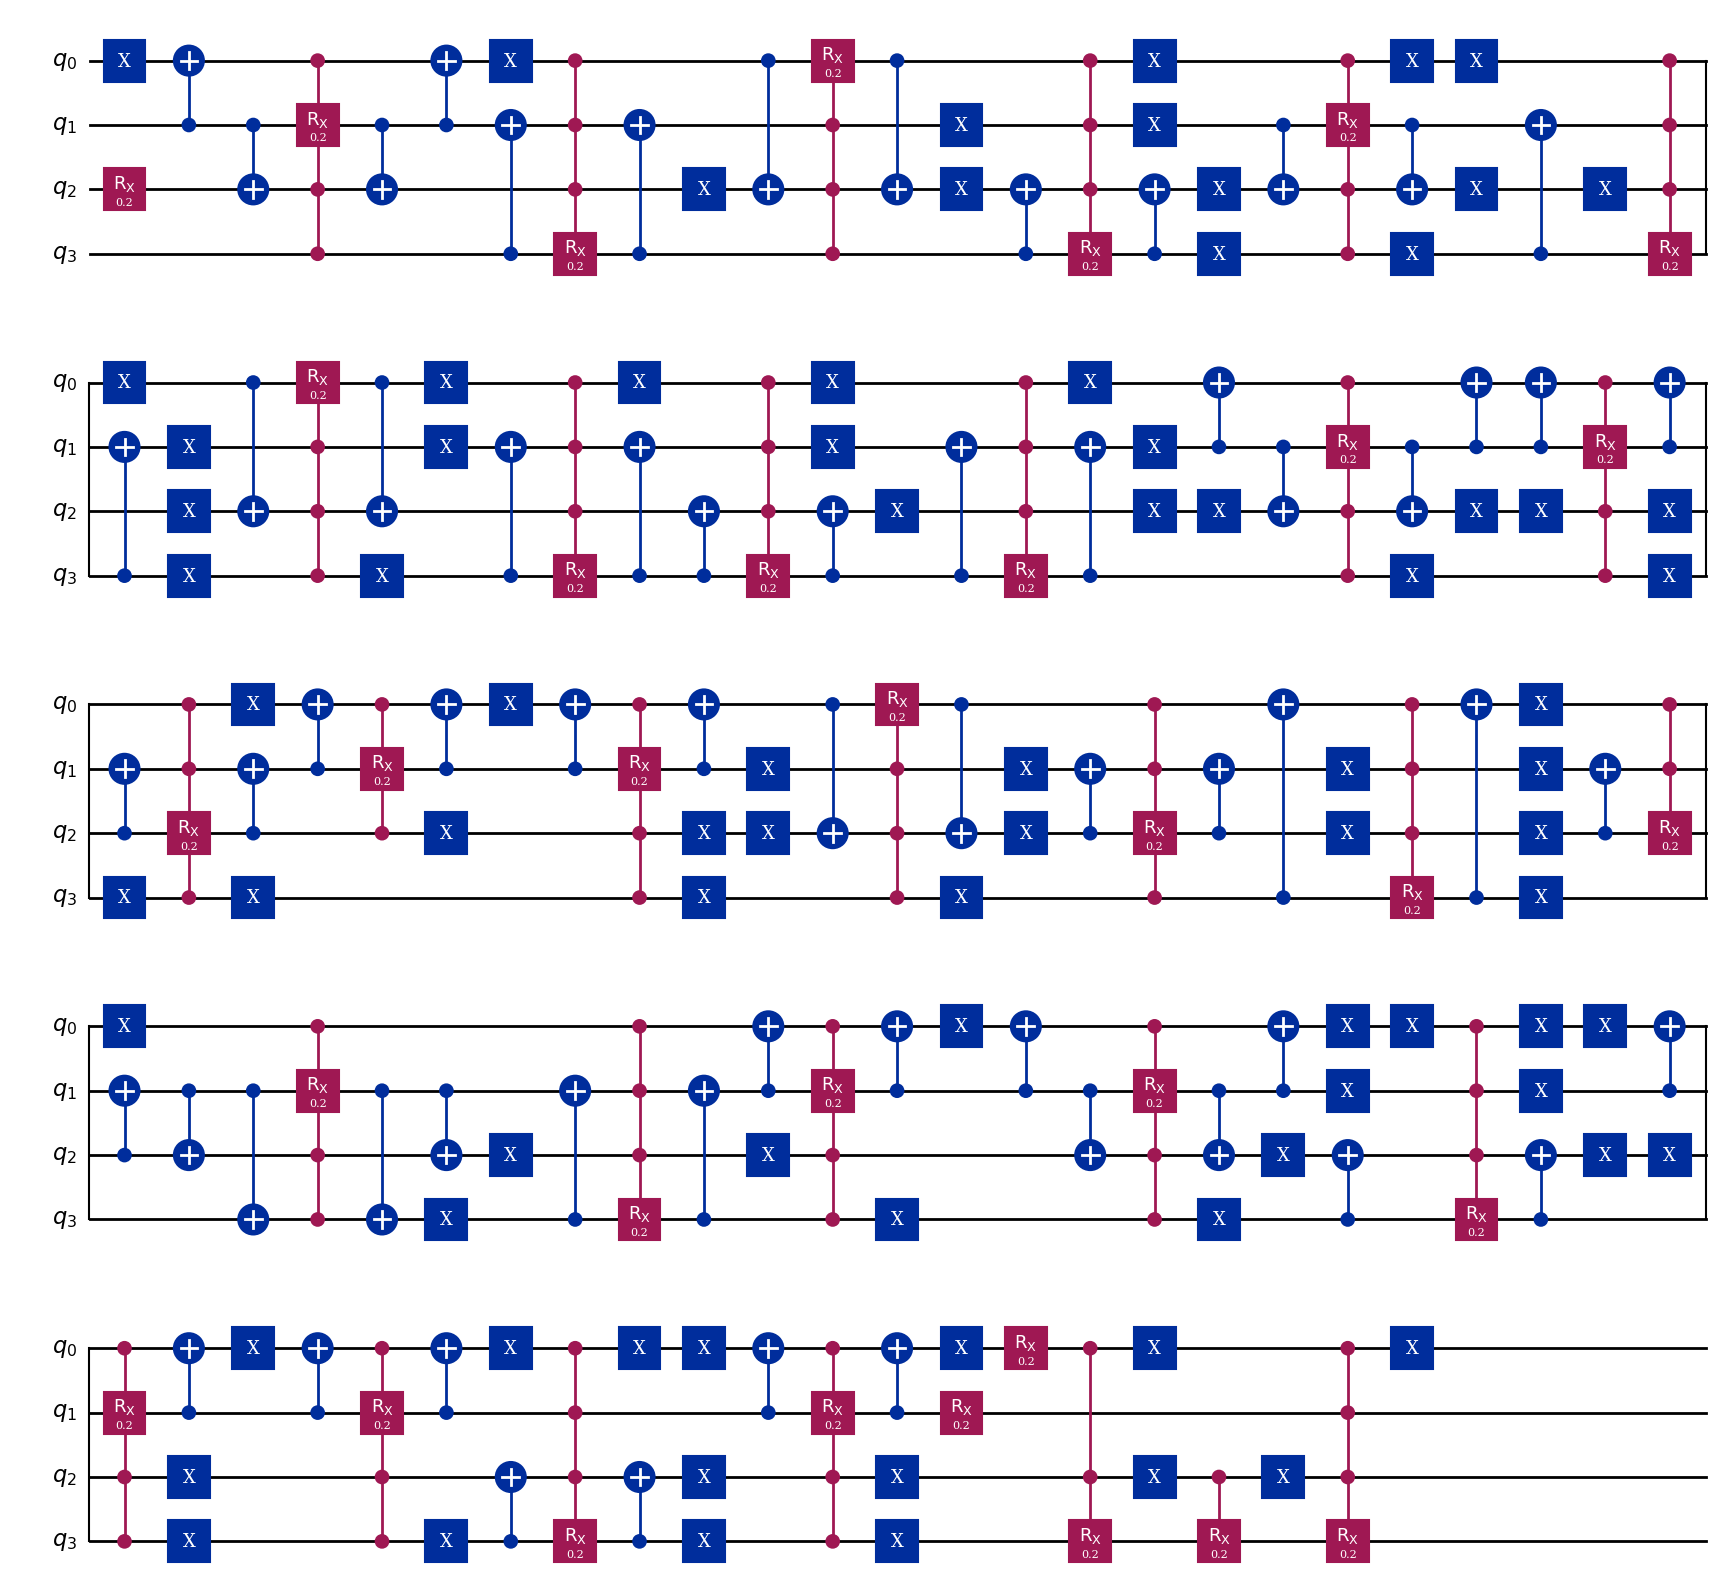


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


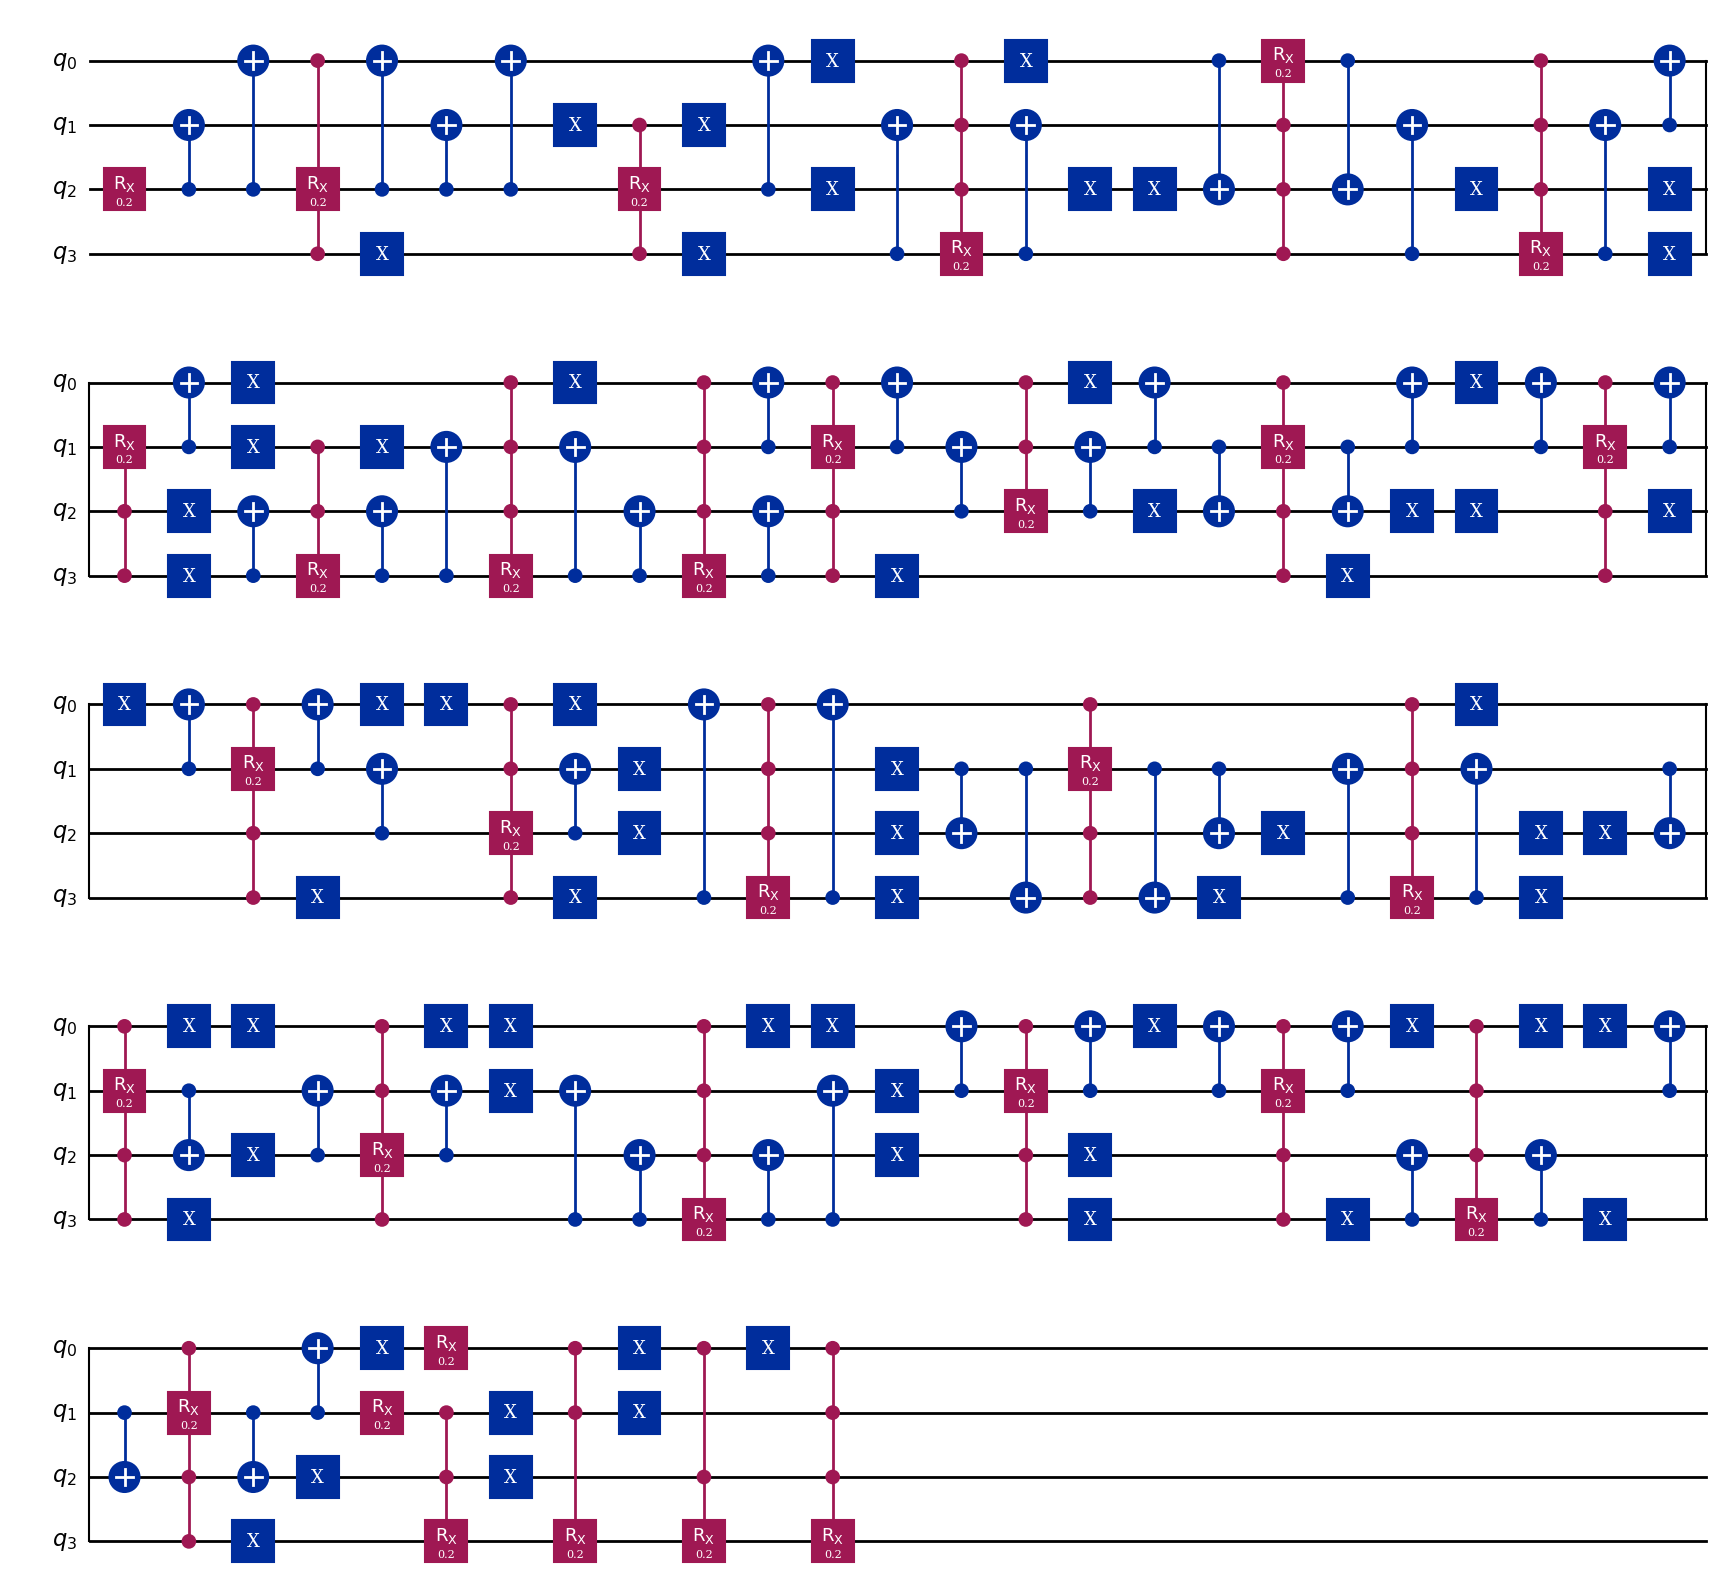

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Dense Non-Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |  630/607                               |  544/520                               |  252/98                                |  200/101 
2        | 1260/1214                              | 1088/1040                              |  504/196                               |  400/202 
5        | 3150/3035                              | 2720/2600                              | 1260/490                               | 1000/505 
10       | 6300/6070                              | 5440/5200                              | 2520/980                               | 2000/1010
20       | 12600/12140       

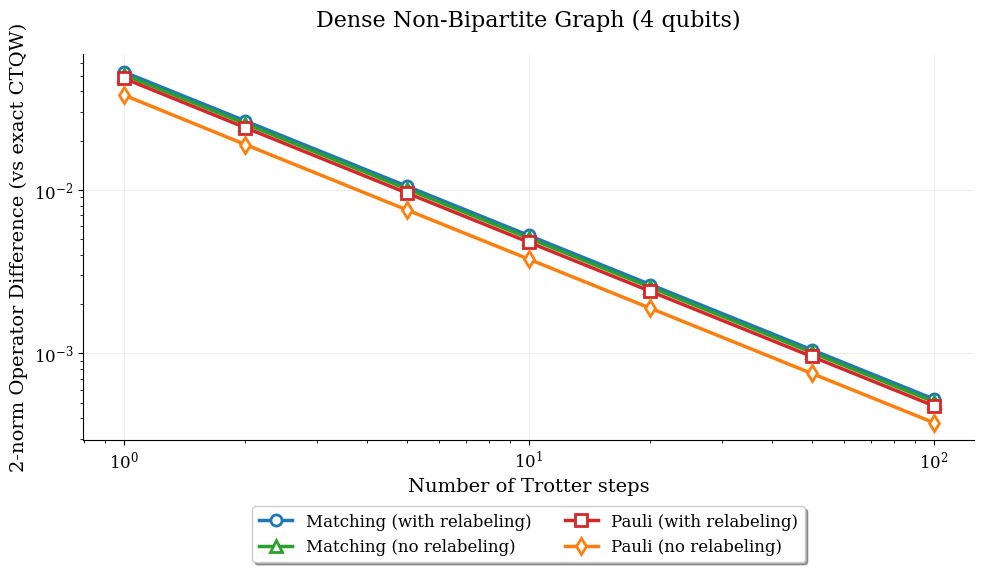

In [13]:
dense_nonbipartite_16 = {
    ('0000','0001'), ('0000','0010'), ('0000','0011'), ('0000','0100'), ('0000','0101'), ('0000','0110'), ('0000','0111'),
    ('0001','0010'), ('0001','0011'), ('0001','0100'), ('0001','0101'), ('0001','1000'), ('0001','1001'),
    ('0010','0011'), ('0010','0100'), ('0010','0110'), ('0010','1000'), ('0010','1010'),
    ('0011','0100'), ('0011','0101'), ('0011','0111'), ('0011','1001'), ('0011','1011'),
    ('0100','0101'), ('0100','0110'), ('0100','1000'), ('0100','1010'), ('0100','1100'),
    ('0101','0110'), ('0101','0111'), ('0101','1001'), ('0101','1011'), ('0101','1101'),
    ('0110','0111'), ('0110','1010'), ('0110','1100'), ('0110','1110'),
    ('0111','1011'), ('0111','1101'), ('0111','1111'),
    ('1000','1001'), ('1000','1010'), ('1000','1011'), ('1000','1100'),
    ('1001','1010'), ('1001','1011'), ('1001','1101'), ('1001','1110'),
    ('1010','1011'), ('1010','1100'), ('1010','1110'), ('1010','1111'),
    ('1011','1100'), ('1011','1101'), ('1011','1111'),
    ('1100','1101'), ('1100','1110'), ('1100','1111'),
    ('1101','1110'), ('1101','1111'),
    ('1110','1111')
}
analyze_and_plot(dense_nonbipartite_16, "Dense Non-Bipartite Graph (4 qubits)")


Dense Bipartite Graph (4 qubits)
Original edges: {('0001', '1011'), ('0101', '1000'), ('0101', '1001'), ('0010', '1110'), ('0000', '1010'), ('0110', '1011'), ('0111', '1011'), ('0001', '1101'), ('0001', '1111'), ('0111', '1101'), ('0110', '1101'), ('0010', '1001'), ('0111', '1111'), ('0110', '1111'), ('0101', '1100'), ('0000', '1011'), ('0000', '1101'), ('0000', '1111'), ('0011', '1001'), ('0010', '1011'), ('0100', '1110'), ('0010', '1111'), ('0001', '1000'), ('0100', '1010'), ('0011', '1011'), ('0001', '1001'), ('0110', '1000'), ('0111', '1000'), ('0111', '1001'), ('0101', '1110'), ('0100', '1100'), ('0001', '1100'), ('0000', '1000'), ('0111', '1100'), ('0110', '1100'), ('0100', '1101'), ('0000', '1001'), ('0100', '1111'), ('0101', '1010'), ('0010', '1000'), ('0000', '1100'), ('0010', '1010'), ('0011', '1110'), ('0101', '1011'), ('0101', '1101'), ('0010', '1100'), ('0011', '1000'), ('0101', '1111'), ('0011', '1010'), ('0010', '1101'), ('0001', '1110'), ('0100', '1000'), ('0111', '111

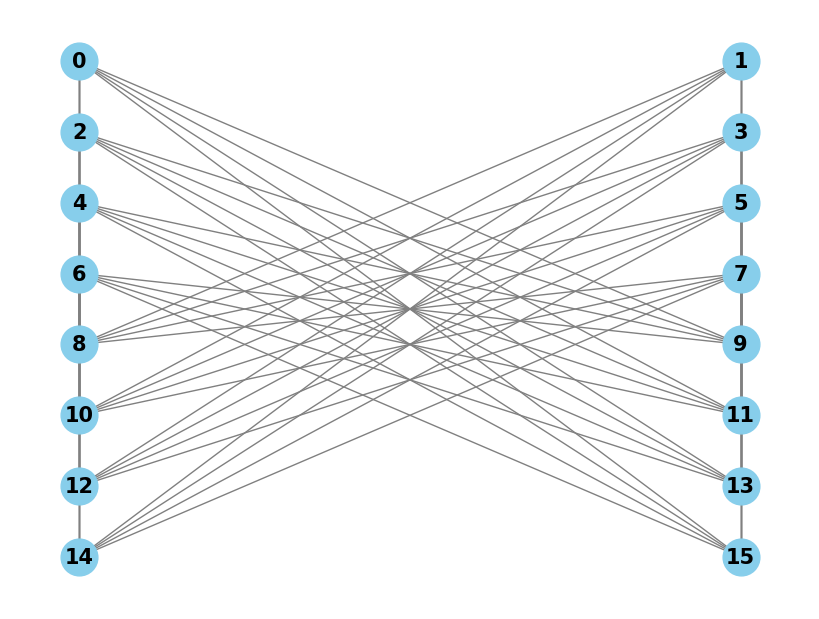

None


Matchings WITH relabeling: 8
Vertex mapping (original -> relabeled): {'0100': '0100', '1111': '1111', '0110': '0110', '0111': '0111', '1100': '1100', '0011': '0011', '0001': '0001', '0101': '0101', '1010': '1010', '0010': '0010', '1001': '1001', '1000': '1000', '1101': '1101', '1110': '1110', '1011': '1011', '0000': '0000'}
Matchings: [{('0010', '1010'), ('1110', '0110'), ('0001', '1001'), ('1100', '0100'), ('1011', '0011'), ('1000', '0000'), ('0101', '1101'), ('0111', '1111')}, {('0101', '1100'), ('1011', '0010'), ('0110', '1111'), ('1101', '0100'), ('1110', '0111'), ('1010', '0011'), ('0001', '1000'), ('1001', '0000')}, {('0001', '1011'), ('1001', '0011'), ('1000', '0010'), ('0110', '1100'), ('0000', '1010'), ('1110', '0100'), ('0111', '1101'), ('0101', '1111')}, {('0111', '1100'), ('1011', '0000'), ('0001', '1010'), ('1000', '0011'), ('0101', '1110'), ('1001', '0010'), ('0110', '1101'), ('1111', '0100')}, {('1111', '0011'), ('1011', '0111'), ('1000', '0100'), ('0010', '1110'), ('01

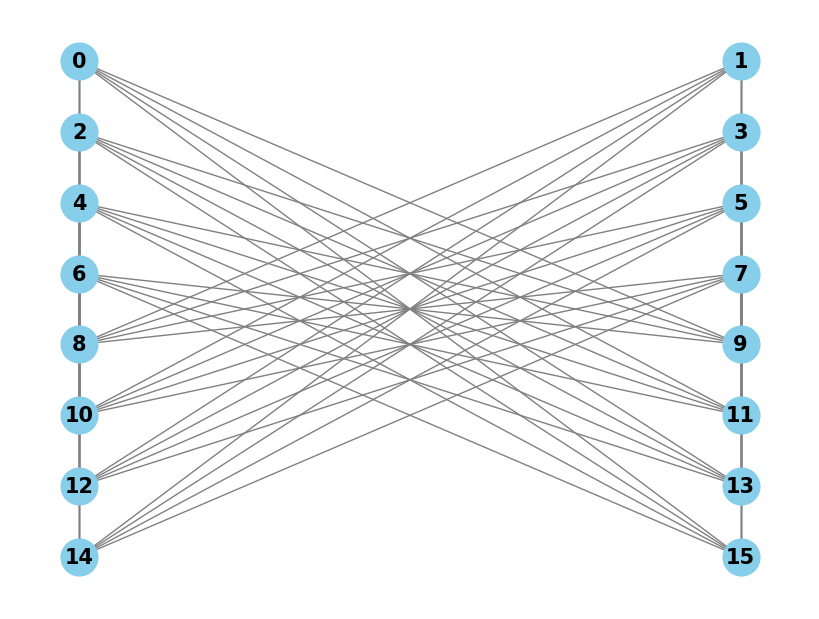

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


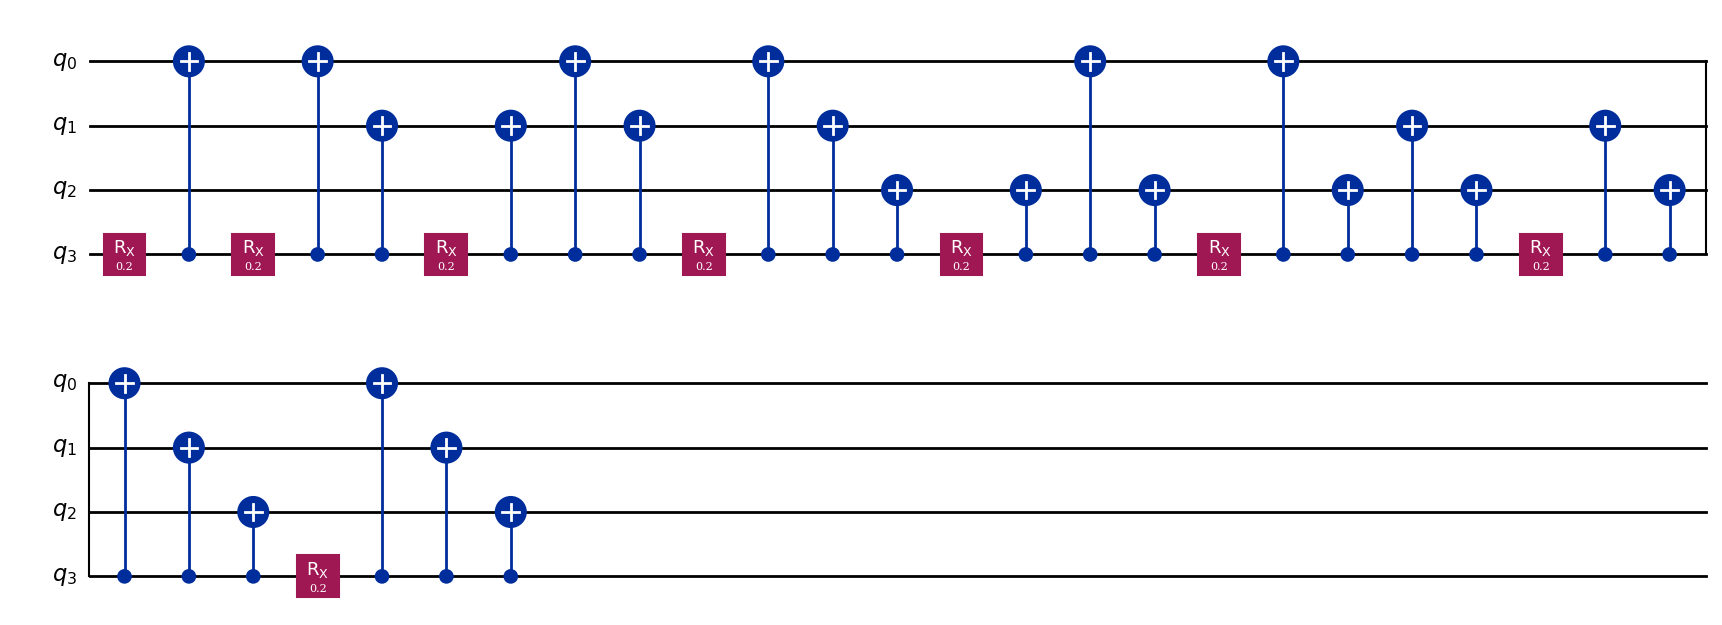


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


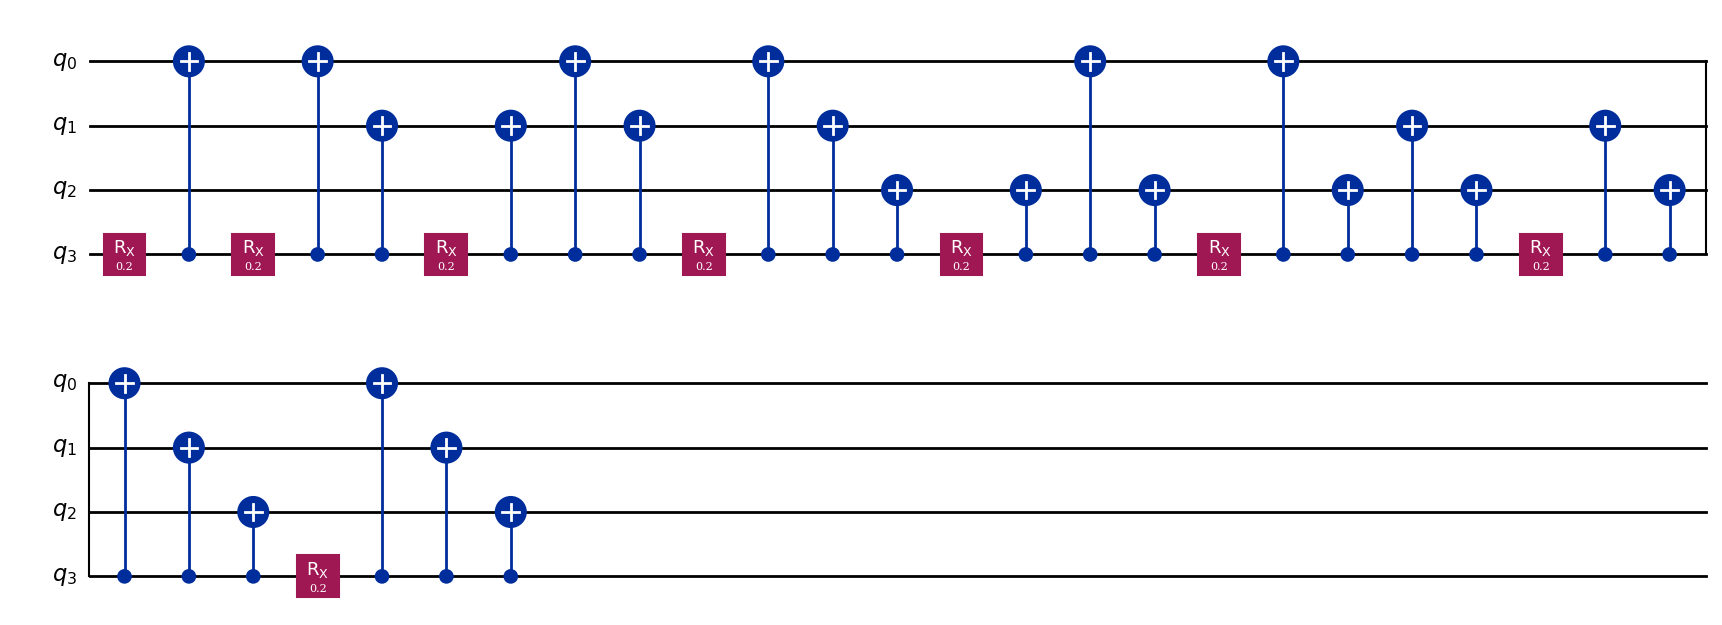

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Dense Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |   24/14                                |   24/14                                |   24/14                                |   24/14  
2        |   48/28                                |   48/28                                |   48/28                                |   48/28  
5        |  120/70                                |  120/70                                |  120/70                                |  120/70  
10       |  240/140                               |  240/140                               |  240/140                               |  240/140 
20       |  480/280              

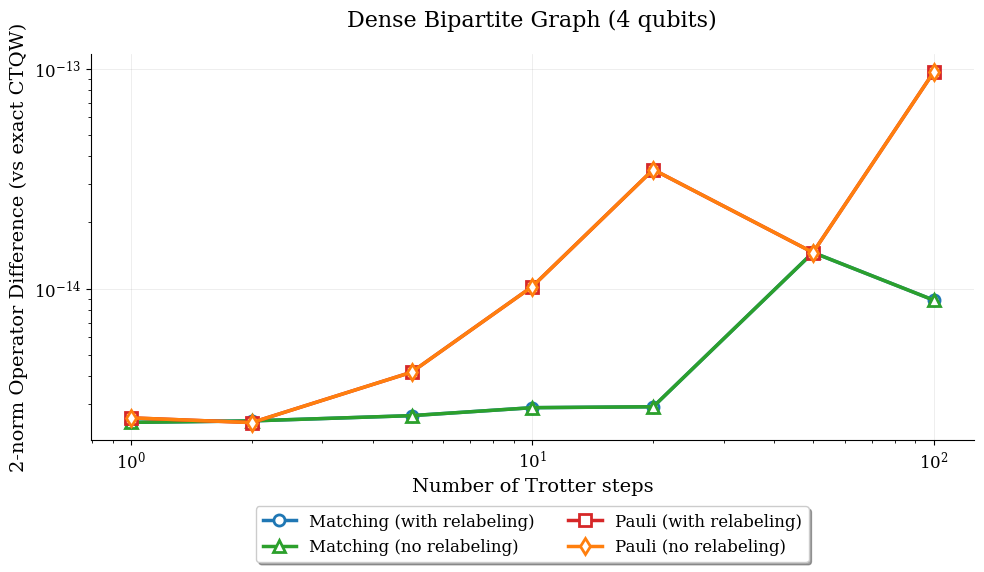

In [14]:
dense_bipartite_16 = {
    ('0000','1000'), ('0000','1001'), ('0000','1010'), ('0000','1011'), ('0000','1100'), ('0000','1101'), ('0000','1110'), ('0000','1111'),
    ('0001','1000'), ('0001','1001'), ('0001','1010'), ('0001','1011'), ('0001','1100'), ('0001','1101'), ('0001','1110'), ('0001','1111'),
    ('0010','1000'), ('0010','1001'), ('0010','1010'), ('0010','1011'), ('0010','1100'), ('0010','1101'), ('0010','1110'), ('0010','1111'),
    ('0011','1000'), ('0011','1001'), ('0011','1010'), ('0011','1011'), ('0011','1100'), ('0011','1101'), ('0011','1110'), ('0011','1111'),
    ('0100','1000'), ('0100','1001'), ('0100','1010'), ('0100','1011'), ('0100','1100'), ('0100','1101'), ('0100','1110'), ('0100','1111'),
    ('0101','1000'), ('0101','1001'), ('0101','1010'), ('0101','1011'), ('0101','1100'), ('0101','1101'), ('0101','1110'), ('0101','1111'),
    ('0110','1000'), ('0110','1001'), ('0110','1010'), ('0110','1011'), ('0110','1100'), ('0110','1101'), ('0110','1110'), ('0110','1111'),
    ('0111','1000'), ('0111','1001'), ('0111','1010'), ('0111','1011'), ('0111','1100'), ('0111','1101'), ('0111','1110'), ('0111','1111')
}

analyze_and_plot(dense_bipartite_16, "Dense Bipartite Graph (4 qubits)")


Sparse Non-Bipartite Graph (4 qubits)
Original edges: {('0001', '0011'), ('0001', '0100'), ('0010', '0110'), ('0000', '0100'), ('0111', '0110'), ('1010', '0101'), ('0010', '0011')}
Number of qubits: 4

Original Graph:


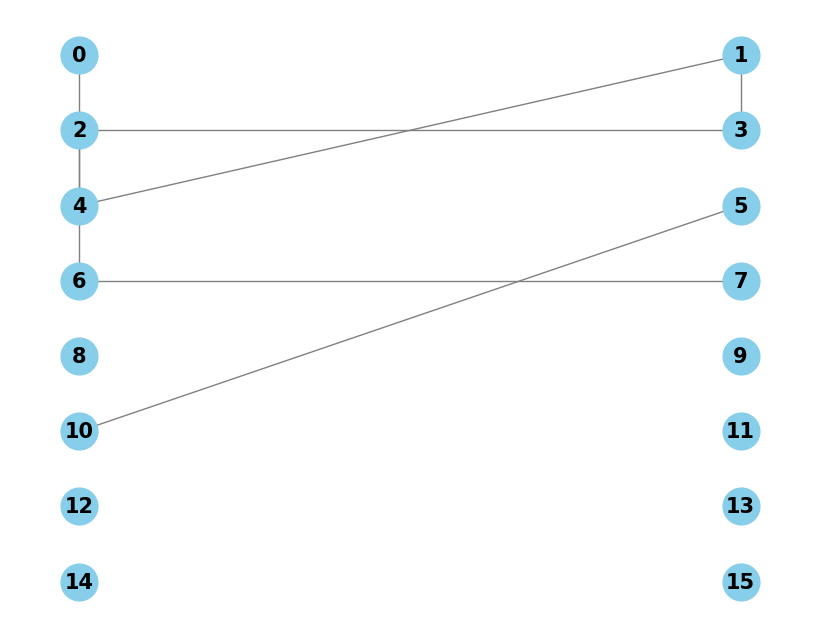

None


Matchings WITH relabeling: 4
Vertex mapping (original -> relabeled): {'0100': '0100', '0110': '0110', '0111': '1010', '0011': '0011', '0001': '0001', '1010': '0111', '0101': '0101', '0010': '0010', '0000': '0000'}
Matchings: [{('0001', '0011'), ('0111', '0101')}, {('1010', '0110'), ('0001', '0100')}, {('0010', '0110'), ('0000', '0100')}, {('0010', '0011')}]
Relabeled edges: {('0001', '0011'), ('0001', '0100'), ('0010', '0110'), ('0000', '0100'), ('0010', '0011'), ('1010', '0110'), ('0111', '0101')}

Matchings WITHOUT relabeling: 4
Matchings: [{('1010', '0101'), ('0001', '0011')}, {('0001', '0100')}, {('0010', '0110'), ('0000', '0100')}, {('0111', '0110'), ('0010', '0011')}]
Number of qubits: 4

Hamming Cost Analysis:
With Relabeling: Total = 9, Edges = 7, Per Edge = 1.286
No Relabeling: Total = 11, Edges = 7, Per Edge = 1.571

Relabeled Graph:


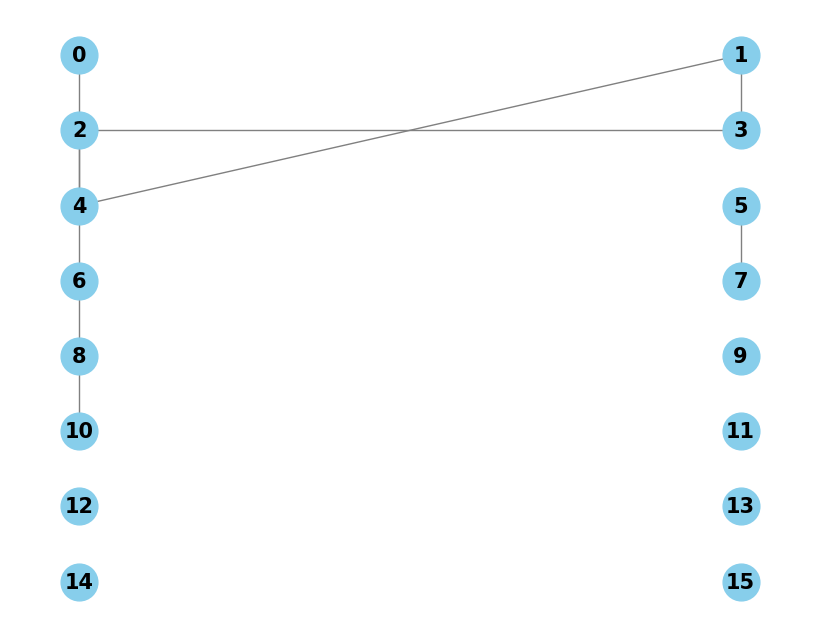

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


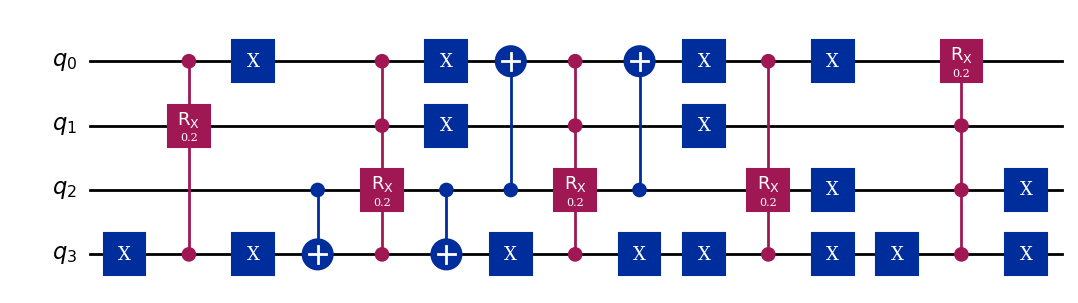


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


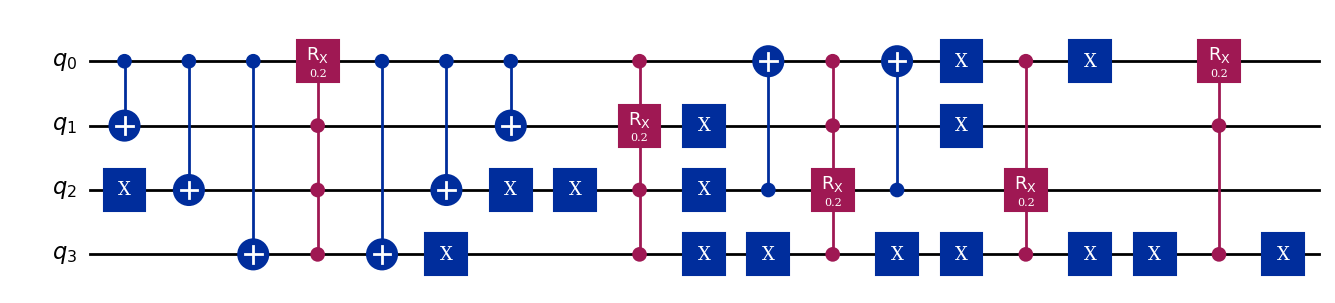

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Sparse Non-Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |   80/78                                |   84/82                                |  104/66                                |  120/80  
2        |  160/156                               |  168/163                               |  208/132                               |  240/160 
5        |  400/390                               |  420/406                               |  520/330                               |  600/400 
10       |  800/780                               |  840/811                               | 1040/660                               | 1200/800 
20       | 1600/1560        

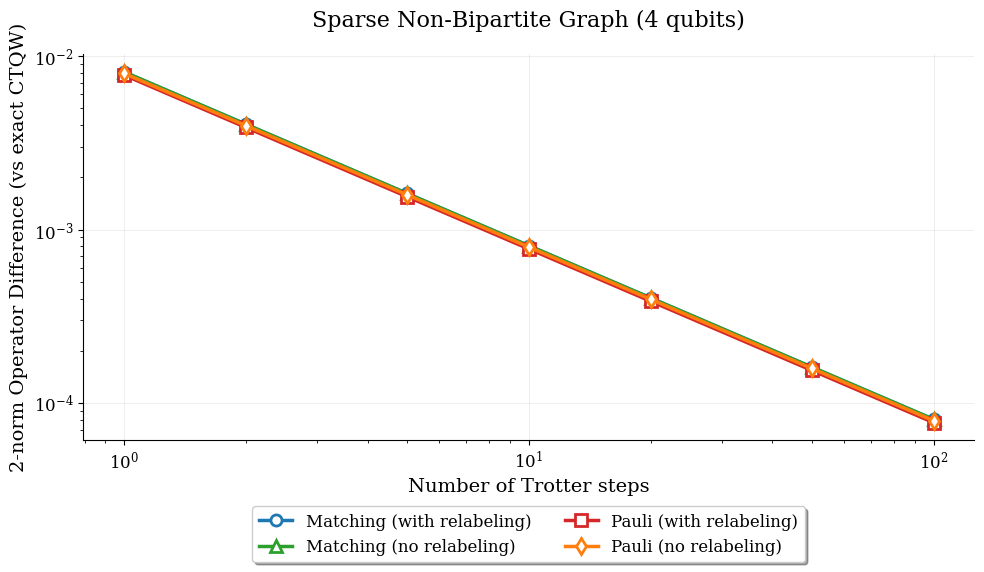

In [15]:
sparse_nonbipartite_16 = {
    ('0000','0100'),  # H=1, start cluster in 0xxx
    ('0001','0100'),  # H=2, degree-2 at 0100
    ('0001','0011'),  # H=1, degree-2 at 0001
    ('0010','0011'),  # H=1, degree-2 at 0011
    ('0010','0110'),  # H=1, degree-2 at 0010
    ('0111','0110'),  # H=1, degree-2 at 0110
    ('1010','0101'),  # H=3, high-Hamming bridge to 1xxx
}

analyze_and_plot(sparse_nonbipartite_16, "Sparse Non-Bipartite Graph (4 qubits)")


Sparse Bipartite Graph (4 qubits)
Original edges: {('0010', '0001'), ('1110', '1101'), ('1010', '1101'), ('0110', '1001'), ('0000', '0011'), ('1100', '1011'), ('1000', '0111'), ('0000', '0001'), ('1000', '1011'), ('0110', '0101'), ('0100', '0111'), ('1010', '1001'), ('0100', '0011'), ('1100', '1111'), ('0010', '0101')}
Number of qubits: 4

Original Graph:


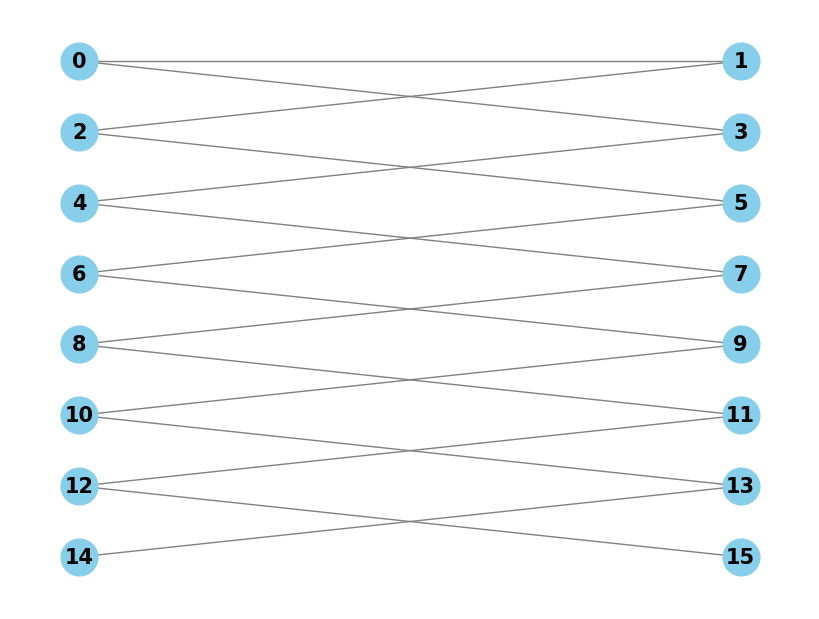

None


Matchings WITH relabeling: 2
Vertex mapping (original -> relabeled): {'1001': '0000', '1010': '0001', '1000': '0010', '1011': '0011', '0101': '0100', '0110': '0101', '0100': '0110', '0111': '0111', '0011': '1000', '0000': '1001', '0001': '1010', '0010': '1011', '1111': '1100', '1100': '1101', '1101': '1110', '1110': '1111'}
Matchings: [{('0110', '0111'), ('1101', '1100'), ('0101', '0100'), ('1111', '1110'), ('1011', '1010'), ('0010', '0011'), ('1001', '1000'), ('0001', '0000')}, {('0101', '0000'), ('0110', '1000'), ('1001', '1010'), ('1011', '0100'), ('0001', '1110'), ('1101', '0011'), ('0010', '0111')}]
Relabeled edges: {('0101', '0000'), ('0110', '1000'), ('0110', '0111'), ('1001', '1010'), ('1101', '1100'), ('0101', '0100'), ('1111', '1110'), ('1011', '0100'), ('0001', '1110'), ('1011', '1010'), ('1101', '0011'), ('0010', '0111'), ('0010', '0011'), ('1001', '1000'), ('0001', '0000')}

Matchings WITHOUT relabeling: 4
Matchings: [{('0010', '0001'), ('1110', '1101'), ('0000', '0011'),

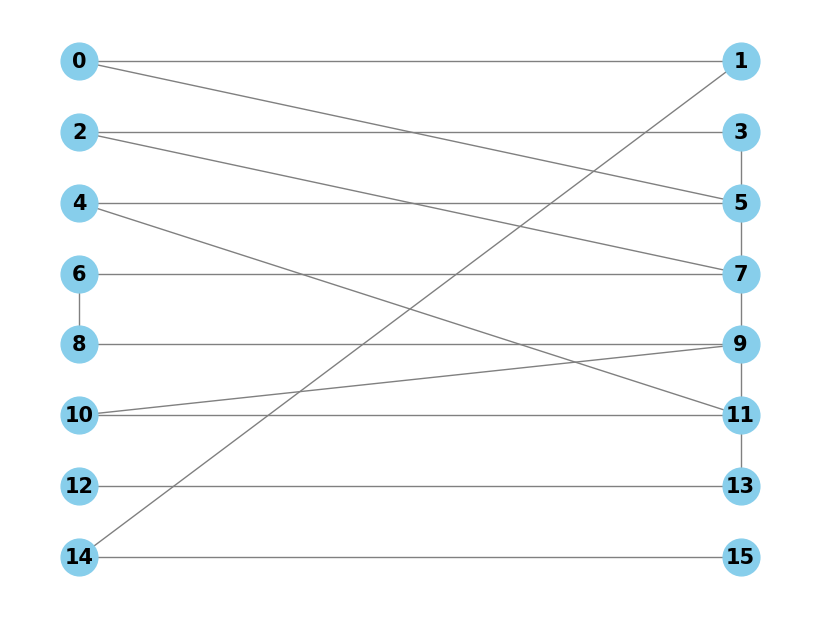

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


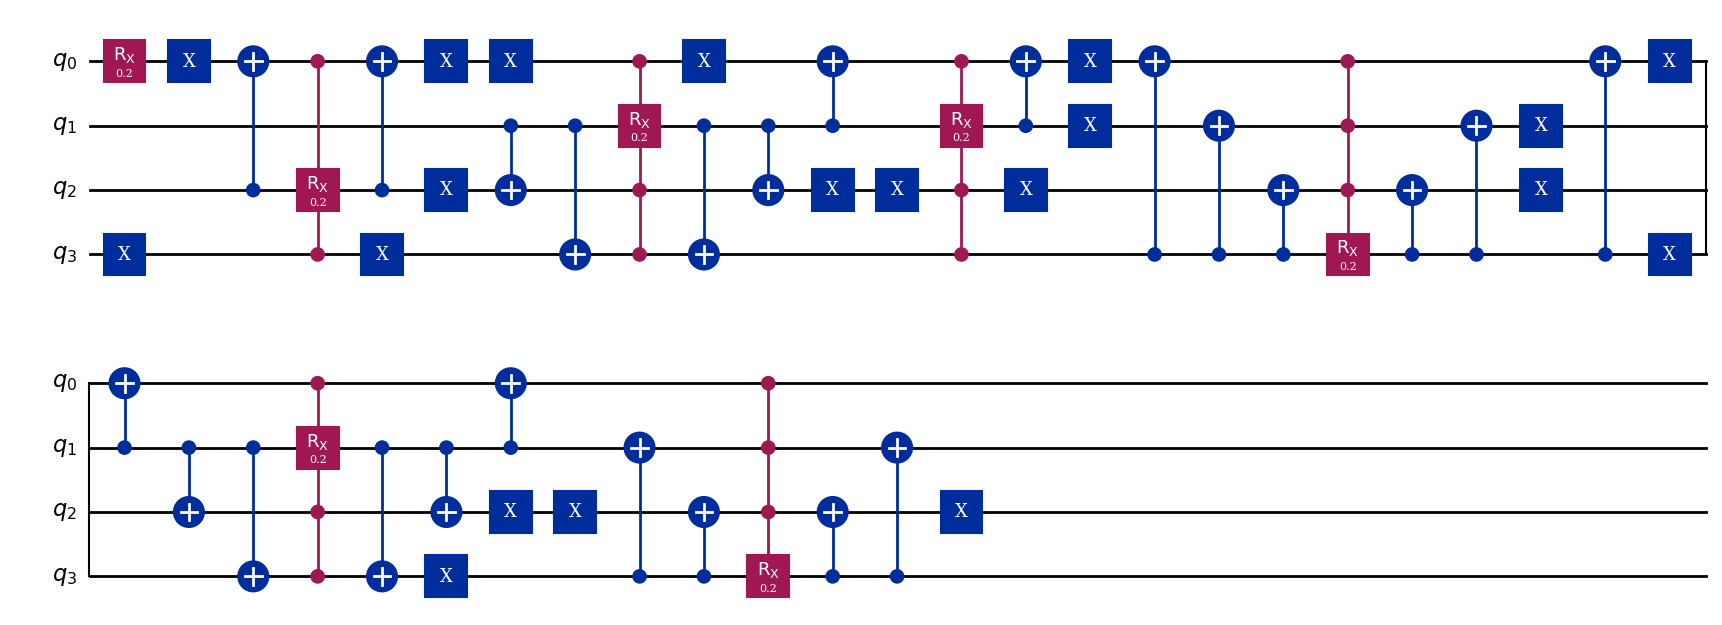


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


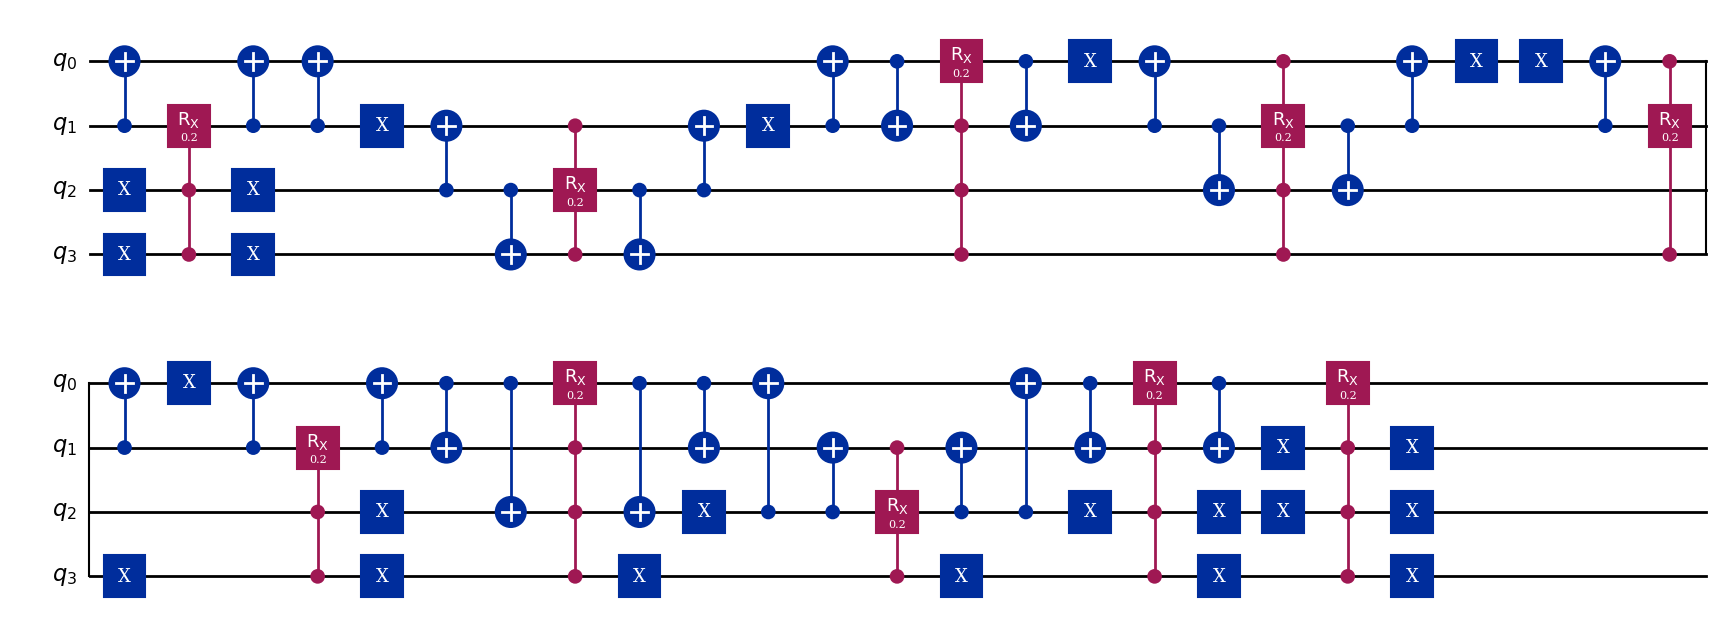

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Sparse Bipartite Graph (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |  132/126                               |  168/157                               |   88/60                                |   58/52  
2        |  264/252                               |  336/313                               |  176/120                               |  116/104 
5        |  660/630                               |  840/781                               |  440/300                               |  290/260 
10       | 1320/1260                              | 1680/1561                              |  880/600                               |  580/520 
20       | 2640/2520            

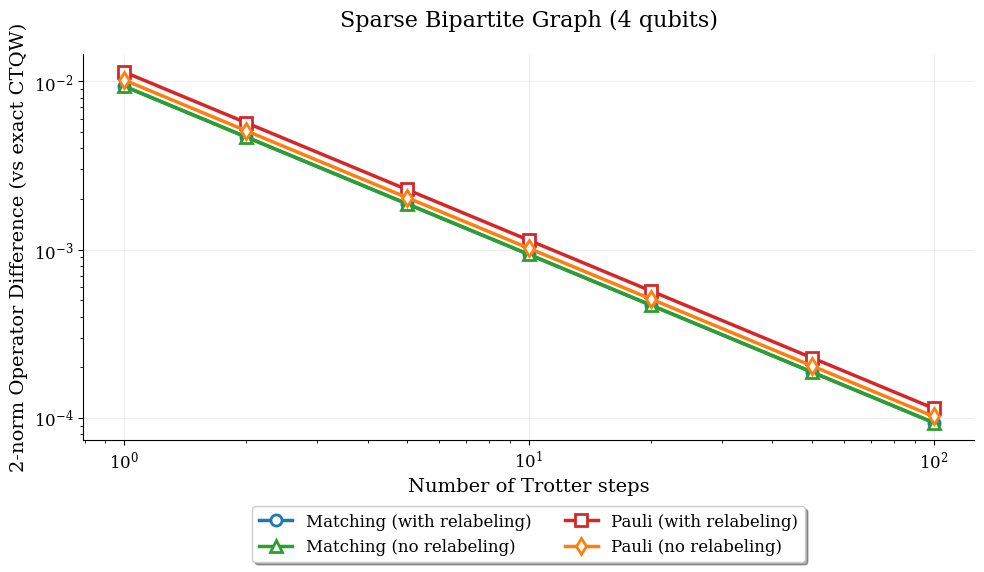

In [16]:
sparse_bipartite_16 = {
    ('0000','0001'), ('0000','0011'),
    ('0010','0001'), ('0010','0101'),
    ('0100','0011'), ('0100','0111'),
    ('0110','0101'), ('0110','1001'),
    ('1000','0111'), ('1000','1011'),
    ('1010','1001'), ('1010','1101'),
    ('1100','1011'), ('1100','1111'),
    ('1110','1101')
}

analyze_and_plot(sparse_bipartite_16, "Sparse Bipartite Graph (4 qubits)")


Sparse Non Bipartite Graph (5 qubits)
Original edges: {('00010', '00001'), ('01000', '00111'), ('00110', '00101'), ('00100', '00101'), ('10000', '01111'), ('01001', '01011'), ('00000', '00001'), ('00010', '00011'), ('00100', '00011')}
Number of qubits: 5

Original Graph:


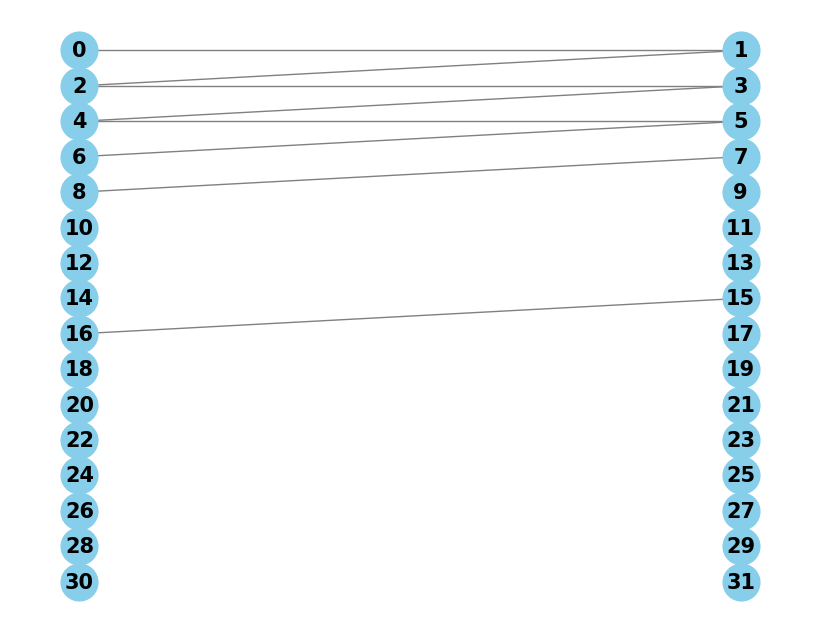

None


Matchings WITH relabeling: 4
Vertex mapping (original -> relabeled): {'00100': '00000', '00101': '00001', '01011': '00010', '01001': '00011', '00111': '00100', '01000': '00101', '01111': '00110', '10000': '00111', '00011': '01000', '00010': '01001', '00000': '01010', '00001': '01011', '00110': '01100'}
Matchings: [{('01001', '01011')}, {('00101', '00100'), ('01001', '01000'), ('00011', '00010'), ('00111', '00110'), ('01010', '01011'), ('00000', '00001')}, {('01100', '00001')}, {('00000', '01000')}]
Relabeled edges: {('01010', '01011'), ('00101', '00100'), ('01100', '00001'), ('01001', '01000'), ('00011', '00010'), ('00111', '00110'), ('00000', '01000'), ('01001', '01011'), ('00000', '00001')}

Matchings WITHOUT relabeling: 3
Matchings: [{('00010', '00001'), ('01000', '00111'), ('00110', '00101'), ('10000', '01111'), ('00100', '00011')}, {('00010', '00011'), ('00000', '00001'), ('00100', '00101')}, {('01001', '01011')}]
Number of qubits: 5

Hamming Cost Analysis:
With Relabeling: Total

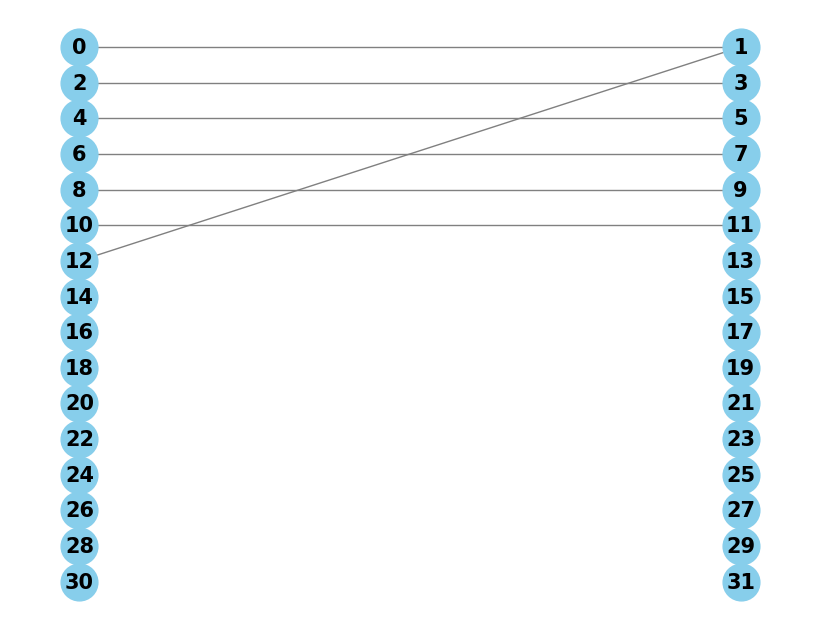

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


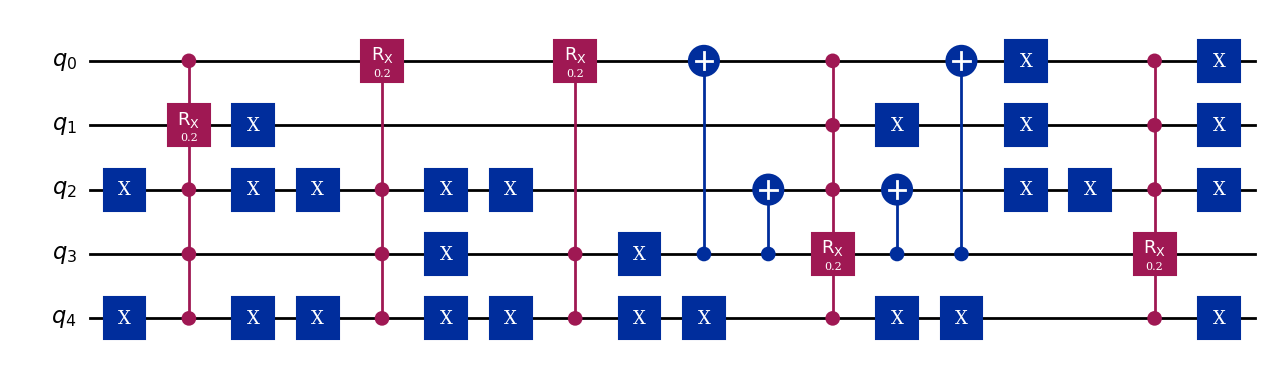


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


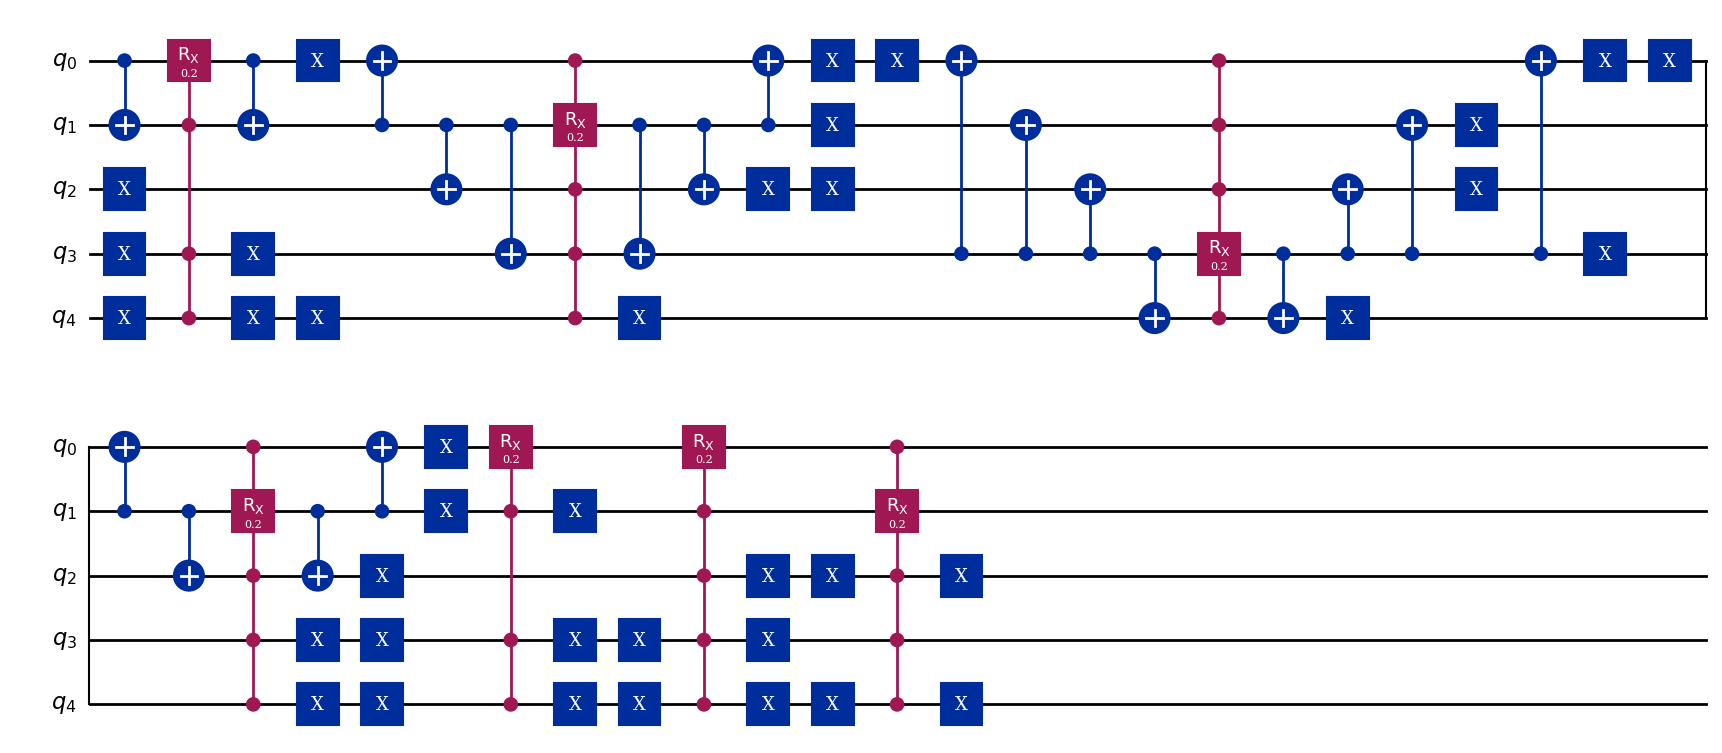

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Sparse Non Bipartite Graph (5 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |  104/103                               |  180/177                               |  248/137                               |  496/276 
2        |  208/206                               |  360/354                               |  496/274                               |  992/552 
5        |  520/515                               |  900/885                               | 1240/685                               | 2480/1380
10       | 1040/1030                              | 1800/1770                              | 2480/1370                              | 4960/2760
20       | 2080/2060        

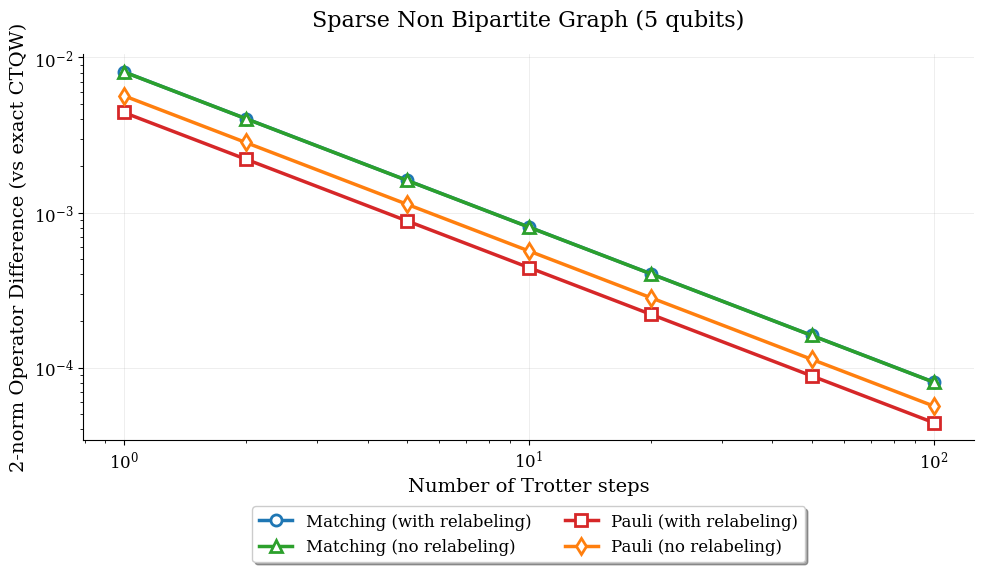

In [17]:
sparse_nonbipartite_32 = {
    # Cluster in 0xxxx region
    ('00000','00001'),  # H=1
    ('00010','00001'),  # H=2, degree-2 at 00001
    ('00010','00011'),  # H=1, degree-2 at 00010
    ('00100','00011'),  # H=2, degree-2 at 00011
    ('00100','00101'),  # H=1, degree-2 at 00100
    ('00110','00101'),  # H=2, degree-2 at 00101
    ('01000','00111'),  # H=3, bridge
    ('01001','01011'),  # H=1, small cluster in 01xxx
    ('10000','01111'),  # H=4, high-Hamming bridge to 1xxxx
}

analyze_and_plot(sparse_nonbipartite_32, "Sparse Non Bipartite Graph (5 qubits)" )


Cayley Graph of Z2 x Z2 x Z2 (3 qubits)
Original edges: {('001', '011'), ('000', '100'), ('110', '111'), ('000', '010'), ('001', '101'), ('010', '011'), ('011', '111'), ('100', '110'), ('010', '110'), ('101', '111'), ('000', '001'), ('100', '101')}
Number of qubits: 3

Original Graph:


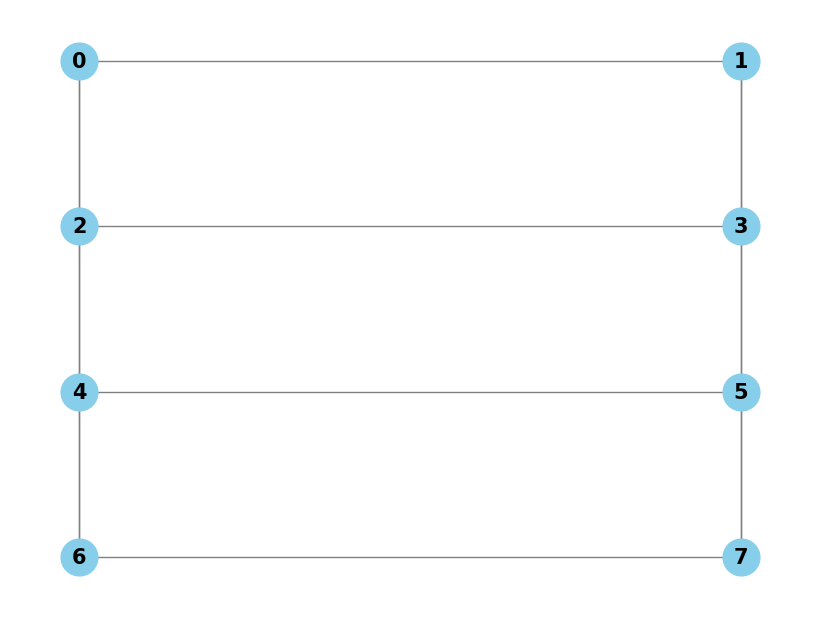

None


Matchings WITH relabeling: 3
Vertex mapping (original -> relabeled): {'111': '111', '101': '101', '001': '001', '011': '011', '110': '110', '000': '000', '100': '100', '010': '010'}
Matchings: [{('001', '011'), ('000', '010'), ('100', '110'), ('101', '111')}, {('010', '110'), ('001', '101'), ('011', '111'), ('000', '100')}, {('000', '001'), ('010', '011'), ('100', '101'), ('110', '111')}]
Relabeled edges: {('001', '011'), ('000', '100'), ('110', '111'), ('000', '010'), ('001', '101'), ('011', '111'), ('010', '011'), ('100', '110'), ('101', '111'), ('010', '110'), ('000', '001'), ('100', '101')}

Matchings WITHOUT relabeling: 3
Matchings: [{('001', '011'), ('000', '010'), ('100', '110'), ('101', '111')}, {('010', '110'), ('001', '101'), ('011', '111'), ('000', '100')}, {('000', '001'), ('010', '011'), ('100', '101'), ('110', '111')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 12, Edges = 12, Per Edge = 1.000
No Relabeling: Total = 12, Edges = 12, Per Edge = 1.

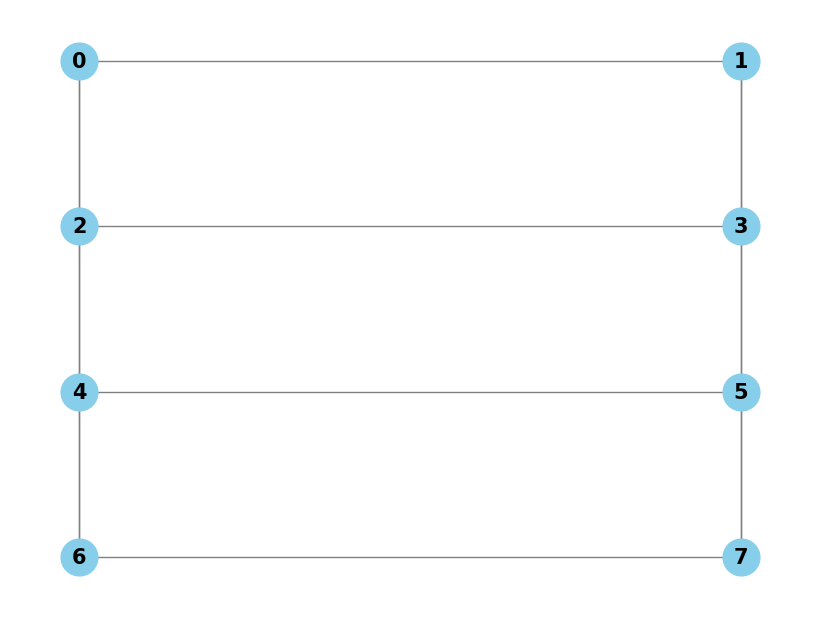

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


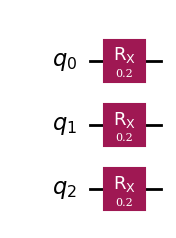


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


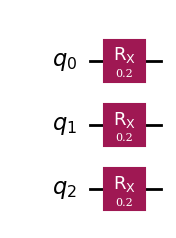

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Cayley Graph of Z2 x Z2 x Z2 (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
2        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
5        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
10       |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
20       |    0/0         

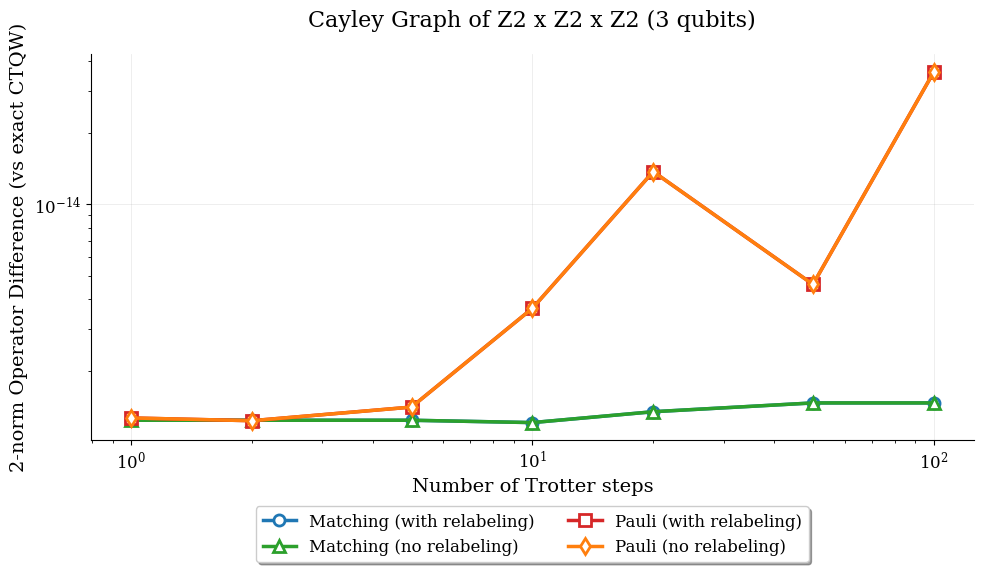

In [18]:
cayley_8 = set()
vertices_8 = [format(i, '03b') for i in range(8)]
generators_8 = ['001', '010', '100']
for v in vertices_8:
    v_int = int(v, 2)
    for g in generators_8:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '03b')
        if v < neighbor:  # Avoid duplicates
            cayley_8.add((v, neighbor))

analyze_and_plot(cayley_8, "Cayley Graph of Z2 x Z2 x Z2 (3 qubits)")


Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)
Original edges: {('1010', '1110'), ('0010', '0110'), ('1000', '1001'), ('1110', '1111'), ('1100', '1110'), ('0011', '0111'), ('1000', '1010'), ('1011', '1111'), ('0111', '1111'), ('0010', '1010'), ('1000', '1100'), ('1010', '1011'), ('0101', '1101'), ('1001', '1011'), ('0100', '0110'), ('0001', '0011'), ('0000', '0100'), ('0110', '0111'), ('0000', '0001'), ('1001', '1101'), ('1100', '1101'), ('0110', '1110'), ('0100', '0101'), ('0011', '1011'), ('0001', '1001'), ('0101', '0111'), ('1101', '1111'), ('0001', '0101'), ('0100', '1100'), ('0000', '0010'), ('0010', '0011'), ('0000', '1000')}
Number of qubits: 4

Original Graph:


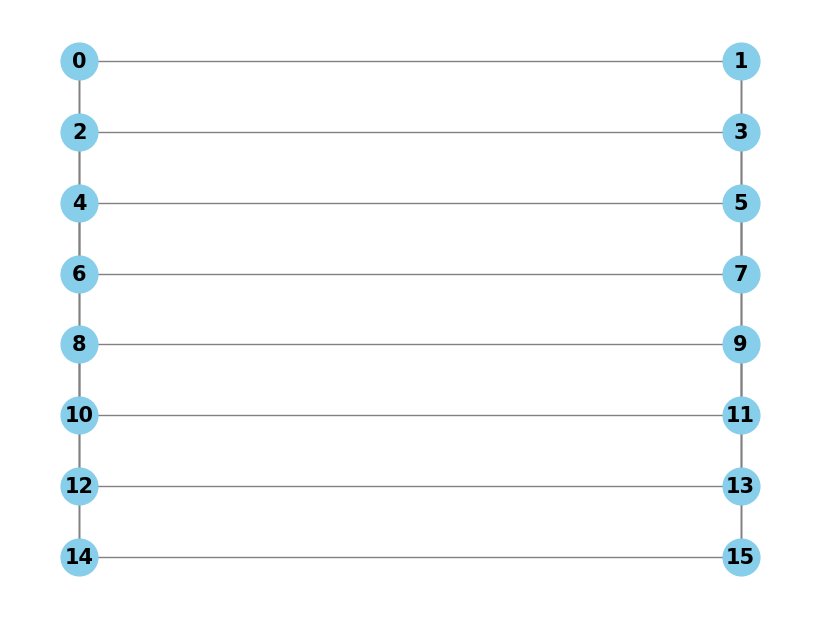

None


Matchings WITH relabeling: 4
Vertex mapping (original -> relabeled): {'0100': '0100', '1111': '1111', '0110': '0110', '1100': '1100', '0011': '0011', '0111': '0111', '0001': '0001', '1010': '1010', '0101': '0101', '0010': '0010', '1001': '1001', '1000': '1000', '1101': '1101', '1110': '1110', '1011': '1011', '0000': '0000'}
Matchings: [{('1010', '1110'), ('0010', '0110'), ('1000', '1100'), ('0000', '0100'), ('0001', '0101'), ('1001', '1101'), ('0011', '0111'), ('1011', '1111')}, {('0110', '0111'), ('1000', '1001'), ('0000', '0001'), ('1110', '1111'), ('1010', '1011'), ('1100', '1101'), ('0010', '0011'), ('0100', '0101')}, {('1001', '1011'), ('0100', '0110'), ('0001', '0011'), ('0101', '0111'), ('1101', '1111'), ('1100', '1110'), ('1000', '1010'), ('0000', '0010')}, {('0010', '1010'), ('0011', '1011'), ('0001', '1001'), ('0101', '1101'), ('0100', '1100'), ('0110', '1110'), ('0111', '1111'), ('0000', '1000')}]
Relabeled edges: {('1010', '1110'), ('1001', '1011'), ('0100', '0110'), ('000

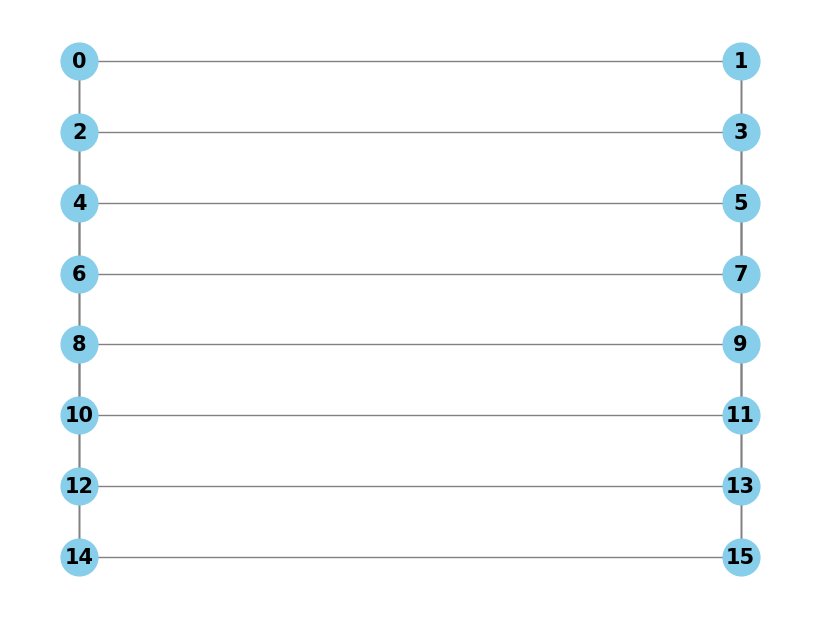

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


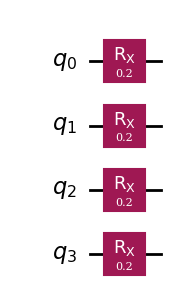


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


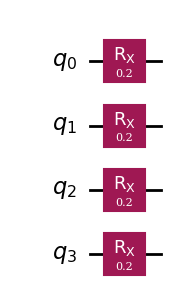

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
2        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
5        |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
10       |    0/0                                 |    0/0                                 |    0/0                                 |    0/0   
20       |    0/0    

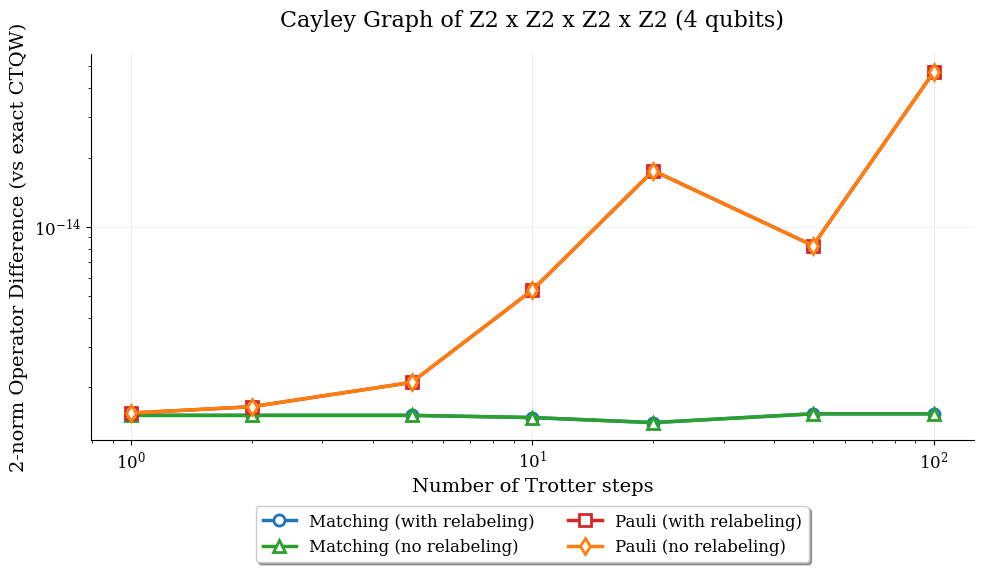

In [19]:
cayley_16 = set()
vertices_16 = [format(i, '04b') for i in range(16)]
generators_16 = ['0001', '0010', '0100', '1000']
for v in vertices_16:
    v_int = int(v, 2)
    for g in generators_16:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '04b')
        if v < neighbor:  # Avoid duplicates
            cayley_16.add((v, neighbor))
analyze_and_plot(cayley_16, "Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)")


Circulant Graph C8(1,2) (3 qubits)
Original edges: {('001', '011'), ('110', '111'), ('000', '010'), ('001', '010'), ('010', '011'), ('100', '110'), ('101', '111'), ('000', '001'), ('010', '100'), ('100', '101'), ('101', '110'), ('011', '100'), ('011', '101')}
Number of qubits: 3

Original Graph:


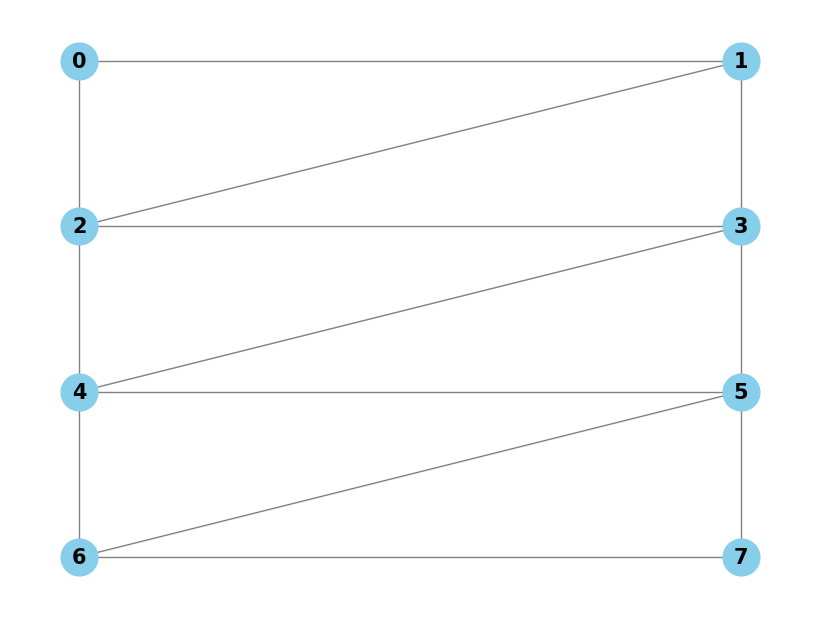

None


Matchings WITH relabeling: 5
Vertex mapping (original -> relabeled): {'100': '000', '110': '001', '011': '010', '001': '011', '101': '100', '111': '101', '010': '110', '000': '111'}
Matchings: [{('111', '110'), ('000', '001'), ('011', '010'), ('100', '101')}, {('110', '010'), ('111', '011'), ('001', '101'), ('000', '100')}, {('100', '001'), ('011', '110')}, {('010', '100'), ('110', '000')}, {('010', '000')}]
Relabeled edges: {('100', '101'), ('100', '001'), ('010', '000'), ('011', '110'), ('000', '100'), ('110', '010'), ('111', '011'), ('001', '101'), ('111', '110'), ('000', '001'), ('011', '010'), ('010', '100'), ('110', '000')}

Matchings WITHOUT relabeling: 4
Matchings: [{('001', '011'), ('000', '010'), ('100', '110'), ('101', '111')}, {('000', '001'), ('010', '011'), ('100', '101'), ('110', '111')}, {('011', '100'), ('001', '010'), ('101', '110')}, {('011', '101'), ('010', '100')}]
Number of qubits: 3

Hamming Cost Analysis:
With Relabeling: Total = 17, Edges = 13, Per Edge = 1.30

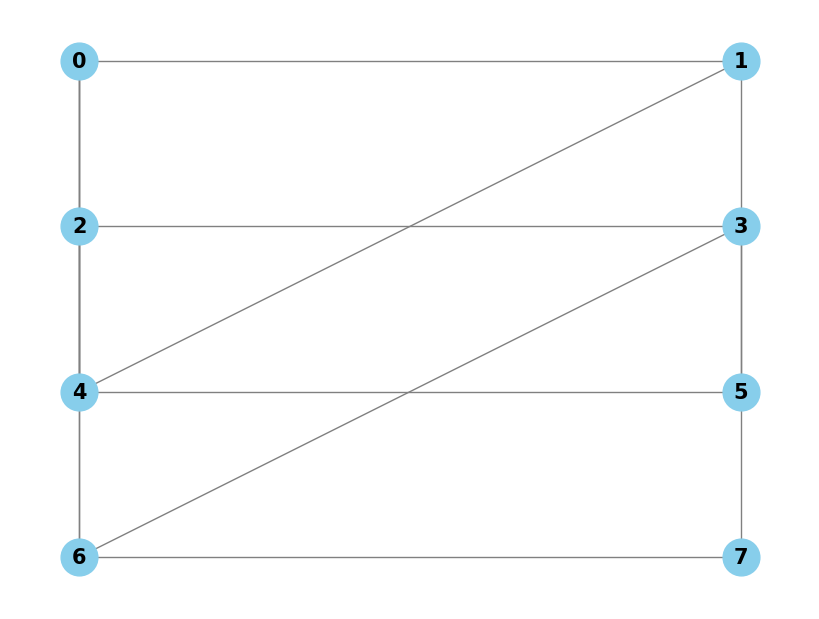

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


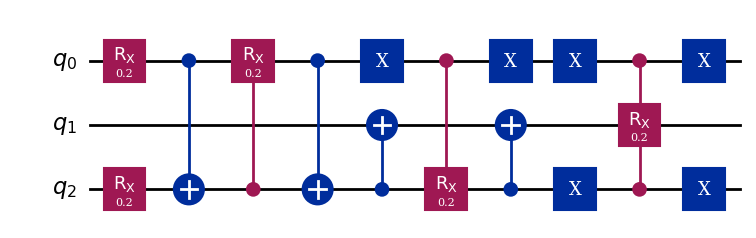


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


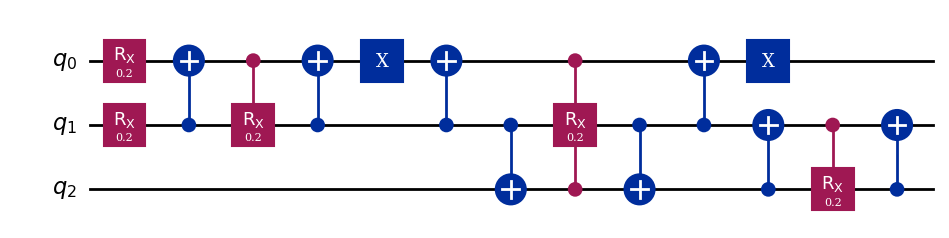

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Circulant Graph C8(1,2) (3 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |   16/13                                |   20/14                                |   18/14                                |   24/16  
2        |   32/26                                |   40/28                                |   36/28                                |   48/32  
5        |   80/65                                |  100/70                                |   90/70                                |  120/80  
10       |  160/130                               |  200/140                               |  180/140                               |  240/160 
20       |  320/260            

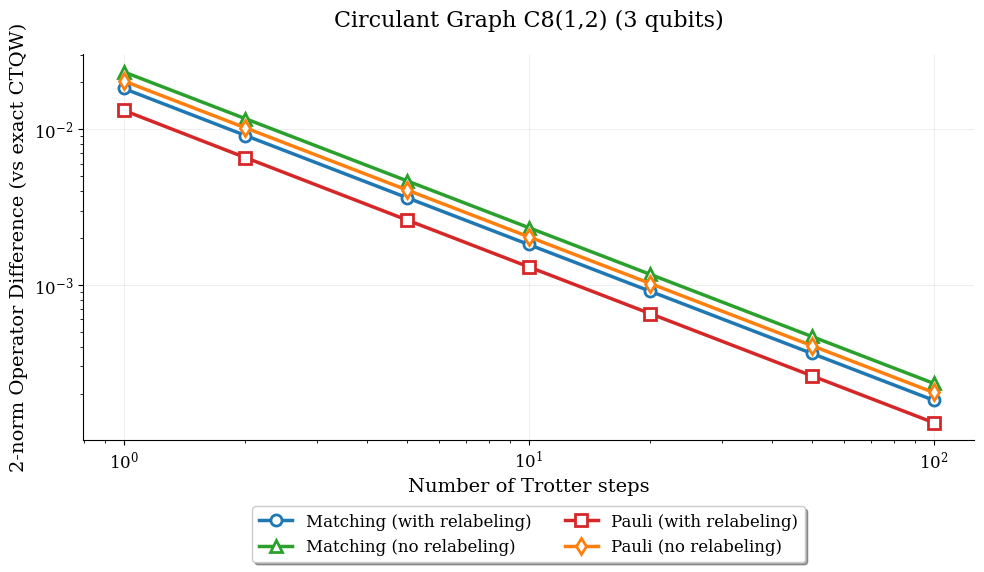

In [20]:
circulant_8 = set()
n = 8
offsets_8 = [1, 2]
for i in range(n):
    v = format(i, '03b')
    for offset in offsets_8:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '03b')
        if v < neighbor:  # Avoid duplicates
            circulant_8.add((v, neighbor))
analyze_and_plot(circulant_8, "Circulant Graph C8(1,2) (3 qubits)")


Circulant Graph C16(1,3,5) (4 qubits)
Original edges: {('0101', '1000'), ('0111', '1100'), ('1011', '1100'), ('0000', '0101'), ('1000', '1001'), ('0110', '1011'), ('1001', '1110'), ('1110', '1111'), ('0101', '1010'), ('0010', '0101'), ('1101', '1110'), ('0001', '0100'), ('0011', '0110'), ('1001', '1010'), ('1000', '1011'), ('0100', '0111'), ('1010', '1011'), ('0011', '1000'), ('1001', '1100'), ('1000', '1101'), ('1010', '1101'), ('0110', '0111'), ('1010', '1111'), ('0001', '0110'), ('0000', '0001'), ('1011', '1110'), ('0001', '0010'), ('0100', '1001'), ('1100', '1101'), ('1100', '1111'), ('0100', '0101'), ('0111', '1000'), ('0000', '0011'), ('0110', '1001'), ('0101', '0110'), ('0111', '1010'), ('0010', '0111'), ('0010', '0011'), ('0011', '0100')}
Number of qubits: 4

Original Graph:


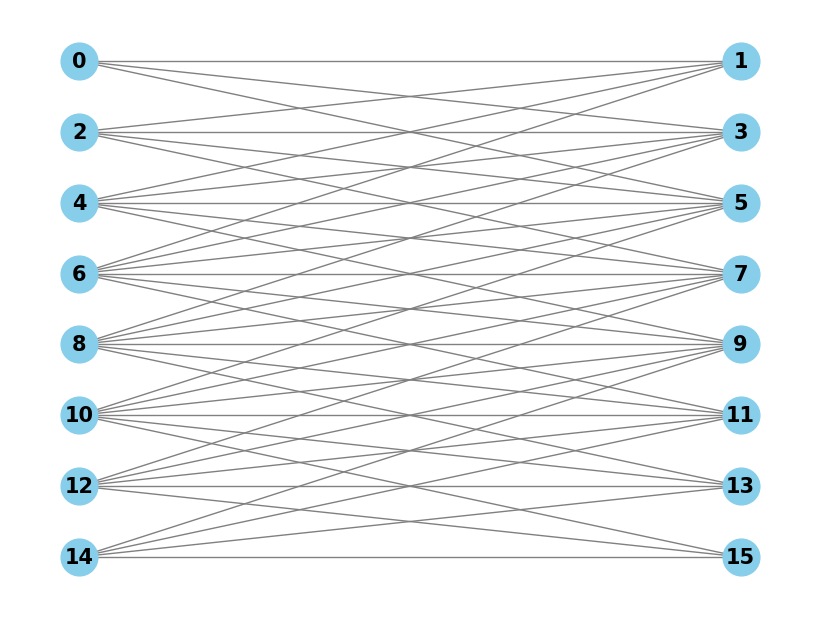

None


Matchings WITH relabeling: 9
Vertex mapping (original -> relabeled): {'0111': '0000', '1000': '0001', '0110': '0010', '1011': '0011', '1101': '0100', '1110': '0101', '1010': '0110', '1001': '0111', '0011': '1000', '0000': '1001', '1111': '1010', '1100': '1011', '0010': '1100', '0101': '1101', '0100': '1110', '0001': '1111'}
Matchings: [{('1000', '0010'), ('0000', '1011'), ('0110', '0011'), ('0101', '1010'), ('1110', '0111'), ('1101', '0001'), ('1001', '1111')}, {('1011', '0100'), ('1110', '0000'), ('1111', '0010'), ('0001', '0111'), ('1101', '0110'), ('0011', '0101')}, {('1110', '1101'), ('0111', '1011'), ('0110', '1010'), ('1000', '0001'), ('1111', '1100')}, {('1000', '1110'), ('0000', '0110'), ('0010', '0111'), ('0001', '0100')}, {('1100', '0000'), ('1101', '0010')}, {('0011', '1011')}, {('1001', '1101'), ('1100', '1000')}, {('0100', '0101'), ('1111', '1110'), ('0000', '0001'), ('1011', '1010'), ('1100', '1101'), ('0111', '0110'), ('0010', '0011'), ('1001', '1000')}, {('0110', '0100

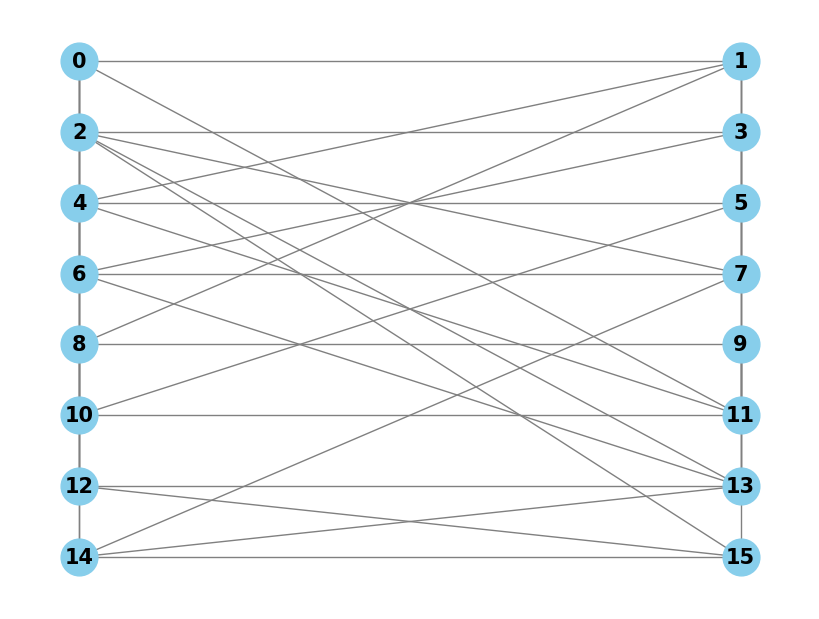

None


Sample Circuit - Matching WITH Relabeling (n_steps=1):


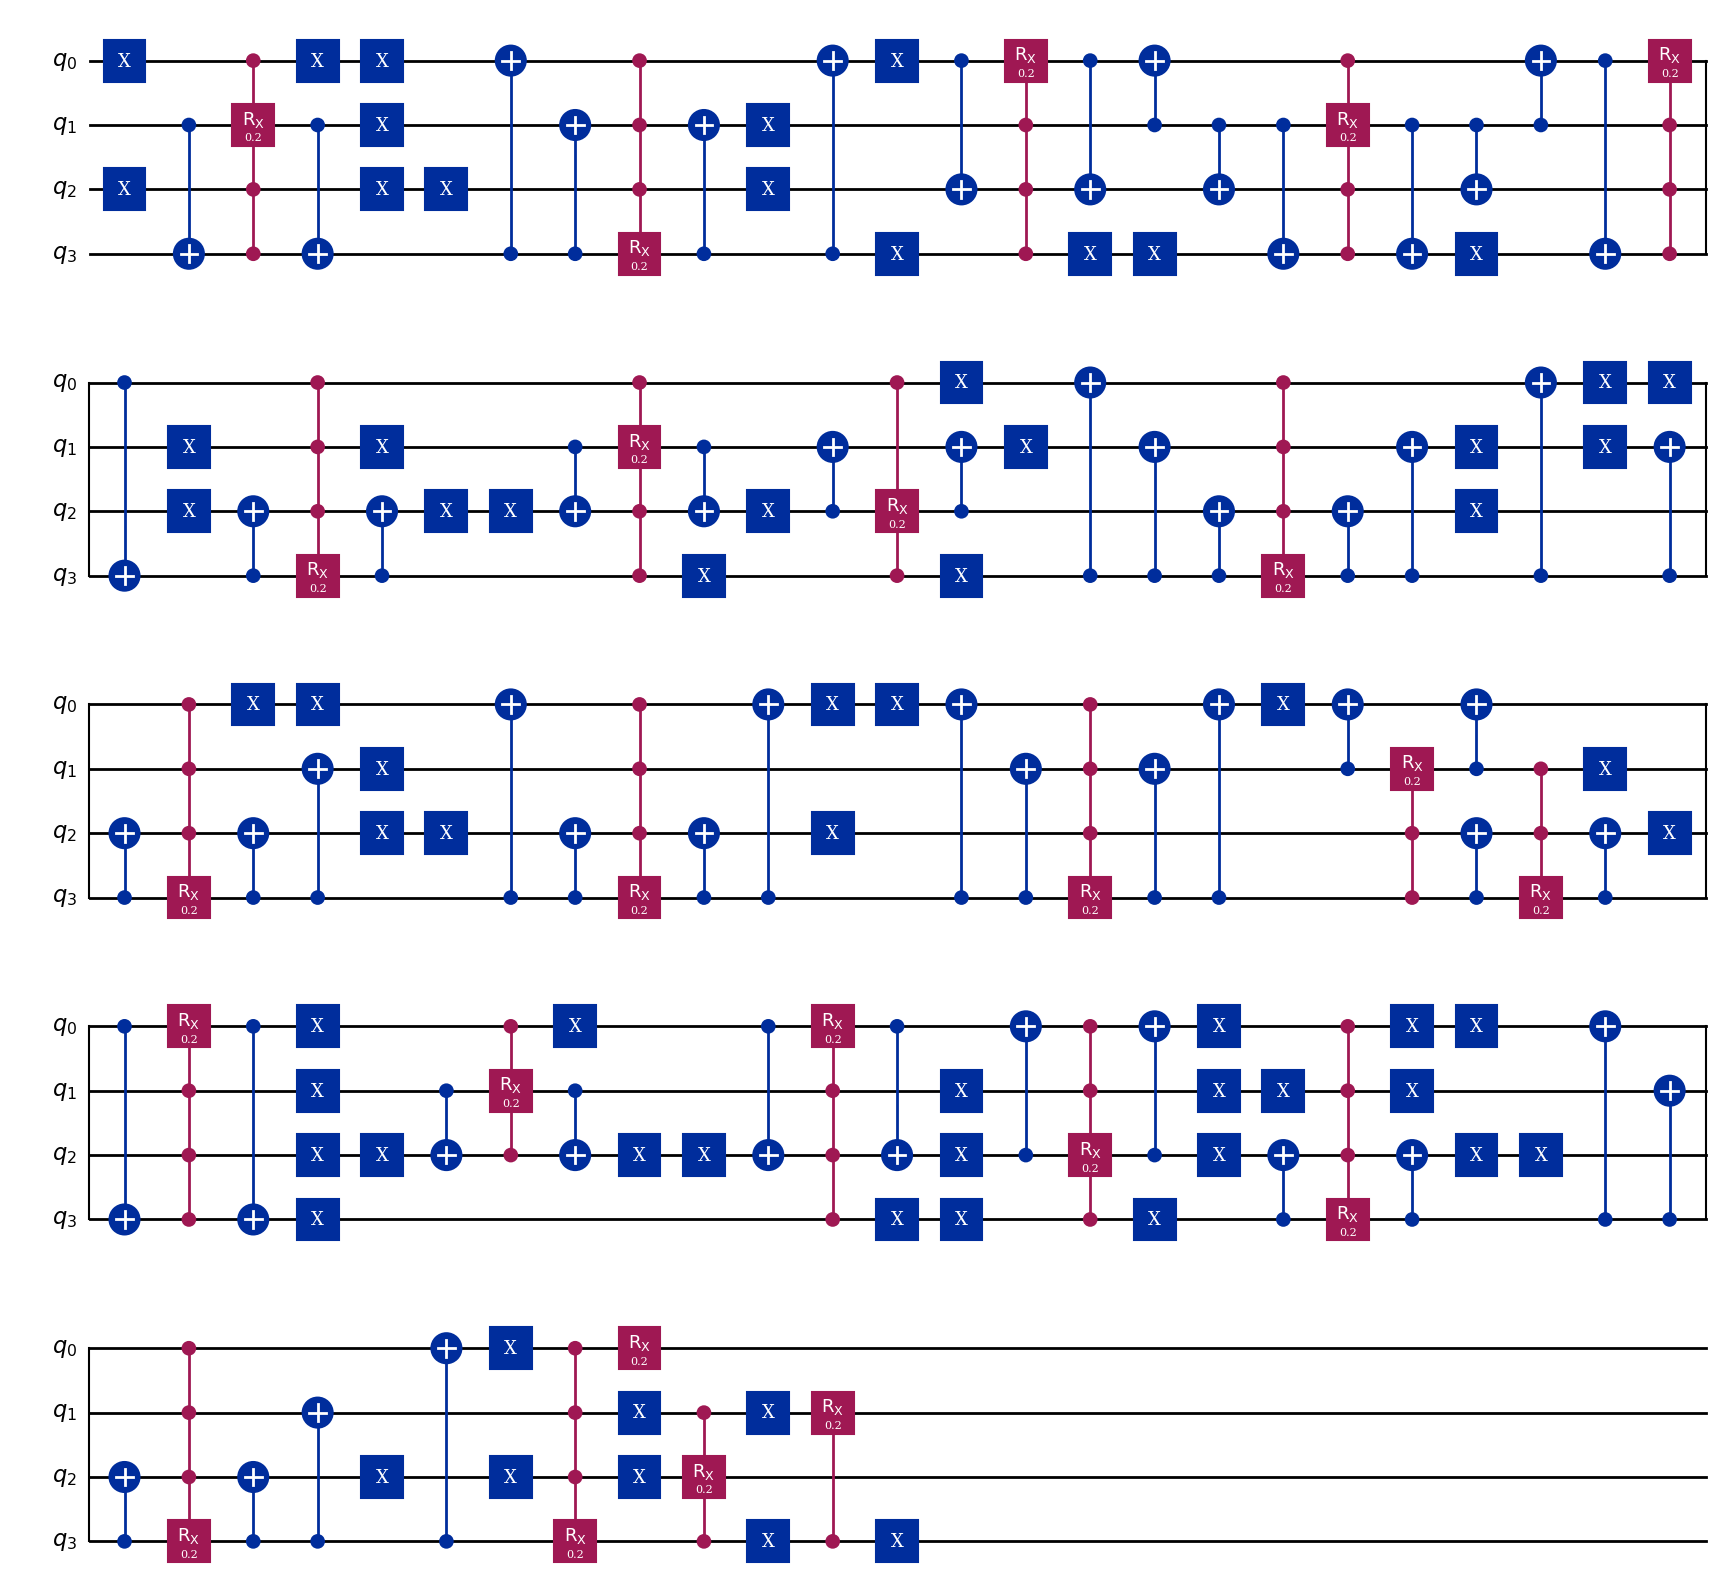


Sample Circuit - Matching WITHOUT Relabeling (n_steps=1):


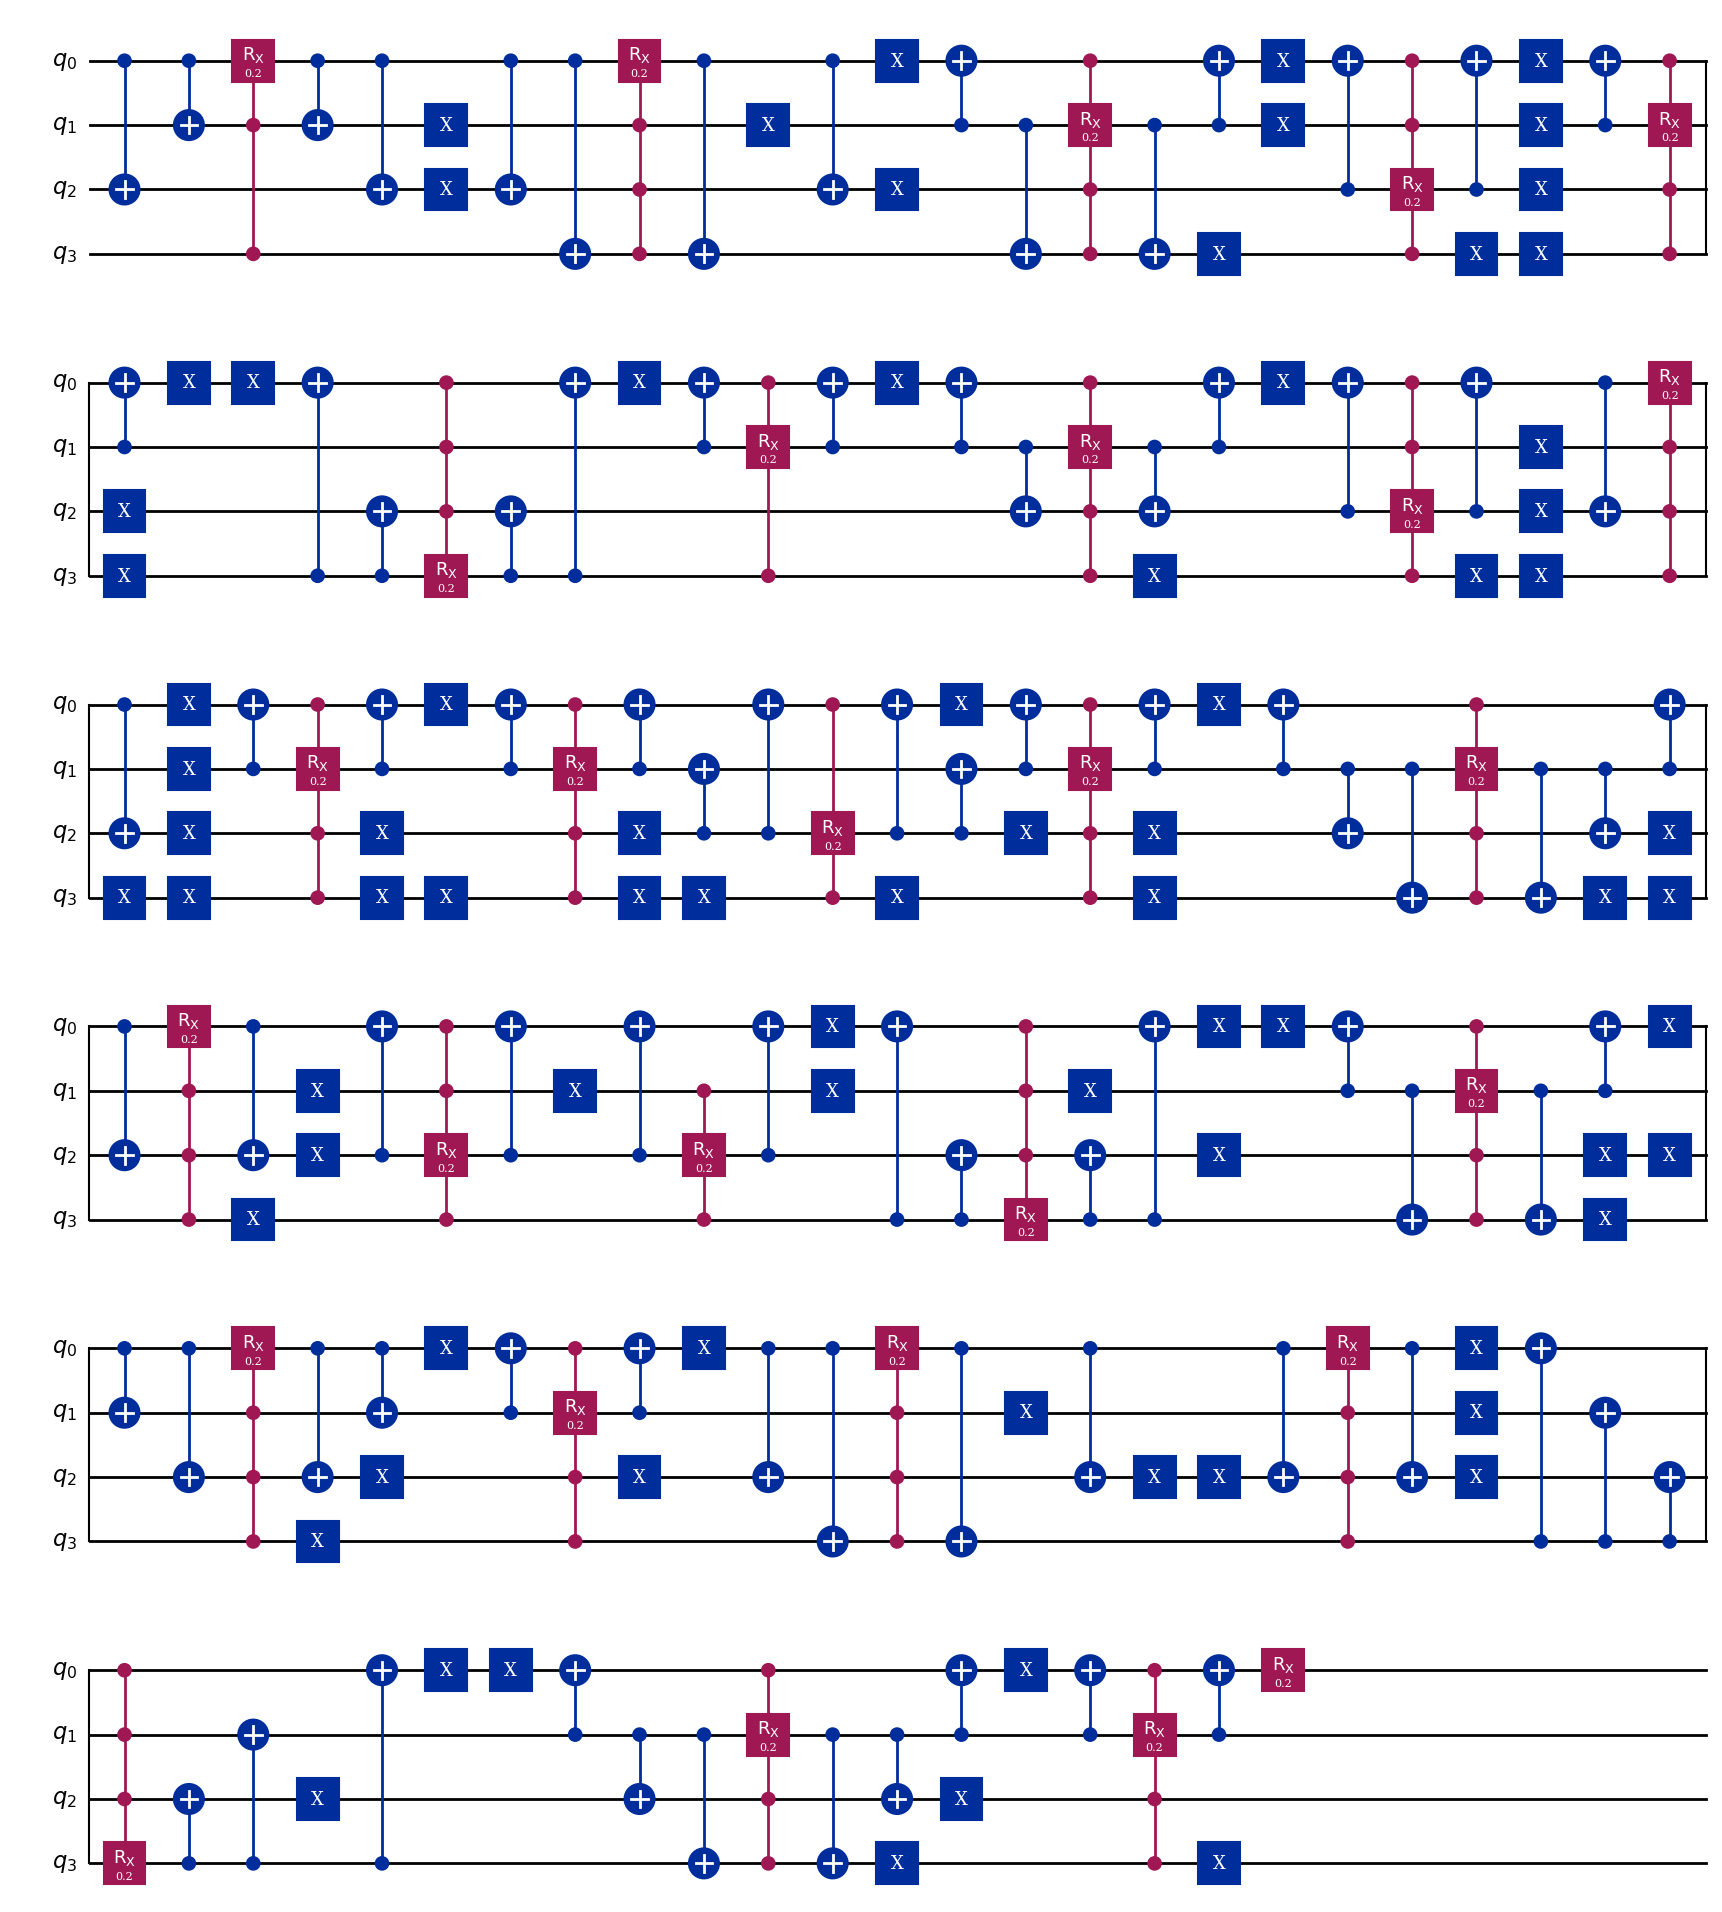

f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:603: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
f:\UTK\Research\DOE_FOA_project\code\dyn-CTQW\venv310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



CX Gate Count Summary for Circulant Graph C16(1,3,5) (4 qubits):
n_steps  |   Matching w/ Relabel (No Opt/Opt)    |   Matching No Relabel (No Opt/Opt)    |     Pauli w/ Relabel (No Opt/Opt)     |     Pauli No Relabel (No Opt/Opt)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------
1        |  442/418                               |  578/543                               |  316/119                               |   92/70  
2        |  884/835                               | 1156/1086                              |  632/238                               |  184/140 
5        | 2210/2086                              | 2890/2715                              | 1580/595                               |  460/350 
10       | 4420/4171                              | 5780/5430                              | 3160/1190                              |  920/700 
20       | 8840/8341        

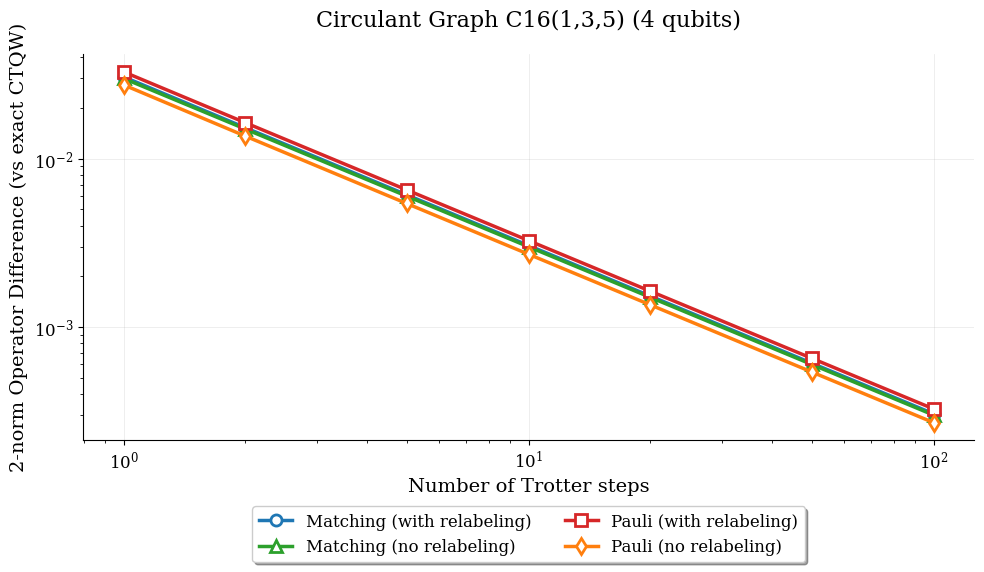

In [21]:
circulant_16 = set()
n = 16
offsets_16 = [1, 3, 5]
for i in range(n):
    v = format(i, '04b')
    for offset in offsets_16:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '04b')
        if v < neighbor:  # Avoid duplicates
            circulant_16.add((v, neighbor))
analyze_and_plot(circulant_16, "Circulant Graph C16(1,3,5) (4 qubits)")